In [ ]:
# -----------------------------
# Colab setup
# -----------------------------
!pip -q install pandas requests geopandas shapely pyproj

import pandas as pd
import requests
from datetime import datetime, timedelta
from io import StringIO

# -----------------------------
# 1) FIRMS MAP_KEY (PUT YOURS HERE)
# -----------------------------
MAP_KEY = "b490eafe5dfd323ffc9dc6c72cc358d0"

# -----------------------------
# 2) VIIRS sources (HISTORICAL - correct choice)
# -----------------------------
# Use SP (science-quality) for 2018–2024
SOURCES = [
    "VIIRS_SNPP_SP",
    "VIIRS_NOAA20_SP"
]

# -----------------------------
# 3) Victoria bounding box (coarse)
# west, south, east, north (lon, lat)
# -----------------------------
VIC_BBOX = "140.95,-39.30,150.10,-33.90"

# -----------------------------
# 4) Study period
# -----------------------------
START_DATE = "2018-10-01"
END_DATE   = "2024-03-31"

# -----------------------------
# Helper: generate 5-day chunks
# -----------------------------
def daterange_chunks(start_date, end_date, chunk_days=5):
    start = datetime.fromisoformat(start_date)
    end = datetime.fromisoformat(end_date)
    cur = start
    while cur <= end:
        yield cur, min(cur + timedelta(days=chunk_days - 1), end)
        cur += timedelta(days=chunk_days)

# -----------------------------
# Download FIRMS data
# -----------------------------
all_dfs = []

for src in SOURCES:
    print(f"\n=== Downloading source: {src} ===")
    for (chunk_start, chunk_end) in daterange_chunks(START_DATE, END_DATE, chunk_days=5):
        day_range = (chunk_end - chunk_start).days + 1
        date_str = chunk_start.strftime("%Y-%m-%d")

        url = (
            f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
            f"{MAP_KEY}/{src}/{VIC_BBOX}/{day_range}/{date_str}"
        )

        print("GET", url)

        resp = requests.get(url, timeout=120)

        # FIRMS sometimes returns empty CSVs (valid case)
        if resp.status_code != 200 or len(resp.text.strip()) < 10:
            continue

        df = pd.read_csv(StringIO(resp.text))

        if df.empty:
            continue

        df["source"] = src
        df["chunk_start"] = date_str
        all_dfs.append(df)

# -----------------------------
# Combine results
# -----------------------------
if all_dfs:
    viirs_raw = pd.concat(all_dfs, ignore_index=True)
else:
    viirs_raw = pd.DataFrame()

print("\nTotal downloaded rows:", len(viirs_raw))
viirs_raw.head()



=== Downloading source: VIIRS_SNPP_SP ===
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-01
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-06
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-11
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-16
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-21
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.95,-39.30,150.10,-33.90/5/2018-10-26
GET https://firms.modaps.eosdis.nasa.gov/api/area/csv/b490eafe5dfd323ffc9dc6c72cc358d0/VIIRS_SNPP_SP/140.

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,source,chunk_start
0,-38.53872,143.25966,326.51,0.39,0.37,2018-10-01,426,N,VIIRS,n,2,292.70,1.73,D,0,VIIRS_SNPP_SP,2018-10-01
1,-38.48909,143.19884,325.16,0.39,0.36,2018-10-01,426,N,VIIRS,n,2,289.89,1.66,D,0,VIIRS_SNPP_SP,2018-10-01
2,-38.45333,145.92444,335.81,0.47,0.39,2018-10-01,426,N,VIIRS,n,2,291.59,4.26,D,0,VIIRS_SNPP_SP,2018-10-01
3,-38.10720,141.84286,332.29,0.38,0.36,2018-10-01,426,N,VIIRS,n,2,287.98,2.06,D,0,VIIRS_SNPP_SP,2018-10-01
4,-38.09936,142.32117,338.38,0.39,0.36,2018-10-01,426,N,VIIRS,n,2,294.86,2.95,D,0,VIIRS_SNPP_SP,2018-10-01


2018-10-01 03:35:00 → 2024-03-31 14:57:00
Confidence filter: 591581 → 563486 rows
Using shapefile: abs_ste_2021/STE_2021_AUST_GDA2020.shp
STE CRS: EPSG:7844
Victoria rows: 1


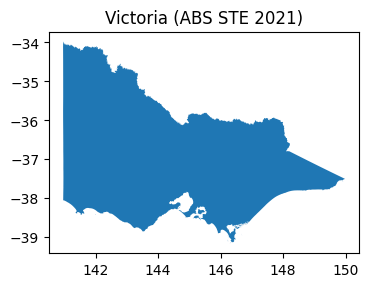

Clip to Victoria: 563486 → 319541 rows
Saved: viirs_vic_clean.csv
Unique sources: ['VIIRS_SNPP_SP' 'VIIRS_NOAA20_SP']
Date range: 2018-10-01 03:35:00 → 2024-03-31 14:57:00


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,source,chunk_start,acq_hour,acq_min,acq_datetime_utc
0,-38.53872,143.25966,326.51,0.39,0.37,2018-10-01,0426,N,VIIRS,n,2,292.70,1.73,D,0,VIIRS_SNPP_SP,2018-10-01,4,26,2018-10-01 04:26:00
1,-38.48909,143.19884,325.16,0.39,0.36,2018-10-01,0426,N,VIIRS,n,2,289.89,1.66,D,0,VIIRS_SNPP_SP,2018-10-01,4,26,2018-10-01 04:26:00
2,-38.45333,145.92444,335.81,0.47,0.39,2018-10-01,0426,N,VIIRS,n,2,291.59,4.26,D,0,VIIRS_SNPP_SP,2018-10-01,4,26,2018-10-01 04:26:00
3,-38.10720,141.84286,332.29,0.38,0.36,2018-10-01,0426,N,VIIRS,n,2,287.98,2.06,D,0,VIIRS_SNPP_SP,2018-10-01,4,26,2018-10-01 04:26:00
4,-38.09936,142.32117,338.38,0.39,0.36,2018-10-01,0426,N,VIIRS,n,2,294.86,2.95,D,0,VIIRS_SNPP_SP,2018-10-01,4,26,2018-10-01 04:26:00


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import os, zipfile, glob
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build UTC datetime column from acq_date + acq_time
#    acq_time is HHMM (e.g., 426 means 04:26)
# -----------------------------
df = viirs_raw.copy()

# Ensure strings with zero-padding
df["acq_date"] = pd.to_datetime(df["acq_date"], errors="coerce")
df["acq_time"] = df["acq_time"].astype(str).str.zfill(4)  # "0426"
df["acq_hour"] = df["acq_time"].str[:2].astype(int)
df["acq_min"]  = df["acq_time"].str[2:].astype(int)

# FIRMS timestamps are effectively UTC for these products; we store as UTC-naive or set tz=UTC
df["acq_datetime_utc"] = (
    df["acq_date"]
    + pd.to_timedelta(df["acq_hour"], unit="h")
    + pd.to_timedelta(df["acq_min"], unit="m")
)

# Basic sanity check
print(df["acq_datetime_utc"].min(), "→", df["acq_datetime_utc"].max())

# -----------------------------
# 2) Confidence filter (VIIRS usually: l=low, n=nominal, h=high)
#    Default: keep nominal + high
# -----------------------------
if "confidence" in df.columns:
    df["confidence"] = df["confidence"].astype(str).str.lower()
    keep_conf = {"n", "h", "nominal", "high"}  # supports both encodings
    before = len(df)
    df = df[df["confidence"].isin(keep_conf)].copy()
    print(f"Confidence filter: {before} → {len(df)} rows")
else:
    print("No 'confidence' column found; skipping confidence filter.")

# -----------------------------
# 3) Download ABS States/Territories boundary (STE 2021, GDA2020)
# -----------------------------
abs_url = "https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/access-and-downloads/digital-boundary-files/STE_2021_AUST_SHP_GDA2020.zip"
zip_path = "STE_2021_AUST_SHP_GDA2020.zip"
out_dir = "abs_ste_2021"

if not os.path.exists(zip_path):
    !wget -q -O {zip_path} "{abs_url}"

os.makedirs(out_dir, exist_ok=True)
if not os.path.exists(os.path.join(out_dir, "unzipped.flag")):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    open(os.path.join(out_dir, "unzipped.flag"), "w").close()

shp_files = glob.glob(os.path.join(out_dir, "**", "*.shp"), recursive=True)
assert len(shp_files) > 0, "No .shp found after unzip."
ste_path = shp_files[0]
print("Using shapefile:", ste_path)

ste = gpd.read_file(ste_path)
print("STE CRS:", ste.crs)

# -----------------------------
# 4) Extract Victoria polygon
# -----------------------------
# Find name column that contains 'Victoria'
name_cols = [c for c in ste.columns if "NAME" in c.upper()]
if not name_cols:
    raise ValueError(f"Could not find a NAME column in STE file. Columns: {list(ste.columns)}")

# Choose the name column that has 'Victoria' in its values
name_col = None
for c in name_cols:
    if ste[c].astype(str).str.contains("Victoria", case=False, na=False).any():
        name_col = c
        break

if name_col is None:
    raise ValueError(f"Couldn't locate 'Victoria' in any NAME columns: {name_cols}")

vic = ste[ste[name_col].astype(str).str.lower() == "victoria"].copy()
print("Victoria rows:", len(vic))
assert len(vic) == 1, "Expected exactly 1 Victoria polygon."

# Optional quick plot (visual sanity check)
vic.to_crs("EPSG:4326").plot(figsize=(4,4))
plt.title("Victoria (ABS STE 2021)")
plt.show()

# -----------------------------
# 5) Convert points to GeoDataFrame and clip to Victoria
# -----------------------------
# Create points in WGS84 first
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Reproject points to match VIC polygon CRS (often EPSG:7844 / GDA2020)
gdf = gdf.to_crs(vic.crs)

before = len(gdf)
# Spatial join is usually faster than clip for points
gdf_vic = gpd.sjoin(gdf, vic[["geometry"]], predicate="within", how="inner").drop(columns=["index_right"])
print(f"Clip to Victoria: {before} → {len(gdf_vic)} rows")

# -----------------------------
# 6) Save clean Victoria-only points
# -----------------------------
# Drop geometry for CSV output
viirs_vic_clean = gdf_vic.drop(columns="geometry")

out_csv = "viirs_vic_clean.csv"
viirs_vic_clean.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Quick sanity checks
print("Unique sources:", viirs_vic_clean["source"].unique() if "source" in viirs_vic_clean.columns else "no source col")
print("Date range:", viirs_vic_clean["acq_datetime_utc"].min(), "→", viirs_vic_clean["acq_datetime_utc"].max())
viirs_vic_clean.head()


In [ ]:
!pip -q install scikit-learn

import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv("viirs_vic_clean.csv", parse_dates=["acq_datetime_utc"])
df = df.sort_values("acq_datetime_utc").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["acq_datetime_utc"].min(), "→", df["acq_datetime_utc"].max())

# -----------------------------
# Parameters (v1 defaults)
# -----------------------------
SPATIAL_EPS_KM = 3.0
MIN_POINTS = 3
TEMPORAL_GAP_HR = 24.0  # split events if time gap > 24h inside a spatial cluster

EARTH_RADIUS_KM = 6371.0088

# -----------------------------
# Stage A: spatial clustering with haversine DBSCAN (2D only)
# -----------------------------
coords_rad = np.radians(df[["latitude", "longitude"]].values)

db_spatial = DBSCAN(
    eps=SPATIAL_EPS_KM / EARTH_RADIUS_KM,
    min_samples=MIN_POINTS,
    metric="haversine",
    n_jobs=-1
)

spatial_labels = db_spatial.fit_predict(coords_rad)
df["spatial_cluster"] = spatial_labels

num_noise = (df["spatial_cluster"] == -1).sum()
num_spatial_clusters = df.loc[df["spatial_cluster"] != -1, "spatial_cluster"].nunique()
print("Spatial noise points:", num_noise)
print("Spatial clusters:", num_spatial_clusters)

# -----------------------------
# Stage B: temporal splitting within each spatial cluster
# -----------------------------
event_id = -1
event_ids = np.full(len(df), -1, dtype=int)

gap = pd.Timedelta(hours=TEMPORAL_GAP_HR)

for sc_id, g_idx in df[df["spatial_cluster"] != -1].groupby("spatial_cluster").groups.items():
    idx = np.array(list(g_idx))
    g = df.loc[idx].sort_values("acq_datetime_utc")

    # split when gap between consecutive points exceeds TEMPORAL_GAP_HR
    splits = (g["acq_datetime_utc"].diff() > gap).cumsum()

    for _, part in g.groupby(splits):
        if len(part) < MIN_POINTS:
            continue
        event_id += 1
        event_ids[part.index.values] = event_id

df["event_id"] = event_ids

# Summary
num_events = (df["event_id"] != -1).sum()
unique_events = df.loc[df["event_id"] != -1, "event_id"].nunique()

print("Points assigned to events:", num_events)
print("Detected events:", unique_events)
print("Unassigned (noise) points:", (df["event_id"] == -1).sum())

# -----------------------------
# Build event-level table
# -----------------------------
events = []
for eid, g in df[df["event_id"] != -1].groupby("event_id"):
    g = g.sort_values("acq_datetime_utc")

    t0 = g["acq_datetime_utc"].iloc[0]  # first detection time
    early = g.head(3)  # centroid from earliest points
    events.append({
        "event_id": int(eid),
        "t0": t0,
        "centroid_lat": early["latitude"].mean(),
        "centroid_lon": early["longitude"].mean(),
        "num_detections": len(g),
        "start_time": g["acq_datetime_utc"].min(),
        "end_time": g["acq_datetime_utc"].max(),
        "duration_hours": (g["acq_datetime_utc"].max() - g["acq_datetime_utc"].min()).total_seconds() / 3600.0
    })

events_df = pd.DataFrame(events).sort_values("t0").reset_index(drop=True)

# Save outputs
df.to_csv("viirs_vic_with_event_ids.csv", index=False)
events_df.to_csv("events_vic.csv", index=False)

print("\nSaved:")
print(" - viirs_vic_with_event_ids.csv (point-level with event_id)")
print(" - events_vic.csv (event-level)")
events_df.head()


Rows: 319541
Date range: 2018-10-01 03:35:00 → 2024-03-31 14:57:00
Spatial noise points: 1083
Spatial clusters: 1128
Points assigned to events: 310855
Detected events: 4081
Unassigned (noise) points: 8686

Saved:
 - viirs_vic_with_event_ids.csv (point-level with event_id)
 - events_vic.csv (event-level)


,event_id,t0,centroid_lat,centroid_lon,num_detections,start_time,end_time,duration_hours
0,1,2018-10-01 03:35:00,-37.539197,143.446020,14,2018-10-01 03:35:00,2018-10-01 05:15:00,1.666667
1,364,2018-10-01 03:35:00,-36.226543,145.318287,3,2018-10-01 03:35:00,2018-10-01 04:26:00,0.850000
2,735,2018-10-01 04:26:00,-38.066943,142.287683,4,2018-10-01 04:26:00,2018-10-02 16:18:00,35.866667
3,801,2018-10-02 03:16:00,-37.314123,141.602310,5,2018-10-02 03:16:00,2018-10-02 15:28:00,12.200000
4,969,2018-10-02 15:28:00,-37.236117,141.297630,4,2018-10-02 15:28:00,2018-10-02 16:18:00,0.833333


In [ ]:
import pandas as pd

events = pd.read_csv(
    "events_vic.csv",
    parse_dates=["t0", "start_time", "end_time"]
)

LOOKBACK_MIN = 60
WINDOW_OFFSETS_MIN = [10, 30, 60]
lookback = pd.Timedelta(minutes=LOOKBACK_MIN)

samples = []

for _, row in events.iterrows():
    event_id = int(row["event_id"])
    t0 = row["t0"]

    for offset in WINDOW_OFFSETS_MIN:
        window_end = t0 - pd.Timedelta(minutes=offset)
        window_start = window_end - lookback

        # Only true safety check: window must end before t0
        if window_end >= t0:
            continue

        samples.append({
            "sample_id": f"pos_e{event_id}_m{offset}",
            "event_id": event_id,
            "label": 1,
            "window_end_offset_min": offset,
            "window_start": window_start,
            "window_end": window_end,
            "t0": t0,
            "centroid_lat": row["centroid_lat"],
            "centroid_lon": row["centroid_lon"]
        })

samples_pos = pd.DataFrame(samples)

print("Total events:", len(events))
print("Positive samples generated:", len(samples_pos))
samples_pos.head()


Total events: 4081
Positive samples generated: 12243


,sample_id,event_id,label,window_end_offset_min,window_start,window_end,t0,centroid_lat,centroid_lon
0,pos_e1_m10,1,1,10,2018-10-01 02:25:00,2018-10-01 03:25:00,2018-10-01 03:35:00,-37.539197,143.446020
1,pos_e1_m30,1,1,30,2018-10-01 02:05:00,2018-10-01 03:05:00,2018-10-01 03:35:00,-37.539197,143.446020
2,pos_e1_m60,1,1,60,2018-10-01 01:35:00,2018-10-01 02:35:00,2018-10-01 03:35:00,-37.539197,143.446020
3,pos_e364_m10,364,1,10,2018-10-01 02:25:00,2018-10-01 03:25:00,2018-10-01 03:35:00,-36.226543,145.318287
4,pos_e364_m30,364,1,30,2018-10-01 02:05:00,2018-10-01 03:05:00,2018-10-01 03:35:00,-36.226543,145.318287


In [ ]:
samples_pos.to_csv("samples_positive.csv", index=False)
print("Saved samples_positive.csv")


Saved samples_positive.csv


In [ ]:
!pip -q install scikit-learn

import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# -----------------------------
# Load data
# -----------------------------
pts = pd.read_csv("viirs_vic_clean.csv", parse_dates=["acq_datetime_utc"])
pos = pd.read_csv("samples_positive.csv", parse_dates=["window_start","window_end","t0"])

print("Points:", len(pts))
print("Positives:", len(pos))

# -----------------------------
# Parameters (v1 defaults)
# -----------------------------
NEG_PER_POS = 2

R_KM = 15.0                 # exclusion radius
TIME_BUFFER_HR = 6.0        # exclusion time buffer around window_end
MAX_TRIES = 50              # retries per negative to find a valid one

MATCH_SHIFT_DAYS = 30       # matched negative day shift range (±30 days)
NEARBY_MIN_KM = 20.0        # location shift minimum
NEARBY_MAX_KM = 100.0       # location shift maximum

EARTH_RADIUS_KM = 6371.0088
R_RAD = R_KM / EARTH_RADIUS_KM

# -----------------------------
# Build spatial index (BallTree) for fast radius queries
# -----------------------------
coords_rad = np.radians(pts[["latitude","longitude"]].values)
tree = BallTree(coords_rad, metric="haversine")

# Convert time to hours since epoch for quick filtering
pts_time_hr = pts["acq_datetime_utc"].astype("int64") / 1e9 / 3600.0

# Helper: check if window_end is "clean" (no detections near in space+time)
def is_clean(lat, lon, window_end_dt):
    q = np.radians([[lat, lon]])
    idx = tree.query_radius(q, r=R_RAD, return_distance=False)[0]
    if len(idx) == 0:
        return True
    we_hr = window_end_dt.value / 1e9 / 3600.0
    # time filter within ± buffer
    near_times = pts_time_hr.iloc[idx]
    return not ((near_times >= we_hr - TIME_BUFFER_HR) & (near_times <= we_hr + TIME_BUFFER_HR)).any()

# Helper: random shift day keeping same time-of-day
def shift_day(dt, shift_days):
    return dt + pd.Timedelta(days=int(shift_days))

# Helper: random nearby point within [min_km, max_km]
def random_nearby_latlon(lat, lon, min_km=NEARBY_MIN_KM, max_km=NEARBY_MAX_KM):
    # random distance and bearing
    d = np.random.uniform(min_km, max_km) / EARTH_RADIUS_KM  # radians
    brng = np.random.uniform(0, 2*np.pi)

    lat1 = np.radians(lat)
    lon1 = np.radians(lon)

    lat2 = np.arcsin(np.sin(lat1)*np.cos(d) + np.cos(lat1)*np.sin(d)*np.cos(brng))
    lon2 = lon1 + np.arctan2(np.sin(brng)*np.sin(d)*np.cos(lat1),
                             np.cos(d)-np.sin(lat1)*np.sin(lat2))

    return float(np.degrees(lat2)), float((np.degrees(lon2)+540)%360-180)  # normalize lon

# -----------------------------
# Generate negatives
# -----------------------------
neg_rows = []

for i, r in pos.iterrows():
    base_id = r["sample_id"]
    lat = float(r["centroid_lat"])
    lon = float(r["centroid_lon"])
    w_end = r["window_end"]
    w_start = r["window_start"]
    offset = int(r["window_end_offset_min"])

    # ---- NEG 1: matched-day negative (same location, different day)
    ok = False
    for _ in range(MAX_TRIES):
        shift = np.random.randint(-MATCH_SHIFT_DAYS, MATCH_SHIFT_DAYS + 1)
        if shift == 0:
            continue
        cand_end = shift_day(w_end, shift)
        cand_start = cand_end - (w_end - w_start)

        # Ensure within global data range
        if cand_end < pts["acq_datetime_utc"].min() or cand_end > pts["acq_datetime_utc"].max():
            continue

        if is_clean(lat, lon, cand_end):
            neg_rows.append({
                "sample_id": f"neg_match_{base_id}",
                "source_pos_id": base_id,
                "neg_type": "matched_day_same_loc",
                "event_id": r["event_id"],
                "label": 0,
                "window_end_offset_min": offset,
                "window_start": cand_start,
                "window_end": cand_end,
                "t0": r["t0"],
                "centroid_lat": lat,
                "centroid_lon": lon
            })
            ok = True
            break
    if not ok:
        # If it fails, we skip rather than add noisy negatives
        pass

    # ---- NEG 2: same-day nearby-location negative (confuser)
    ok = False
    for _ in range(MAX_TRIES):
        lat2, lon2 = random_nearby_latlon(lat, lon)
        cand_end = w_end
        cand_start = w_start

        if is_clean(lat2, lon2, cand_end):
            neg_rows.append({
                "sample_id": f"neg_near_{base_id}",
                "source_pos_id": base_id,
                "neg_type": "same_day_nearby_loc",
                "event_id": r["event_id"],
                "label": 0,
                "window_end_offset_min": offset,
                "window_start": cand_start,
                "window_end": cand_end,
                "t0": r["t0"],
                "centroid_lat": lat2,
                "centroid_lon": lon2
            })
            ok = True
            break
    if not ok:
        pass

    # Progress print every 1000 positives
    if (i+1) % 1000 == 0:
        print(f"Processed {i+1}/{len(pos)} positives, negatives so far: {len(neg_rows)}")

neg = pd.DataFrame(neg_rows)

print("\nNegatives generated:", len(neg))
print(neg["neg_type"].value_counts(dropna=False))

neg.to_csv("samples_negative.csv", index=False)
print("Saved samples_negative.csv")
neg.head()


Points: 319541
Positives: 12243
Processed 1000/12243 positives, negatives so far: 2000
Processed 2000/12243 positives, negatives so far: 4000
Processed 3000/12243 positives, negatives so far: 6000
Processed 4000/12243 positives, negatives so far: 8000
Processed 5000/12243 positives, negatives so far: 10000
Processed 6000/12243 positives, negatives so far: 12000
Processed 7000/12243 positives, negatives so far: 14000
Processed 8000/12243 positives, negatives so far: 16000
Processed 9000/12243 positives, negatives so far: 18000
Processed 10000/12243 positives, negatives so far: 20000
Processed 11000/12243 positives, negatives so far: 22000
Processed 12000/12243 positives, negatives so far: 24000

Negatives generated: 24486
neg_type
matched_day_same_loc    12243
same_day_nearby_loc     12243
Name: count, dtype: int64
Saved samples_negative.csv


,sample_id,source_pos_id,neg_type,event_id,label,window_end_offset_min,window_start,window_end,t0,centroid_lat,centroid_lon
0,neg_match_pos_e1_m10,pos_e1_m10,matched_day_same_loc,1,0,10,2018-10-26 02:25:00,2018-10-26 03:25:00,2018-10-01 03:35:00,-37.539197,143.446020
1,neg_near_pos_e1_m10,pos_e1_m10,same_day_nearby_loc,1,0,10,2018-10-01 02:25:00,2018-10-01 03:25:00,2018-10-01 03:35:00,-37.690543,144.411663
2,neg_match_pos_e1_m30,pos_e1_m30,matched_day_same_loc,1,0,30,2018-10-03 02:05:00,2018-10-03 03:05:00,2018-10-01 03:35:00,-37.539197,143.446020
3,neg_near_pos_e1_m30,pos_e1_m30,same_day_nearby_loc,1,0,30,2018-10-01 02:05:00,2018-10-01 03:05:00,2018-10-01 03:35:00,-37.778381,143.728836
4,neg_match_pos_e1_m60,pos_e1_m60,matched_day_same_loc,1,0,60,2018-10-27 01:35:00,2018-10-27 02:35:00,2018-10-01 03:35:00,-37.539197,143.446020


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# Load data
# -----------------------------
samples = pd.read_csv("samples_index.csv", parse_dates=["window_end","t0"])

# -----------------------------
# Build event-level split map using t0
# -----------------------------
events = (
    samples[["event_id","t0"]]
    .drop_duplicates()
    .copy()
)

# Derive season_year from t0 (NOT window_end)
month = events["t0"].dt.month
year  = events["t0"].dt.year

events["season_year"] = np.where(month >= 10, year + 1, year)

def assign_split(season_year):
    if season_year <= 2022:
        return "train"
    elif season_year == 2023:
        return "val"
    elif season_year == 2024:
        return "test"
    else:
        return "holdout"

events["split"] = events["season_year"].apply(assign_split)

print(events["split"].value_counts())

# -----------------------------
# Merge split back to samples
# -----------------------------
samples = samples.drop(columns=["split"], errors="ignore")
samples = samples.merge(
    events[["event_id","split"]],
    on="event_id",
    how="left"
)

# Keep only train/val/test
samples = samples[samples["split"].isin(["train","val","test"])].copy()

# -----------------------------
# Leakage check (should now be 0)
# -----------------------------
leak_check = (
    samples[["event_id","split"]]
    .drop_duplicates()
    .groupby("event_id")["split"]
    .nunique()
)

leaky = leak_check[leak_check > 1]

print("Leaky events (should be 0):", len(leaky))

# -----------------------------
# Label balance per split
# -----------------------------
print("\nLabel counts per split:")
print(samples.groupby(["split","label"]).size().unstack(fill_value=0))

# -----------------------------
# Save corrected final index
# -----------------------------
samples = samples.sort_values(["split","window_end","sample_id"]).reset_index(drop=True)
samples.to_csv("samples_index.csv", index=False)

print("\nSaved corrected samples_index.csv")
samples.head()


split
train    3122
val       704
test      255
Name: count, dtype: int64
Leaky events (should be 0): 0

Label counts per split:
label      0     1
split             
test    1530   765
train  18732  9366
val     4224  2112

Saved corrected samples_index.csv


,sample_id,event_id,label,window_end_offset_min,window_start,window_end,t0,centroid_lat,centroid_lon,source_pos_id,neg_type,month,year,season_year,season,split
0,neg_match_pos_e2325_m60,2325,0,60,2023-09-05 01:49:00,2023-09-05 02:49:00,2023-10-01 03:49:00,-37.751463,147.111523,pos_e2325_m60,matched_day_same_loc,9,2023,2023,2022-23,test
1,neg_match_pos_e2397_m30,2397,0,30,2023-09-05 02:19:00,2023-09-05 03:19:00,2023-10-01 03:49:00,-37.976153,146.421140,pos_e2397_m30,matched_day_same_loc,9,2023,2023,2022-23,test
2,neg_match_pos_e1448_m30,1448,0,30,2023-09-11 03:09:00,2023-09-11 04:09:00,2023-10-09 04:39:00,-37.626187,141.291737,pos_e1448_m30,matched_day_same_loc,9,2023,2023,2022-23,test
3,neg_match_pos_e1304_m30,1304,0,30,2023-09-11 12:43:00,2023-09-11 13:43:00,2023-10-04 14:13:00,-37.831930,144.786520,pos_e1304_m30,matched_day_same_loc,9,2023,2023,2022-23,test
4,neg_match_pos_e358_m30,358,0,30,2023-09-12 03:09:00,2023-09-12 04:09:00,2023-10-09 04:39:00,-36.880557,141.868287,pos_e358_m30,matched_day_same_loc,9,2023,2023,2022-23,test


In [ ]:
!ls -lh /content


total 116M
drwxr-xr-x 2 root root 4.0K Jan 22 09:16 abs_ste_2021
-rw-r--r-- 1 root root 450K Jan 22 09:27 events_vic.csv
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
-rw-r--r-- 1 root root 6.1M Jan 22 10:01 samples_index.csv
-rw-r--r-- 1 root root 3.8M Jan 22 09:46 samples_negative.csv
-rw-r--r-- 1 root root 1.4M Jan 22 09:36 samples_positive.csv
-rw-r--r-- 1 root root  21M Jun 24  2021 STE_2021_AUST_SHP_GDA2020.zip
-rw-r--r-- 1 root root  41M Jan 22 09:17 viirs_vic_clean.csv
-rw-r--r-- 1 root root  43M Jan 22 09:27 viirs_vic_with_event_ids.csv


In [ ]:
from google.colab import files

for f in [
    "viirs_vic_clean.csv",
    "viirs_vic_with_event_ids.csv",
    "events_vic.csv",
    "samples_positive.csv",
    "samples_negative.csv",
    "samples_index.csv"
]:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh /content

total 4.0K
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [ ]:
from google.colab import files
files.upload()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!ls -lh /content

total 95M
-rw-r--r-- 1 root root 450K Jan 22 14:09 events_vic.csv
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
-rw-r--r-- 1 root root 6.1M Jan 22 14:09 samples_index.csv
-rw-r--r-- 1 root root 3.8M Jan 22 14:09 samples_negative.csv
-rw-r--r-- 1 root root 1.4M Jan 22 14:09 samples_positive.csv
-rw-r--r-- 1 root root  41M Jan 22 14:09 viirs_vic_clean.csv
-rw-r--r-- 1 root root  43M Jan 22 14:09 viirs_vic_with_event_ids.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/vic_bushfire_dataset", exist_ok=True)
!cp /content/*.csv /content/drive/MyDrive/vic_bushfire_dataset/


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

SAMPLES_PATH = "/content/samples_index.csv"
EVENTS_PATH  = "/content/events_vic.csv"

samples = pd.read_csv(
    SAMPLES_PATH,
    parse_dates=["window_start","window_end","t0"]
)
events = pd.read_csv(
    EVENTS_PATH,
    parse_dates=["t0","start_time","end_time"]
)

print("samples:", samples.shape)
print("events:", events.shape)
print(samples["split"].value_counts())


samples: (36729, 16)
events: (4081, 8)
split
train    28098
val       6336
test      2295
Name: count, dtype: int64


In [ ]:
event_split = (
    samples[["event_id","split"]]
    .drop_duplicates()
    .set_index("event_id")["split"]
)

events2 = events.copy()
events2["split"] = events2["event_id"].map(event_split)
events2 = events2[events2["split"].isin(["train","val","test"])].copy()

events2["split"].value_counts()


,count
split,
train,3122
val,704
test,255


In [ ]:
rng = np.random.default_rng(42)

pilot_ids = []
for sp, k in [("train", 4), ("val", 3), ("test", 3)]:
    cand = events2.loc[events2["split"] == sp, "event_id"].values
    k = min(k, len(cand))
    pilot_ids.extend(rng.choice(cand, size=k, replace=False).tolist())

pilot_events = (
    events2[events2["event_id"].isin(pilot_ids)]
    .sort_values(["split","t0"])
    .reset_index(drop=True)
)

pilot_events[[
    "event_id","split","t0",
    "centroid_lat","centroid_lon",
    "num_detections","duration_hours"
]]


,event_id,split,t0,centroid_lat,centroid_lon,num_detections,duration_hours
0,2327,test,2024-03-24 04:07:00,-37.829437,147.139107,15,35.050000
1,2834,test,2024-03-24 04:08:00,-36.533760,147.358107,80,143.783333
2,2655,test,2024-03-25 03:49:00,-36.465620,142.235357,37,49.050000
3,2564,train,2019-03-28 04:39:00,-38.030443,141.024963,9,10.500000
4,2361,train,2020-03-24 15:21:00,-37.346440,145.235667,3,0.000000
5,2645,train,2021-03-29 05:03:00,-36.404343,142.207297,3,0.000000
6,1169,train,2021-05-29 04:19:00,-37.802163,144.752710,4,47.366667
7,2524,val,2023-01-13 05:23:00,-38.164007,142.320083,3,0.000000
8,1775,val,2023-03-22 04:09:00,-36.439757,141.238427,63,72.733333
9,1286,val,2023-05-09 15:30:00,-37.832327,144.788183,5,47.366667


In [ ]:
PILOT_PATH = "/content/pilot_events_himawari.csv"
pilot_events.to_csv(PILOT_PATH, index=False)
print("Saved:", PILOT_PATH)


Saved: /content/pilot_events_himawari.csv


In [ ]:


!mkdir -p /content/drive/MyDrive/vic_bushfire_dataset
!cp /content/pilot_events_himawari.csv /content/drive/MyDrive/vic_bushfire_dataset/


In [ ]:
!pip -q install boto3 botocore xarray netCDF4 tqdm


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config

s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

BUCKET = "noaa-himawari8"


In [ ]:
def list_top_folders(bucket, max_keys=2000):
    resp = s3.list_objects_v2(Bucket=bucket, MaxKeys=max_keys)
    prefixes = set()
    for obj in resp.get("Contents", []):
        if "/" in obj["Key"]:
            prefixes.add(obj["Key"].split("/")[0])
    return sorted(prefixes)

top_folders = list_top_folders(BUCKET)
top_folders[:30], len(top_folders)


(['AHI-L1b-FLDK'], 1)

In [ ]:
import pandas as pd

pilot_events = pd.read_csv(
    "/content/pilot_events_himawari.csv",
    parse_dates=["t0"]
)

e = pilot_events.iloc[0]
t0 = e["t0"].to_pydatetime()

t0


datetime.datetime(2024, 3, 24, 4, 7)

In [ ]:
from datetime import timedelta

def round_down_10min(dt):
    return dt.replace(minute=(dt.minute // 10) * 10, second=0, microsecond=0)

t_probe = round_down_10min(t0)
t_probe


datetime.datetime(2024, 3, 24, 4, 0)

In [ ]:
PRODUCT = "AHI-L1b-FLDK"

def try_prefixes(product, dt):
    y = dt.year
    m = f"{dt.month:02d}"
    d = f"{dt.day:02d}"
    ddd = f"{dt.timetuple().tm_yday:03d}"
    hhmm = f"{dt.hour:02d}{dt.minute:02d}"

    return [
        f"{product}/{y}/{m}/{d}/{hhmm}/",
        f"{product}/{y}/{m}/{d}/",
        f"{product}/{y}/{ddd}/{hhmm}/",
        f"{product}/{y}/{ddd}/",
        f"{product}/{y}/",
        f"{product}/",
    ]

def find_keys(product, dt, max_keys=2000):
    for pref in try_prefixes(product, dt):
        resp = s3.list_objects_v2(
            Bucket=BUCKET,
            Prefix=pref,
            MaxKeys=max_keys
        )
        keys = [o["Key"] for o in resp.get("Contents", [])]
        if keys:
            return pref, keys
    return None, []

prefix, keys = find_keys(PRODUCT, t_probe)

print("Prefix found:", prefix)
print("Number of files:", len(keys))
print("Example keys:")
for k in keys[:5]:
    print(" ", k)


Prefix found: AHI-L1b-FLDK/
Number of files: 1000
Example keys:
  AHI-L1b-FLDK/2015/07/07/0200/HS_H08_20150707_0200_B01_FLDK_R10_S0101.DAT.bz2
  AHI-L1b-FLDK/2015/07/07/0200/HS_H08_20150707_0200_B01_FLDK_R20_S0101.DAT.bz2
  AHI-L1b-FLDK/2015/07/07/0200/HS_H08_20150707_0200_B02_FLDK_R10_S0101.DAT.bz2
  AHI-L1b-FLDK/2015/07/07/0200/HS_H08_20150707_0200_B02_FLDK_R20_S0101.DAT.bz2
  AHI-L1b-FLDK/2015/07/07/0200/HS_H08_20150707_0200_B03_FLDK_R05_S0101.DAT.bz2


In [ ]:
import os
import bz2
import shutil

# pick ONE file from the list
key = keys[0]

local_dir = "/content/himawari_pilot_raw"
os.makedirs(local_dir, exist_ok=True)

compressed_path = os.path.join(local_dir, os.path.basename(key))
decompressed_path = compressed_path.replace(".bz2", "")

# download
s3.download_file(BUCKET, key, compressed_path)
print("Downloaded:", compressed_path)

# decompress
with bz2.open(compressed_path, "rb") as f_in:
    with open(decompressed_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Decompressed to:", decompressed_path)


Downloaded: /content/himawari_pilot_raw/HS_H08_20150707_0200_B01_FLDK_R10_S0101.DAT.bz2
Decompressed to: /content/himawari_pilot_raw/HS_H08_20150707_0200_B01_FLDK_R10_S0101.DAT


In [ ]:
import os

os.path.getsize(decompressed_path)


242002083

In [ ]:
!pip -q install satpy pyresample pyproj dask[complete] xarray netCDF4 boto3 botocore tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.8/484.8 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.3/708.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.6/82.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os, bz2, shutil, re
import boto3
from botocore import UNSIGNED
from botocore.client import Config

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
BUCKET = "noaa-himawari8"
PRODUCT = "AHI-L1b-FLDK"

RAW_DIR = "/content/himawari_pilot_raw"
os.makedirs(RAW_DIR, exist_ok=True)

def download_and_decompress(key, out_dir=RAW_DIR):
    """Download .DAT.bz2 from S3 and decompress to .DAT. Returns .DAT path."""
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    dat_path = bz2_path.replace(".bz2", "")

    if not os.path.exists(bz2_path):
        s3.download_file(BUCKET, key, bz2_path)

    if not os.path.exists(dat_path) or os.path.getsize(dat_path) == 0:
        with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    return dat_path


In [ ]:
def list_keys_for_time(dt):
    """List keys inside AHI-L1b-FLDK/YYYY/MM/DD/HHMM/"""
    prefix = f"{PRODUCT}/{dt.year:04d}/{dt.month:02d}/{dt.day:02d}/{dt.hour:02d}{dt.minute:02d}/"
    resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix, MaxKeys=5000)
    keys = [o["Key"] for o in resp.get("Contents", [])]
    return prefix, keys

def pick_key(keys, band="B01", res="R10"):
    """Pick one key matching band and resolution."""
    pat = re.compile(rf"_({band})_FLDK_({res})_.*\.DAT\.bz2$")
    matches = [k for k in keys if pat.search(k)]
    return matches[0] if matches else None


In [ ]:
from satpy import Scene

def load_band_dat(dat_path, band_name="B01"):
    """
    Read Himawari AHI HSD .DAT using Satpy.
    Returns: DataArray with .values and .attrs['area'] (navigation/projection)
    """
    scn = Scene(reader="ahi_hsd", filenames=[dat_path])
    scn.load([band_name])          # band name matches e.g. "B01"
    da = scn[band_name]            # xarray DataArray
    return da


In [ ]:
# Put your decompressed_path here (from earlier)
# decompressed_path = "/content/himawari_pilot_raw/HS_H08_20150707_0200_B01_FLDK_R10_S0101.DAT"

da = load_band_dat(decompressed_path, "B01")
print(da)
print("shape:", da.shape, "dtype:", da.dtype)

area = da.attrs.get("area")
print("Has area:", area is not None)


<xarray.DataArray 'clip-583ea3655ece1f1808ac608c85b6ad09' (y: 11000, x: 11000)> Size: 484MB
dask.array<where, shape=(11000, 11000), dtype=float32, chunksize=(2750, 2750), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 88kB 5.5e+06 5.499e+06 ... -5.499e+06 -5.5e+06
  * x        (x) float64 88kB -5.5e+06 -5.499e+06 ... 5.499e+06 5.5e+06
    crs      object 8B PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["unknown...
Attributes: (12/18)
    orbital_parameters:   {'projection_longitude': 140.7, 'projection_latitud...
    units:                %
    standard_name:        toa_bidirectional_reflectance
    wavelength:           0.47 µm (0.45-0.49 µm)
    resolution:           1000
    id:                   DataID(name='B01', wavelength=WavelengthRange(min=0...
    ...                   ...
    reader:               ahi_hsd
    area:                 Area ID: FLDK\nDescription: AHI FLDK area\nProjecti...
    calibration:          reflectance
    modifiers:            ()
    _sat

In [ ]:
from pyproj import Proj

def latlon_to_rc(area, lat, lon):
    """
    Convert lat/lon to (row, col) index in the DataArray grid using AreaDefinition.
    """
    # projection dict for geostationary
    proj = Proj(area.proj_dict)
    x, y = proj(lon, lat)  # meters in projection coords

    # area extent is (xmin, ymin, xmax, ymax)
    xmin, ymin, xmax, ymax = area.area_extent
    height, width = area.shape

    # convert x,y to col,row
    col = int((x - xmin) / (xmax - xmin) * width)
    row = int((ymax - y) / (ymax - ymin) * height)  # note y axis direction

    return row, col


In [ ]:
import numpy as np

def extract_patch(da, lat, lon, patch=32):
    """
    Extract patch x patch around (lat,lon). Returns patch array or None if out of bounds.
    """
    area = da.attrs["area"]
    r, c = latlon_to_rc(area, lat, lon)

    half = patch // 2
    r0, r1 = r - half, r + half
    c0, c1 = c - half, c + half

    # bounds check
    if r0 < 0 or c0 < 0 or r1 > da.shape[0] or c1 > da.shape[1]:
        return None

    patch_arr = da.values[r0:r1, c0:c1].astype(np.float32)
    return patch_arr


In [ ]:
import pandas as pd

pilot = pd.read_csv("/content/pilot_events_himawari.csv", parse_dates=["t0"])
e0 = pilot.iloc[0]
lat0, lon0 = float(e0["centroid_lat"]), float(e0["centroid_lon"])

p = extract_patch(da, lat0, lon0, patch=32)
print("patch:", None if p is None else p.shape)


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


patch: (32, 32)


In [ ]:
from datetime import timedelta

def round_down_10min(dt):
    return dt.replace(minute=(dt.minute // 10) * 10, second=0, microsecond=0)

def build_times(t0, minutes_back=120):
    t0r = round_down_10min(t0)
    n = minutes_back // 10
    return [t0r - timedelta(minutes=10*i) for i in range(n, -1, -1)]  # oldest → t0


In [ ]:
from tqdm import tqdm

def extract_event_timeseries(event_row, band="B01", res="R10", patch=32, minutes_back=120):
    event_id = int(event_row["event_id"])
    lat = float(event_row["centroid_lat"])
    lon = float(event_row["centroid_lon"])
    t0 = pd.Timestamp(event_row["t0"]).to_pydatetime()

    times = build_times(t0, minutes_back=minutes_back)

    patches = []
    kept_times = []

    for dt in tqdm(times, desc=f"event {event_id}"):
        prefix, keys = list_keys_for_time(dt)
        key = pick_key(keys, band=band, res=res)
        if key is None:
            continue

        dat_path = download_and_decompress(key)
        da = load_band_dat(dat_path, band)

        patch_arr = extract_patch(da, lat, lon, patch=patch)
        if patch_arr is None:
            continue

        patches.append(patch_arr)
        kept_times.append(dt)

    if len(patches) == 0:
        return None, None

    X = np.stack(patches, axis=0)  # [T, H, W]
    return X, kept_times


In [ ]:
e0 = pilot.iloc[0]
X, kept_times = extract_event_timeseries(e0, band="B01", res="R10", patch=32, minutes_back=120)

print("X:", None if X is None else X.shape)
print("frames kept:", 0 if kept_times is None else len(kept_times))
print("first/last time:", None if kept_times is None else (kept_times[0], kept_times[-1]))


event 2327: 100%|██████████| 13/13 [00:03<00:00,  3.58it/s]

X: None
frames kept: 0
first/last time: None


In [ ]:
import json, os, numpy as np
import pandas as pd

OUT_DIR = "/content/pilot_h8"
os.makedirs(OUT_DIR, exist_ok=True)

if X is None or kept_times is None or len(kept_times) == 0:
    print("❌ Nothing to save: X/kept_times is empty.")
    print("Tip: run the debug cell below to see why no frames were collected.")
else:
    event_id = int(e0["event_id"])
    event_dir = os.path.join(OUT_DIR, f"event_{event_id}")
    os.makedirs(event_dir, exist_ok=True)

    np.save(os.path.join(event_dir, "X.npy"), X)

    meta = {
        "event_id": event_id,
        "band": "B01",
        "res": "R10",
        "patch": 32,
        "frames_kept": int(len(kept_times)),
        "times": [t.isoformat() for t in kept_times],
        "centroid_lat": float(e0["centroid_lat"]),
        "centroid_lon": float(e0["centroid_lon"]),
        "t0": pd.Timestamp(e0["t0"]).isoformat(),
        "split": str(e0["split"]),
    }
    with open(os.path.join(event_dir, "meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    print("✅ Saved:", event_dir, "| X shape:", X.shape)


❌ Nothing to save: X/kept_times is empty.
Tip: run the debug cell below to see why no frames were collected.


In [ ]:
print("X is None?", X is None)
print("kept_times is None?", kept_times is None)
if kept_times:
    print("frames kept:", len(kept_times), "first:", kept_times[0], "last:", kept_times[-1])


X is None? True
kept_times is None? True


In [ ]:
# check 1 timestamp near your event to confirm keys exist for the SAME YEAR as the event
from datetime import timedelta

dt = round_down_10min(pd.Timestamp(e0["t0"]).to_pydatetime())
prefix, keys_dt = list_keys_for_time(dt)
print("t0 rounded:", dt)
print("prefix:", prefix)
print("keys in folder:", len(keys_dt))

# see what bands/resolutions exist there
print("sample keys:")
for k in keys_dt[:20]:
    print(" ", k)

# try picking B01 R10 specifically
k_b01 = pick_key(keys_dt, band="B01", res="R10")
print("picked B01 R10:", k_b01)


t0 rounded: 2024-03-24 04:00:00
prefix: AHI-L1b-FLDK/2024/03/24/0400/
keys in folder: 0
sample keys:
picked B01 R10: None


In [ ]:
from datetime import timedelta
import pandas as pd

def find_nearest_himawari_time(dt, search_hours=12):
    """
    Search around dt in +/- search_hours at 10-min increments
    to find the nearest timestamp that exists in S3.
    """
    dt = pd.Timestamp(dt).to_pydatetime()
    dt0 = round_down_10min(dt)

    candidates = []
    # Search outward: 0, 10, 20, ..., search_hours*60 minutes
    for step in range(0, search_hours*6 + 1):
        for sign in [0, -1, +1]:
            if step == 0 and sign != 0:
                continue
            cand = dt0 + timedelta(minutes=10*step*sign)
            prefix, keys = list_keys_for_time(cand)
            if len(keys) > 0:
                return cand, prefix, keys
    return None, None, []

# Use your pilot event t0
t0_raw = pd.Timestamp(e0["t0"]).to_pydatetime()
nearest_dt, nearest_prefix, nearest_keys = find_nearest_himawari_time(t0_raw, search_hours=12)

print("Original t0:", t0_raw)
print("Nearest available:", nearest_dt)
print("Prefix:", nearest_prefix)
print("Keys found:", len(nearest_keys))
print("Example keys:", nearest_keys[:5])


Original t0: 2024-03-24 04:07:00
Nearest available: None
Prefix: None
Keys found: 0
Example keys: []


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config

BUCKET = "noaa-himawari8"

s3 = boto3.client(
    "s3",
    region_name="us-west-2",                 # IMPORTANT
    config=Config(signature_version=UNSIGNED)
)


In [ ]:
dt = pd.Timestamp(e0["t0"]).to_pydatetime()
dt = round_down_10min(dt)
prefix = f"AHI-L1b-FLDK/{dt.year:04d}/{dt.month:02d}/{dt.day:02d}/{dt.hour:02d}{dt.minute:02d}/"
resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix, MaxKeys=5)
print("prefix:", prefix)
print("keys:", len(resp.get("Contents", [])))
print([o["Key"] for o in resp.get("Contents", [])])


prefix: AHI-L1b-FLDK/2024/03/24/0400/
keys: 0
[]


In [ ]:
from collections import defaultdict

def list_year_prefixes(max_pages=5):
    """List available year prefixes under AHI-L1b-FLDK/ using Delimiter."""
    paginator = s3.get_paginator("list_objects_v2")
    years = set()
    pages = 0

    for page in paginator.paginate(
        Bucket=BUCKET,
        Prefix="AHI-L1b-FLDK/",
        Delimiter="/",
        PaginationConfig={"PageSize": 1000}
    ):
        pages += 1
        for cp in page.get("CommonPrefixes", []):
            p = cp["Prefix"]  # e.g. AHI-L1b-FLDK/2015/
            parts = p.strip("/").split("/")
            if len(parts) >= 2 and parts[1].isdigit():
                years.add(parts[1])
        if pages >= max_pages:
            break

    return sorted(years)

years = list_year_prefixes(max_pages=20)
print("Found years (sample):", years[:20])
print("Total year prefixes:", len(years))
print("Has 2024?", "2024" in years)


Found years (sample): ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2025']
Total year prefixes: 9
Has 2024? False


In [ ]:
from satpy import Scene

scn = Scene(filenames=[dat_path])  # no reader specified

# version-safe introspection
print("Scene dir has readers?", "readers" in dir(scn))
print("Scene attributes (subset):", [a for a in ["_readers", "reader_kwargs", "available_dataset_names"] if a in dir(scn)])

print("Available datasets (first 30):", sorted(scn.available_dataset_names())[:30])


ERROR:satpy.readers.core.loading:Problem with ['/usr/local/lib/python3.12/dist-packages/satpy/etc/readers/mersi3_l1b.yaml']
ERROR:satpy.readers.core.loading:while constructing a Python object
cannot find module 'satpy.readers.mersi_l1b' (No module named 'pyspectral')
  in "/usr/local/lib/python3.12/dist-packages/satpy/etc/readers/mersi3_l1b.yaml", line 13, column 18
ERROR:satpy.readers.core.loading:Problem with ['/usr/local/lib/python3.12/dist-packages/satpy/etc/readers/fy3b_mersi1_l1b.yaml']
ERROR:satpy.readers.core.loading:while constructing a Python object
cannot find module 'satpy.readers.mersi_l1b' (No module named 'pyspectral')
  in "/usr/local/lib/python3.12/dist-packages/satpy/etc/readers/fy3b_mersi1_l1b.yaml", line 13, column 18
ERROR:satpy.readers.core.loading:Problem with ['/usr/local/lib/python3.12/dist-packages/satpy/etc/readers/fci_l2_bufr.yaml']
ERROR:satpy.readers.core.loading:while constructing a Python object
cannot find module 'satpy.readers.eum_l2_bufr' (Missing ecc

Scene dir has readers? False
Scene attributes (subset): ['_readers', 'available_dataset_names']
Available datasets (first 30): ['B01']


In [ ]:
!pip -q install pygrib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 62.0 MB/s eta 0:00:00


In [ ]:
from satpy import Scene

scn = Scene(filenames=[dat_path], reader="ahi_hsd")

print("Available datasets:", sorted(scn.available_dataset_names())[:30])

# Try loading the band using Satpy naming
# Sometimes Satpy calls them "B01", sometimes "C01", etc.
cands = [n for n in scn.available_dataset_names() if "01" in n]
print("Candidate datasets containing '01':", cands[:30])

# If "B01" exists:
target = "B01" if "B01" in scn.available_dataset_names() else (cands[0] if cands else None)
print("Target:", target)

if target is None:
    raise RuntimeError("No candidate dataset names found. We need to inspect the file header and/or reader support.")

scn.load([target])
da = scn[target]
print(da)
print("shape:", da.shape, "dtype:", da.dtype)


Available datasets: ['B01']
Candidate datasets containing '01': ['B01']
Target: B01
<xarray.DataArray 'clip-6310be22deeaf131643b0037a02c7c91' (y: 11000, x: 11000)> Size: 484MB
dask.array<concatenate, shape=(11000, 11000), dtype=float32, chunksize=(1100, 7150), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 88kB 5.5e+06 5.499e+06 ... -5.499e+06 -5.5e+06
  * x        (x) float64 88kB -5.5e+06 -5.499e+06 ... 5.499e+06 5.5e+06
    crs      object 8B PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["unknown...
Attributes: (12/18)
    orbital_parameters:   {'projection_longitude': 140.7, 'projection_latitud...
    id:                   DataID(name='B01', wavelength=WavelengthRange(min=0...
    sensor:               ahi
    platform_name:        Himawari-9
    name:                 B01
    standard_name:        toa_bidirectional_reflectance
    ...                   ...
    reader:               ahi_hsd
    area:                 Area ID: FLDK\nDescription: AHI FLDK area\nProjecti

In [ ]:
import numpy as np

def extract_patch_from_da(da, lat, lon, patch=32):
    """
    da: xarray DataArray from satpy (ahi_hsd) with da.attrs['area']
    lat, lon: centroid in degrees
    patch: patch size (even number recommended)
    returns: (patch, patch) numpy array + (iy, ix) center pixel
    """
    area = da.attrs["area"]  # pyresample AreaDefinition

    # Convert lon/lat -> projection x/y (meters), then -> pixel indices
    x_m, y_m = area.get_projection_coordinates_from_lonlat(lon, lat)
    ix, iy = area.get_array_coordinates_from_projection_coordinates(x_m, y_m)

    ix = int(np.round(ix))
    iy = int(np.round(iy))

    half = patch // 2
    y0, y1 = iy - half, iy + half
    x0, x1 = ix - half, ix + half

    # bounds check
    H, W = da.shape
    if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
        raise ValueError(f"Patch out of bounds: center (iy,ix)=({iy},{ix}), "
                         f"patch={patch}, array={da.shape}")

    # da is dask-backed; slice first then compute only that patch
    patch_arr = da.isel(y=slice(y0, y1), x=slice(x0, x1)).values  # triggers compute for small slice
    return patch_arr.astype(np.float32), (iy, ix)

# --- test with one known centroid ---
centroid_lat = -37.539197
centroid_lon = 143.446020

patch32, (iy, ix) = extract_patch_from_da(da, centroid_lat, centroid_lon, patch=32)
print("Center pixel:", (iy, ix))
print("Patch shape:", patch32.shape, "min/max:", float(np.nanmin(patch32)), float(np.nanmax(patch32)))


Center pixel: (9214, 5733)
Patch shape: (32, 32) min/max: nan nan


/tmp/ipython-input-281674646.py:39: RuntimeWarning: All-NaN slice encountered
  print("Patch shape:", patch32.shape, "min/max:", float(np.nanmin(patch32)), float(np.nanmax(patch32)))


In [ ]:
from datetime import timedelta
from satpy import Scene
import bz2, shutil, os

def download_and_decompress(bucket, key, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    s3.download_file(bucket, key, bz2_path)
    dat_path = bz2_path[:-4]
    with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    return dat_path

def load_band_da(dat_path, band="B01"):
    scn = Scene(filenames=[dat_path], reader="ahi_hsd")
    scn.load([band])
    return scn[band]

def build_prefix(dt):
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def get_key_for_time(dt, band="B01", res="R10"):
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    k = pick_key(keys, band=band, res=res)
    return bucket, k

def build_event_tensor(t0, lat, lon, band="B01", res="R10", patch=32, T=12):
    """
    T timesteps ending at t0 rounded down to 10-min.
    Returns X shape (T, patch, patch) and list of datetimes actually used.
    """
    t0r = round_down_10min(t0)
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]  # oldest -> newest

    X_list = []
    kept_times = []

    for dt in times:
        bucket, key = get_key_for_time(dt, band=band, res=res)
        if key is None:
            print("Missing:", dt, "(skip)")
            continue

        dat_path = download_and_decompress(bucket, key)
        da_t = load_band_da(dat_path, band=band)

        patch_arr, _ = extract_patch_from_da(da_t, lat, lon, patch=patch)
        X_list.append(patch_arr)
        kept_times.append(dt)

    if not X_list:
        raise RuntimeError("No timesteps loaded. Increase search window or confirm keys exist.")

    X = np.stack(X_list, axis=0)  # (T', patch, patch)
    return X, kept_times

# --- Example: one pilot event ---
from datetime import datetime
t0_example = datetime(2024, 3, 24, 4, 7)  # replace with your pilot event t0

X, kept_times = build_event_tensor(
    t0=t0_example,
    lat=centroid_lat,
    lon=centroid_lon,
    band="B01",
    res="R10",
    patch=32,
    T=12
)

print("Tensor shape:", X.shape)
print("Times kept:", kept_times[0], "->", kept_times[-1])


Missing: 2024-03-24 02:40:00 (skip)
Tensor shape: (11, 32, 32)
Times kept: 2024-03-24 02:10:00 -> 2024-03-24 04:00:00


In [ ]:
import json, os, numpy as np

out_dir = "/content/pilot_h9/event_test"
os.makedirs(out_dir, exist_ok=True)

np.save(os.path.join(out_dir, "X_B01_R10.npy"), X)

meta = {
  "band": "B01",
  "res": "R10",
  "patch": 32,
  "times": [t.isoformat() for t in kept_times],
  "centroid_lat": float(centroid_lat),
  "centroid_lon": float(centroid_lon),
  "t0": t0_example.isoformat()
}
with open(os.path.join(out_dir, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Saved to:", out_dir)


Saved to: /content/pilot_h9/event_test


In [ ]:
import os, json, bz2, shutil
import numpy as np
from datetime import datetime, timedelta
from satpy import Scene

# --- assumes you already have these from earlier cells ---
# s3, bucket_for_dt(dt), list_keys(bucket, prefix), pick_key(keys, band, res)
# round_down_10min(dt), extract_patch_from_da(da, lat, lon, patch)

def download_and_decompress(bucket, key, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    if not os.path.exists(bz2_path):
        s3.download_file(bucket, key, bz2_path)
    dat_path = bz2_path[:-4]
    if not os.path.exists(dat_path):
        with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    return dat_path

def build_prefix(dt):
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def find_key_for_dt(dt, band, res_candidates=("R20","R10","R05")):
    """
    Try (dt, band) for any of the res_candidates in order.
    Returns (bucket, key, res_used) or (None,None,None)
    """
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    if not keys:
        return None, None, None

    for res in res_candidates:
        k = pick_key(keys, band=band, res=res)
        if k is not None:
            return bucket, k, res
    return None, None, None

def find_key_with_fallback(dt, band, res_candidates=("R20","R10","R05"), fallback_minutes=20):
    """
    Try dt then +/- fallback in 10-min steps.
    Returns (used_dt, bucket, key, res_used) or (None,None,None,None)
    """
    candidates = [dt]
    for m in range(10, fallback_minutes + 1, 10):
        candidates.append(dt - timedelta(minutes=m))
        candidates.append(dt + timedelta(minutes=m))

    # keep deterministic order
    seen = set()
    ordered = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            ordered.append(c)

    for cand in ordered:
        bucket, key, res_used = find_key_for_dt(cand, band, res_candidates=res_candidates)
        if key is not None:
            return cand, bucket, key, res_used

    return None, None, None, None

def load_bands_from_dat(dat_path, bands):
    scn = Scene(filenames=[dat_path], reader="ahi_hsd")
    scn.load(bands)
    return {b: scn[b] for b in bands}

def build_event_tensor_multiband(
    t0,
    lat,
    lon,
    bands=("B07", "B14"),
    res_candidates=("R20","R10"),   # B07/B14 are usually R20; keep R10 as backup
    patch=32,
    T=12,
    fallback_minutes=20,
    strict_T=True
):
    """
    Returns:
      X: (T, patch, patch, C) float32
      kept_times: list of datetimes used (len T)
      used_info: list of dicts with keys per timestep (band->key, band->res)
    """
    t0r = round_down_10min(t0)
    target_times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]  # oldest->newest

    X_list = []
    kept_times = []
    used_info = []

    for dt in target_times:
        # Find a usable file time for ALL bands
        # Strategy: find dt that works for first band, then verify others exist at same dt
        used_dt, bucket, key0, res0 = find_key_with_fallback(
            dt, bands[0], res_candidates=res_candidates, fallback_minutes=fallback_minutes
        )
        if key0 is None:
            if strict_T:
                raise RuntimeError(f"Could not find {bands[0]} near {dt} within ±{fallback_minutes} min")
            else:
                print("Missing base band near:", dt, "(skip)")
                continue

        keys = {bands[0]: key0}
        ress = {bands[0]: res0}

        # Ensure remaining bands exist at the same used_dt (try same dt with their res candidates)
        ok = True
        for b in bands[1:]:
            b_bucket, b_key, b_res = find_key_for_dt(used_dt, b, res_candidates=res_candidates)
            if b_key is None:
                ok = False
                break
            keys[b] = b_key
            ress[b] = b_res

        if not ok:
            # If base dt doesn't have all bands, search again by scanning candidate times explicitly
            found = False
            for scan_dt in [used_dt] + [used_dt - timedelta(minutes=10*i) for i in range(1, fallback_minutes//10 + 1)] + \
                           [used_dt + timedelta(minutes=10*i) for i in range(1, fallback_minutes//10 + 1)]:
                # check all bands at scan_dt
                tmp_keys = {}
                tmp_res  = {}
                for b in bands:
                    bb, kk, rr = find_key_for_dt(scan_dt, b, res_candidates=res_candidates)
                    if kk is None:
                        tmp_keys = None
                        break
                    tmp_keys[b] = kk
                    tmp_res[b]  = rr
                if tmp_keys is not None:
                    used_dt = scan_dt
                    bucket = bucket_for_dt(used_dt)
                    keys, ress = tmp_keys, tmp_res
                    found = True
                    break

            if not found:
                if strict_T:
                    raise RuntimeError(f"Could not find ALL bands {bands} near {dt} within ±{fallback_minutes} min")
                else:
                    print("Missing multiband near:", dt, "(skip)")
                    continue

        # Download one of the band files and load both bands.
        # NOTE: In this archive, each band is a separate .DAT. We must download each band file.
        band_patches = []
        for b in bands:
            b_bucket = bucket_for_dt(used_dt)
            dat_path = download_and_decompress(b_bucket, keys[b])
            da = load_bands_from_dat(dat_path, [b])[b]
            patch_arr, _ = extract_patch_from_da(da, lat, lon, patch=patch)
            band_patches.append(patch_arr.astype(np.float32))

        # Stack channels last: (patch, patch, C)
        frame = np.stack(band_patches, axis=-1)
        X_list.append(frame)
        kept_times.append(used_dt)
        used_info.append({"time": used_dt.isoformat(), "keys": keys, "res": ress})

    if strict_T and len(X_list) != T:
        raise RuntimeError(f"Expected T={T} frames, got {len(X_list)}")

    X = np.stack(X_list, axis=0).astype(np.float32)  # (T, patch, patch, C)
    return X, kept_times, used_info


In [ ]:
# Example pilot event
t0_example = datetime(2024, 3, 24, 4, 7)  # replace with your actual pilot event t0

X, kept_times, used_info = build_event_tensor_multiband(
    t0=t0_example,
    lat=centroid_lat,
    lon=centroid_lon,
    bands=("B07", "B14"),
    res_candidates=("R20","R10"),  # will auto pick what exists
    patch=32,
    T=12,
    fallback_minutes=30,           # slightly safer than 20
    strict_T=True                  # enforce fixed length tensors
)

print("X:", X.shape, X.dtype)
print("Times:", kept_times[0], "->", kept_times[-1])

# Save
out_dir = "/content/pilot_h9/event_test_multiband"
os.makedirs(out_dir, exist_ok=True)

np.save(os.path.join(out_dir, "X.npy"), X)

meta = {
  "bands": ["B07", "B14"],
  "patch": 32,
  "times": [t.isoformat() for t in kept_times],
  "centroid_lat": float(centroid_lat),
  "centroid_lon": float(centroid_lon),
  "t0": t0_example.isoformat(),
  "shape": list(X.shape),
  "used_info": used_info[:3]  # keep small preview; remove [:3] if you want full provenance
}

with open(os.path.join(out_dir, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", out_dir)


X: (12, 32, 32, 2) float32
Times: 2024-03-24 02:10:00 -> 2024-03-24 04:00:00
Saved: /content/pilot_h9/event_test_multiband


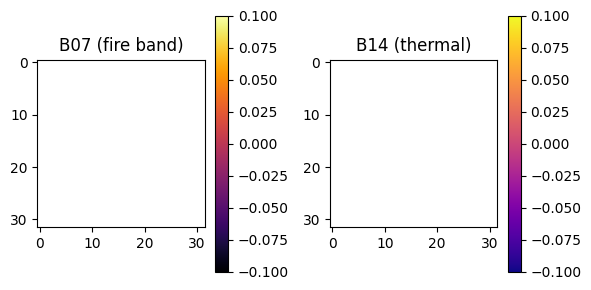

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(X[-1,:,:,0], cmap="inferno")
plt.title("B07 (fire band)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(X[-1,:,:,1], cmap="plasma")
plt.title("B14 (thermal)")
plt.colorbar()
plt.tight_layout()


In [ ]:
import numpy as np

b07 = X[-1,:,:,0]
b14 = X[-1,:,:,1]

print("B07 min/max:", float(np.nanmin(b07)), float(np.nanmax(b07)))
print("B14 min/max:", float(np.nanmin(b14)), float(np.nanmax(b14)))
print("B07 unique (sample):", np.unique(b07[~np.isnan(b07)][:100]).shape[0])
print("B14 unique (sample):", np.unique(b14[~np.isnan(b14)][:100]).shape[0])
print("Any NaNs?", np.isnan(X).any())


B07 min/max: nan nan
B14 min/max: nan nan
B07 unique (sample): 0
B14 unique (sample): 0
Any NaNs? True


/tmp/ipython-input-2126042206.py:6: RuntimeWarning: All-NaN slice encountered
  print("B07 min/max:", float(np.nanmin(b07)), float(np.nanmax(b07)))
/tmp/ipython-input-2126042206.py:7: RuntimeWarning: All-NaN slice encountered
  print("B14 min/max:", float(np.nanmin(b14)), float(np.nanmax(b14)))


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


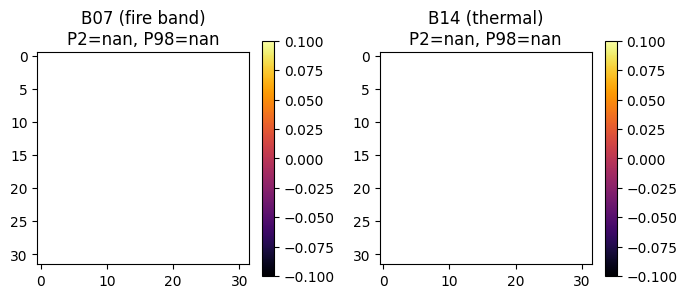

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_band(arr, title):
    lo, hi = np.nanpercentile(arr, [2, 98])
    plt.imshow(arr, vmin=lo, vmax=hi, cmap="inferno")
    plt.title(f"{title}\nP2={lo:.3f}, P98={hi:.3f}")
    plt.colorbar()

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); show_band(X[-1,:,:,0], "B07 (fire band)")
plt.subplot(1,2,2); show_band(X[-1,:,:,1], "B14 (thermal)")
plt.tight_layout()


In [ ]:
print("B07 all-constant?", np.nanstd(X[-1,:,:,0]) == 0)
print("B14 all-constant?", np.nanstd(X[-1,:,:,1]) == 0)
print("B07 std:", float(np.nanstd(X[-1,:,:,0])))
print("B14 std:", float(np.nanstd(X[-1,:,:,1])))


B07 all-constant? False
B14 all-constant? False
B07 std: nan
B14 std: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:
import numpy as np

def extract_patch_from_da(da, lat, lon, patch=32):
    """
    Extract patch×patch window centered at (lat, lon) from a Satpy DataArray.
    Uses the AreaDefinition in da.attrs['area'] for correct geolocation.

    Returns:
      patch_arr: (patch, patch) float32 numpy array
      info: dict with center indices and bounds
    """
    area = da.attrs.get("area", None)
    if area is None:
        raise ValueError("No 'area' in da.attrs. Can't geolocate.")

    # pyresample AreaDefinition expects lon,lat (note the order)
    try:
        r, c = area.get_array_indices_from_lonlat(lon, lat)  # (row, col)
    except AttributeError:
        # fallback if only coordinates method exists
        rr, cc = area.get_array_coordinates_from_lonlat(lon, lat)
        r, c = int(round(rr)), int(round(cc))

    h = patch // 2
    y0, y1 = r - h, r + h
    x0, x1 = c - h, c + h

    # bounds check
    H, W = da.shape[-2], da.shape[-1]  # (y,x)
    if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
        raise ValueError(f"Patch out of bounds: y[{y0}:{y1}] x[{x0}:{x1}] for shape {(H,W)}")

    # IMPORTANT: compute slice (dask -> numpy)
    patch_da = da.isel(y=slice(y0, y1), x=slice(x0, x1)).compute()
    patch_arr = patch_da.values.astype(np.float32)

    info = {"row": int(r), "col": int(c), "y0": int(y0), "y1": int(y1), "x0": int(x0), "x1": int(x1)}
    return patch_arr, info


In [ ]:
# pick one already-downloaded DAT path and band you loaded successfully
da = load_band_da(dat_path, band="B07")  # or B14

patch_arr, info = extract_patch_from_da(da, centroid_lat, centroid_lon, patch=32)
print("info:", info)
print("patch nan%:", float(np.isnan(patch_arr).mean())*100)
print("min/max:", float(np.nanmin(patch_arr)), float(np.nanmax(patch_arr)))


KeyError: "No dataset matching 'DataQuery(name='B07')' found"

In [ ]:
def default_res_for_band(band: str) -> str:
    # IR bands (including B07, B14) are typically 2km in FLDK => R20
    if band in ["B07", "B14", "B11", "B12", "B13", "B15", "B16", "B10", "B09", "B08"]:
        return "R20"
    # Visible/NIR often have higher res variants (R10, R05), depending on band
    return "R10"


In [ ]:
def get_key_for_time(dt, band="B07", res=None):
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    if res is None:
        res = default_res_for_band(band)
    k = pick_key(keys, band=band, res=res)
    return bucket, k


In [ ]:
bucket, key = get_key_for_time(dt, band="B07", res=None)
print("Picked key:", key)
assert key is not None, "No key found for this time/band"
assert "_B07_" in key, f"Wrong file downloaded (expected B07): {key}"


Picked key: AHI-L1b-FLDK/2024/03/24/0400/HS_H09_20240324_0400_B07_FLDK_R20_S0110.DAT.bz2


In [ ]:
# pick a time you KNOW exists (you already succeeded at 2024-03-24 04:00)
dt = pd.Timestamp("2024-03-24 04:00:00").to_pydatetime()

# --- download B07 ---
bucket, key = get_key_for_time(dt, band="B07", res=None)
print("B07 key:", key)
assert key and "_B07_" in key

dat_path_b07 = download_and_decompress(bucket, key)
da_b07 = load_band_da(dat_path_b07, band="B07")
print("Loaded B07:", da_b07.shape, da_b07.dtype)

# --- download B14 ---
bucket, key = get_key_for_time(dt, band="B14", res=None)
print("B14 key:", key)
assert key and "_B14_" in key

dat_path_b14 = download_and_decompress(bucket, key)
da_b14 = load_band_da(dat_path_b14, band="B14")
print("Loaded B14:", da_b14.shape, da_b14.dtype)


B07 key: AHI-L1b-FLDK/2024/03/24/0400/HS_H09_20240324_0400_B07_FLDK_R20_S0110.DAT.bz2
Loaded B07: (5500, 5500) float64
B14 key: AHI-L1b-FLDK/2024/03/24/0400/HS_H09_20240324_0400_B14_FLDK_R20_S0110.DAT.bz2
Loaded B14: (5500, 5500) float64


In [ ]:
import os, bz2, shutil
import numpy as np
import pandas as pd
from datetime import timedelta
from satpy import Scene

# -------------------------
# 1) Key selection helpers
# -------------------------
def default_res_for_band(band: str) -> str:
    # IR bands (incl B07, B14) are 2km => R20 in FLDK
    if band in ["B07", "B14", "B11", "B12", "B13", "B15", "B16", "B10", "B09", "B08"]:
        return "R20"
    # VIS/NIR often available as R10/R05
    return "R10"

def build_prefix(dt):
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def pick_key(keys, band="B07", res="R20"):
    # keys are full S3 keys under the prefix
    band_tag = f"_{band}_"
    res_tag  = f"_{res}_"
    for k in keys:
        if (band_tag in k) and (res_tag in k) and k.endswith(".DAT.bz2"):
            return k
    return None

# NOTE: you already have these from earlier:
# - bucket_for_dt(dt)  -> returns bucket name (noaa-himawari9 or noaa-himawari8 etc)
# - list_keys(bucket, prefix) -> list of keys under prefix
# - round_down_10min(dt) -> floor to 10-min
# - s3 boto3 client initialised

# -------------------------
# 2) Download + load band
# -------------------------
def download_and_decompress(bucket, key, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    if not os.path.exists(bz2_path):
        s3.download_file(bucket, key, bz2_path)

    dat_path = bz2_path[:-4]  # remove ".bz2"
    if not os.path.exists(dat_path):
        with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    return dat_path

def load_band_da(dat_path, band="B07"):
    scn = Scene(filenames=[dat_path], reader="ahi_hsd")
    scn.load([band])
    return scn[band]

def get_key_for_time(dt, band="B07", res=None):
    if res is None:
        res = default_res_for_band(band)
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    k = pick_key(keys, band=band, res=res)
    return bucket, k, res

# -------------------------
# 3) Correct geolocated patch extraction
# -------------------------
def extract_patch_from_da(da, lat, lon, patch=32):
    area = da.attrs.get("area", None)
    if area is None:
        raise ValueError("No 'area' in da.attrs. Can't geolocate.")
    r, c = area.get_array_indices_from_lonlat(lon, lat)  # (row, col)

    h = patch // 2
    y0, y1 = int(r - h), int(r + h)
    x0, x1 = int(c - h), int(c + h)

    H, W = da.shape[-2], da.shape[-1]
    if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
        raise ValueError(f"Patch out of bounds: y[{y0}:{y1}] x[{x0}:{x1}] for shape {(H,W)}")

    patch_da = da.isel(y=slice(y0, y1), x=slice(x0, x1)).compute()
    patch_arr = patch_da.values.astype(np.float32)

    info = {"row": int(r), "col": int(c), "y0": y0, "y1": y1, "x0": x0, "x1": x1}
    return patch_arr, info

# -------------------------
# 4) Build (T, P, P, C) tensor
# -------------------------
def build_event_tensor_multiband(t0, lat, lon, bands=("B07", "B14"), patch=32, T=12):
    """
    Builds tensor ending at t0, stepping back every 10 minutes.
    Returns:
      X: (T_kept, patch, patch, C)
      kept_times: list of datetimes
    """
    t0r = round_down_10min(t0)
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]  # oldest -> newest

    X_list = []
    kept_times = []
    last_info = None

    for dt in times:
        band_patches = []
        ok = True

        for band in bands:
            bucket, key, res = get_key_for_time(dt, band=band, res=None)
            if key is None:
                ok = False
                break

            dat_path = download_and_decompress(bucket, key)
            da = load_band_da(dat_path, band=band)

            patch_arr, info = extract_patch_from_da(da, lat, lon, patch=patch)
            band_patches.append(patch_arr)
            last_info = info

        if not ok:
            print("Missing:", dt, "(skip)")
            continue

        # stack channels last -> (patch, patch, C)
        X_t = np.stack(band_patches, axis=-1).astype(np.float32)
        X_list.append(X_t)
        kept_times.append(dt)

    if not X_list:
        raise RuntimeError("No timesteps loaded. Increase search window or confirm keys exist.")

    X = np.stack(X_list, axis=0)  # (T', patch, patch, C)
    return X, kept_times, last_info


In [ ]:
from datetime import datetime

t0_example = datetime(2024, 3, 24, 4, 7)   # your pilot t0
X, kept_times, info = build_event_tensor_multiband(
    t0=t0_example,
    lat=centroid_lat,
    lon=centroid_lon,
    bands=("B07","B14"),
    patch=32,
    T=12
)

print("X:", X.shape, X.dtype)
print("Times:", kept_times[0], "->", kept_times[-1])
print("Patch center indices:", info)
print("NaN fraction:", float(np.isnan(X).mean())*100, "%")


Missing: 2024-03-24 02:40:00 (skip)
X: (11, 32, 32, 2) float32
Times: 2024-03-24 02:10:00 -> 2024-03-24 04:00:00
Patch center indices: {'row': 2866, 'col': 4607, 'y0': 2850, 'y1': 2882, 'x0': 4591, 'x1': 4623}
NaN fraction: 100.0 %


In [ ]:
out_dir = "/content/pilot_h9/event_test_multiband"
os.makedirs(out_dir, exist_ok=True)
np.save(os.path.join(out_dir, "X.npy"), X)
with open(os.path.join(out_dir, "times.txt"), "w") as f:
    for t in kept_times:
        f.write(t.isoformat() + "\n")
print("Saved to:", out_dir)


Saved to: /content/pilot_h9/event_test_multiband


In [ ]:
dt = kept_times[-1]  # 2024-03-24 04:00:00

# Load full disk arrays (no patch yet)
bucket, key_b07, _ = get_key_for_time(dt, band="B07", res=None)
bucket, key_b14, _ = get_key_for_time(dt, band="B14", res=None)

dat_b07 = download_and_decompress(bucket, key_b07)
dat_b14 = download_and_decompress(bucket, key_b14)

da_b07 = load_band_da(dat_b07, band="B07")
da_b14 = load_band_da(dat_b14, band="B14")

import numpy as np
print("B07 global NaN%:", float(np.isnan(da_b07.values).mean())*100)
print("B14 global NaN%:", float(np.isnan(da_b14.values).mean())*100)
print("B07 min/max:", float(np.nanmin(da_b07.values)), float(np.nanmax(da_b07.values)))
print("B14 min/max:", float(np.nanmin(da_b14.values)), float(np.nanmax(da_b14.values)))


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 global NaN%: 96.38102479338842
B14 global NaN%: 96.38102479338842
B07 min/max: 247.37312881282915 333.49490951373076
B14 min/max: 209.84372132611153 290.5551344378555


In [ ]:
patch_b07, info_b07 = extract_patch_from_da(da_b07, centroid_lat, centroid_lon, patch=32)
patch_b14, info_b14 = extract_patch_from_da(da_b14, centroid_lat, centroid_lon, patch=32)

print("Patch idx:", info_b07)
print("B07 patch NaN%:", float(np.isnan(patch_b07).mean())*100, "min/max:", np.nanmin(patch_b07), np.nanmax(patch_b07))
print("B14 patch NaN%:", float(np.isnan(patch_b14).mean())*100, "min/max:", np.nanmin(patch_b14), np.nanmax(patch_b14))


Patch idx: {'row': 2866, 'col': 4607, 'y0': 2850, 'y1': 2882, 'x0': 4591, 'x1': 4623}
B07 patch NaN%: 100.0 min/max: nan nan
B14 patch NaN%: 100.0 min/max: nan nan


/tmp/ipython-input-1965417380.py:5: RuntimeWarning: All-NaN slice encountered
  print("B07 patch NaN%:", float(np.isnan(patch_b07).mean())*100, "min/max:", np.nanmin(patch_b07), np.nanmax(patch_b07))
/tmp/ipython-input-1965417380.py:6: RuntimeWarning: All-NaN slice encountered
  print("B14 patch NaN%:", float(np.isnan(patch_b14).mean())*100, "min/max:", np.nanmin(patch_b14), np.nanmax(patch_b14))


In [ ]:
import numpy as np

print("B07 calibration:", da_b07.attrs.get("calibration"))
print("B14 calibration:", da_b14.attrs.get("calibration"))

b07 = da_b07.values
b14 = da_b14.values

print("B07 global NaN%:", float(np.isnan(b07).mean())*100)
print("B14 global NaN%:", float(np.isnan(b14).mean())*100)

print("B07 global min/max:", float(np.nanmin(b07)), float(np.nanmax(b07)))
print("B14 global min/max:", float(np.nanmin(b14)), float(np.nanmax(b14)))


B07 calibration: brightness_temperature
B14 calibration: brightness_temperature


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 global NaN%: 96.38102479338842
B14 global NaN%: 96.38102479338842
B07 global min/max: 247.37312881282915 333.49490951373076
B14 global min/max: 209.84372132611153 290.5551344378555


In [ ]:
from satpy import Scene
from satpy.dataset import DataQuery
import numpy as np

def load_da(dat_path, band, calibration=None):
    scn = Scene(filenames=[dat_path], reader="ahi_hsd")
    if calibration is None:
        scn.load([band])
        return scn[band]
    q = DataQuery(name=band, calibration=calibration)
    scn.load([q])
    return scn[q]

# reload one timestamp files you already downloaded/decompressed:
da_b07 = load_da(dat_b07, "B07", calibration="radiance")  # key fix
da_b14 = load_da(dat_b14, "B14", calibration="brightness_temperature")

print("B07 cal:", da_b07.attrs.get("calibration"), "NaN%:", float(np.isnan(da_b07.values).mean())*100)
print("B14 cal:", da_b14.attrs.get("calibration"), "NaN%:", float(np.isnan(da_b14.values).mean())*100)


B07 cal: radiance NaN%: 96.38102479338842


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 cal: brightness_temperature NaN%: 96.38102479338842


In [ ]:
def extract_patch_with_jitter(da, lat, lon, patch=32, max_jitter_px=50, step=5):
    """
    Try centroid pixel first; if patch is all-NaN, try small pixel offsets in a spiral-ish grid.
    Returns: patch_arr, info_dict
    """
    area = da.attrs["area"]

    # base index from lon/lat (lon first!)
    r0, c0 = area.get_array_indices_from_lonlat(lon, lat)
    r0, c0 = int(r0), int(c0)

    H, W = da.shape
    half = patch // 2

    def grab(r, c):
        y0, y1 = r - half, r + half
        x0, x1 = c - half, c + half
        if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
            return None, None
        arr = da.values[y0:y1, x0:x1]
        info = {"row": r, "col": c, "y0": y0, "y1": y1, "x0": x0, "x1": x1}
        return arr, info

    # try center
    arr, info = grab(r0, c0)
    if arr is not None and not np.isnan(arr).all():
        return arr, info

    # jitter search
    for dy in range(-max_jitter_px, max_jitter_px + 1, step):
        for dx in range(-max_jitter_px, max_jitter_px + 1, step):
            arr, info = grab(r0 + dy, c0 + dx)
            if arr is None:
                continue
            if not np.isnan(arr).all():
                info["jitter_dy"] = dy
                info["jitter_dx"] = dx
                return arr, info

    # if still nothing
    return arr, info  # will be all-NaN


In [ ]:
p07, i07 = extract_patch_with_jitter(da_b07, centroid_lat, centroid_lon, patch=32)
p14, i14 = extract_patch_with_jitter(da_b14, centroid_lat, centroid_lon, patch=32)

print("B07 patch NaN%:", float(np.isnan(p07).mean())*100, "info:", i07)
print("B14 patch NaN%:", float(np.isnan(p14).mean())*100, "info:", i14)


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 patch NaN%: 100.0 info: {'row': 2916, 'col': 4657, 'y0': 2900, 'y1': 2932, 'x0': 4641, 'x1': 4673}
B14 patch NaN%: 100.0 info: {'row': 2916, 'col': 4657, 'y0': 2900, 'y1': 2932, 'x0': 4641, 'x1': 4673}


In [ ]:
import numpy as np

area = da_b07.attrs["area"]

# 1) what does satpy think the "valid" earth area is?
print("Area:", area)

# 2) convert your target lat/lon to indices (lon first!)
r, c = area.get_array_indices_from_lonlat(float(centroid_lon), float(centroid_lat))
r, c = int(r), int(c)
print("Target row/col:", r, c, "shape:", da_b07.shape)

# 3) convert back to lat/lon from that pixel (sanity)
lon_grid, lat_grid = area.get_lonlats()
print("Back-converted lat/lon:", float(lat_grid[r, c]), float(lon_grid[r, c]))
print("Target lat/lon:", float(centroid_lat), float(centroid_lon))

# 4) is that pixel valid or masked?
val = da_b07.values[r, c]
print("Pixel value:", val, "isNaN:", bool(np.isnan(val)))


Area: Area ID: FLDK
Description: AHI FLDK area
Projection ID: geosh9
Projection: {'a': '6378137', 'h': '35785863', 'lon_0': '140.7', 'no_defs': 'None', 'proj': 'geos', 'rf': '298.257024882273', 'type': 'crs', 'units': 'm', 'x_0': '0', 'y_0': '0'}
Number of columns: 5500
Number of rows: 5500
Area extent: (np.float64(-5499999.9012), np.float64(-5499999.9012), np.float64(5499999.9012), np.float64(5499999.9012))
Target row/col: 2866 4607 shape: (5500, 5500)
Back-converted lat/lon: -2.1967125710877333 178.03001351305215
Target lat/lon: -37.539197 143.44602
Pixel value: nan isNaN: True


In [ ]:
import numpy as np

arr = da_b07.values
valid = np.isfinite(arr)
print("Valid pixels:", int(valid.sum()), "out of", arr.size)
print("Valid %:", float(valid.mean())*100)

# find one valid pixel location (if any)
idx = np.argwhere(valid)
print("First valid pixel (row,col):", idx[0] if len(idx) else None)


Valid pixels: 1094740 out of 30250000
Valid %: 3.6189752066115703
First valid pixel (row,col): [  42 2703]


In [ ]:
import numpy as np

area = da_b07.attrs["area"]

lon = float(centroid_lon)
lat = float(centroid_lat)

r, c = area.get_array_indices_from_lonlat(lon, lat)   # ✅ lon, lat
r, c = int(r), int(c)

lon_grid, lat_grid = area.get_lonlats()

print("Target lat/lon:", lat, lon)
print("Row/col:", r, c, "shape:", da_b07.shape)
print("Back lat/lon:", float(lat_grid[r, c]), float(lon_grid[r, c]))
print("Pixel isNaN:", bool(np.isnan(da_b07.values[r, c])))


Target lat/lon: -37.539197 143.44602
Row/col: 2866 4607 shape: (5500, 5500)
Back lat/lon: -2.1967125710877333 178.03001351305215
Pixel isNaN: True


In [ ]:
import numpy as np
from pyproj import CRS, Transformer

def rowcol_from_lonlat(area, lon, lat):
    # Build transformer: lon/lat (EPSG:4326) -> Himawari geos projection
    crs_geos = CRS.from_dict(area.proj_dict)
    fwd = Transformer.from_crs("EPSG:4326", crs_geos, always_xy=True)
    inv = Transformer.from_crs(crs_geos, "EPSG:4326", always_xy=True)

    # Project lon/lat -> x/y (meters)
    x, y = fwd.transform(lon, lat)

    x0, y0, x1, y1 = area.area_extent  # (xmin, ymin, xmax, ymax)
    H = area.height
    W = area.width

    # Convert projected meters -> pixel indices
    col = int(np.floor((x - x0) / (x1 - x0) * W))
    row = int(np.floor((y1 - y) / (y1 - y0) * H))  # note y axis flipped

    # Clip to bounds
    row = max(0, min(H - 1, row))
    col = max(0, min(W - 1, col))

    # Back-convert for verification
    xb = x0 + (col + 0.5) * (x1 - x0) / W
    yb = y1 - (row + 0.5) * (y1 - y0) / H
    lon_b, lat_b = inv.transform(xb, yb)

    return row, col, (lat_b, lon_b), (x, y)

# --- test with your centroid ---
area = da_b07.attrs["area"]
lat = float(centroid_lat)
lon = float(centroid_lon)

row, col, (lat_b, lon_b), (x, y) = rowcol_from_lonlat(area, lon, lat)

print("Target lat/lon:", lat, lon)
print("Projected x/y (m):", x, y)
print("Row/col:", row, col, "shape:", da_b07.shape)
print("Back lat/lon:", lat_b, lon_b)

val = da_b07.values[row, col]
print("Pixel value:", val, "isNaN:", bool(np.isnan(val)))


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Target lat/lon: -37.539197 143.44602
Projected x/y (m): 233963.42209186938 -3714028.8938403497
Row/col: 4607 2866 shape: (5500, 5500)
Back lat/lon: -37.551701615163275 143.43521949424522
Pixel value: nan isNaN: True


In [ ]:
import numpy as np
from pyresample import geometry
from pyproj import Geod

# Rough VIC bounds (you can tighten later)
VIC_LAT_MIN, VIC_LAT_MAX = -39.3, -33.9
VIC_LON_MIN, VIC_LON_MAX = 140.95, 150.10

RES_DEG = 0.02  # ~2 km

lats = np.arange(VIC_LAT_MAX, VIC_LAT_MIN, -RES_DEG)  # north -> south
lons = np.arange(VIC_LON_MIN, VIC_LON_MAX,  RES_DEG)

vic_area = geometry.AreaDefinition(
    area_id="vic_latlon",
    description="Victoria lat/lon grid",
    proj_id="latlon",
    projection={"proj": "latlong", "datum": "WGS84"},
    width=len(lons),
    height=len(lats),
    area_extent=(lons.min(), lats.min(), lons.max(), lats.max()),
)

print("VIC grid:", vic_area.width, "x", vic_area.height)


VIC grid: 458 x 270


In [ ]:
import numpy as np
from pyresample import geometry
from pyresample.kd_tree import resample_nearest

# --- Build VIC lon/lat swath grid (2D) ---
VIC_LAT_MIN, VIC_LAT_MAX = -39.3, -33.9
VIC_LON_MIN, VIC_LON_MAX = 140.95, 150.10
RES_DEG = 0.02  # ~2 km

lats_1d = np.arange(VIC_LAT_MAX, VIC_LAT_MIN, -RES_DEG)  # north -> south
lons_1d = np.arange(VIC_LON_MIN, VIC_LON_MAX,  RES_DEG)

lon2d, lat2d = np.meshgrid(lons_1d, lats_1d)
vic_swath = geometry.SwathDefinition(lons=lon2d, lats=lat2d)

print("VIC grid:", lon2d.shape)

def resample_da_to_vic_swath(da, radius_m=15000):
    # 1) source area from Satpy
    src_area = da.attrs["area"]

    # 2) IMPORTANT: force compute to numpy (avoid dask/resample weirdness)
    src_data = da.compute().values.astype(np.float32)

    # 3) nearest-neighbour resample
    out = resample_nearest(
        src_area, src_data,
        vic_swath,
        radius_of_influence=radius_m,
        fill_value=np.nan
    )
    return out

b07_vic = resample_da_to_vic_swath(da_b07, radius_m=60000)
b14_vic = resample_da_to_vic_swath(da_b14, radius_m=60000)

print("B07 VIC NaN%:", np.isnan(b07_vic).mean()*100, "min/max:", np.nanmin(b07_vic), np.nanmax(b07_vic))
print("B14 VIC NaN%:", np.isnan(b14_vic).mean()*100, "min/max:", np.nanmin(b14_vic), np.nanmax(b14_vic))


VIC grid: (270, 458)
B07 VIC NaN%: 100.0 min/max: nan nan
B14 VIC NaN%: 100.0 min/max: nan nan


/tmp/ipython-input-3328258221.py:37: RuntimeWarning: All-NaN slice encountered
  print("B07 VIC NaN%:", np.isnan(b07_vic).mean()*100, "min/max:", np.nanmin(b07_vic), np.nanmax(b07_vic))
/tmp/ipython-input-3328258221.py:38: RuntimeWarning: All-NaN slice encountered
  print("B14 VIC NaN%:", np.isnan(b14_vic).mean()*100, "min/max:", np.nanmin(b14_vic), np.nanmax(b14_vic))


In [ ]:
# ============================
# STEP 4 (FULL READY-TO-PASTE)
# Segment-aware Himawari FLDK extraction -> patches -> tensor
# ============================

!pip -q install boto3 satpy pyproj dask[array] xarray

import os, re, bz2, shutil
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import boto3
from botocore import UNSIGNED
from botocore.client import Config

from satpy import Scene
from pyproj import Proj

# ---------- 0) S3 client (public/anonymous) ----------
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

# ---------- 1) Time helpers ----------
def round_down_10min(dt: datetime) -> datetime:
    return dt.replace(minute=(dt.minute // 10) * 10, second=0, microsecond=0)

def build_prefix(dt: datetime) -> str:
    # Himawari FLDK structure: AHI-L1b-FLDK/YYYY/MM/DD/HHMM/
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def bucket_for_dt(dt: datetime) -> str:
    # NOAA has Himawari-8 and Himawari-9 buckets.
    # Your earlier probe showed 2024 exists on Himawari-9.
    # If you later need older years (eg 2019), we can switch to himawari8.
    if dt.year >= 2022:
        return "noaa-himawari9"
    else:
        return "noaa-himawari8"

# ---------- 2) S3 listing ----------
def list_keys(bucket: str, prefix: str, max_keys: int = 2000):
    keys = []
    token = None
    while True:
        kwargs = dict(Bucket=bucket, Prefix=prefix, MaxKeys=max_keys)
        if token:
            kwargs["ContinuationToken"] = token
        resp = s3.list_objects_v2(**kwargs)
        for obj in resp.get("Contents", []):
            keys.append(obj["Key"])
        if not resp.get("IsTruncated"):
            break
        token = resp.get("NextContinuationToken")
        if len(keys) >= max_keys:
            break
    return keys

# ---------- 3) IMPORTANT FIX: collect ALL segment keys ----------
def pick_all_segment_keys(keys, band="B07", res="R20"):
    """
    Example key ending: ..._B07_FLDK_R20_S0110.DAT.bz2
    Collect every segment Sxxxx for this band/res at this timestamp.
    """
    pat = re.compile(rf"{band}_FLDK_{res}_S\d{{4}}\.DAT\.bz2$")
    segs = [k for k in keys if pat.search(k)]
    segs.sort()
    return segs

# ---------- 4) Download + decompress many ----------
def download_and_decompress_many(bucket, keys, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    dat_paths = []
    for key in keys:
        bz2_path = os.path.join(out_dir, os.path.basename(key))
        dat_path = bz2_path[:-4]  # remove .bz2 -> .DAT

        # download+decompress only if not already done
        if not os.path.exists(dat_path):
            s3.download_file(bucket, key, bz2_path)
            with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

        dat_paths.append(dat_path)
    return dat_paths

# ---------- 5) Load band from ALL segments ----------
def load_band_from_segments(dat_paths, band):
    scn = Scene(filenames=dat_paths, reader="ahi_hsd")
    scn.load([band])
    return scn[band]

# ---------- 6) Lat/Lon -> pixel mapping + patch extraction ----------
def get_area_params(da):
    """
    Extract geostationary projection + grid parameters from Satpy DataArray.
    """
    area = da.attrs["area"]
    proj = area.proj_dict  # geos projection params
    width, height = area.width, area.height
    x_min, y_min, x_max, y_max = area.area_extent  # meters
    return proj, width, height, x_min, y_min, x_max, y_max

def latlon_to_rowcol(lat, lon, proj, width, height, x_min, y_min, x_max, y_max):
    """
    Convert lat/lon -> projected x/y -> row/col for FLDK grid.
    """
    p = Proj(proj)  # geos projection
    x, y = p(lon, lat)  # meters

    # map x in [x_min,x_max] -> col in [0,width-1]
    # map y in [y_max,y_min] -> row in [0,height-1] (note y decreases downward)
    col = int(round((x - x_min) / (x_max - x_min) * (width - 1)))
    row = int(round((y_max - y) / (y_max - y_min) * (height - 1)))

    # clamp
    col = max(0, min(width - 1, col))
    row = max(0, min(height - 1, row))
    return row, col

def extract_patch_from_da(da, lat, lon, patch=32):
    """
    Returns patch_arr (patch, patch) as float32 and info dict.
    """
    proj, width, height, x_min, y_min, x_max, y_max = get_area_params(da)
    row, col = latlon_to_rowcol(lat, lon, proj, width, height, x_min, y_min, x_max, y_max)

    half = patch // 2
    y0, y1 = row - half, row + half
    x0, x1 = col - half, col + half

    # bounds
    y0c, y1c = max(0, y0), min(height, y1)
    x0c, x1c = max(0, x0), min(width, x1)

    # pull region (dask/xarray)
    sub = da.isel(y=slice(y0c, y1c), x=slice(x0c, x1c)).values
    sub = np.array(sub, dtype=np.float32)

    # pad if clipped by edge
    out = np.full((patch, patch), np.nan, dtype=np.float32)
    oy0 = y0c - y0
    ox0 = x0c - x0
    out[oy0:oy0 + sub.shape[0], ox0:ox0 + sub.shape[1]] = sub

    info = {"row": row, "col": col, "y0": y0, "y1": y1, "x0": x0, "x1": x1}
    return out, info

# ---------- 7) Get segment keys for a time ----------
def get_segment_keys_for_time(dt, band="B07", res="R20"):
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    seg_keys = pick_all_segment_keys(keys, band=band, res=res)
    return bucket, prefix, seg_keys

# ---------- 8) Build multi-band tensor ----------
def build_event_tensor_multiband(
    t0,
    lat,
    lon,
    bands=("B07", "B14"),
    res="R20",
    patch=32,
    T=12,
    out_dir="/content/himawari_pilot_raw"
):
    t0r = round_down_10min(t0)
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]

    X_list = []
    kept_times = []
    last_patch_info = None

    for dt in times:
        band_arrays = []
        ok = True

        for band in bands:
            bucket, prefix, seg_keys = get_segment_keys_for_time(dt, band=band, res=res)

            if not seg_keys:
                print(f"Missing: {dt} {band} (skip)")
                ok = False
                break

            dat_paths = download_and_decompress_many(bucket, seg_keys, out_dir=out_dir)
            da = load_band_from_segments(dat_paths, band)
            patch_arr, info = extract_patch_from_da(da, lat, lon, patch=patch)
            band_arrays.append(patch_arr)
            last_patch_info = info

        if not ok:
            continue

        X_t = np.stack(band_arrays, axis=-1)   # (patch, patch, C)
        X_list.append(X_t)
        kept_times.append(dt)

    if not X_list:
        raise RuntimeError("No timesteps loaded. Try different date or increase search window.")

    X = np.stack(X_list, axis=0)  # (T', patch, patch, C)
    return X, kept_times, last_patch_info

# ============================
# 9) QUICK TEST (edit these 3)
# ============================
centroid_lat = -37.539197
centroid_lon = 143.44602
t0_example = datetime(2024, 3, 24, 4, 7)

X, kept_times, patch_info = build_event_tensor_multiband(
    t0=t0_example,
    lat=centroid_lat,
    lon=centroid_lon,
    bands=("B07", "B14"),
    res="R20",
    patch=32,
    T=12
)

print("X:", X.shape, X.dtype)
print("Times:", kept_times[0], "->", kept_times[-1])
print("Patch idx:", patch_info)
print("NaN fraction %:", np.isnan(X).mean()*100)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.8/484.8 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.3/708.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.6/82.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/pyproj/crs

Missing: 2024-03-24 02:40:00 B07 (skip)


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/pyproj/crs

X: (11, 32, 32, 2) float32
Times: 2024-03-24 02:10:00 -> 2024-03-24 04:00:00
Patch idx: {'row': 4606, 'col': 2866, 'y0': 4590, 'y1': 4622, 'x0': 2850, 'x1': 2882}
NaN fraction %: 0.0


In [ ]:
from satpy import Scene

# Path to ONE decompressed Himawari DAT file
dat_path = "/content/himawari_pilot_raw/HS_H09_20240324_0400_B07_FLDK_R20_S0110.DAT"

# Create Scene
scn = Scene(filenames=[dat_path], reader="ahi_hsd")

# Ask Satpy what it can load
print("Available datasets:")
print(sorted(scn.available_dataset_names()))

# OPTIONAL: load everything to inspect metadata
scn.load(scn.available_dataset_names())

# Inspect each dataset
for name in sorted(scn.available_dataset_names()):
    da = scn[name]
    print(
        name,
        "| calibration:", da.attrs.get("calibration"),
        "| shape:", da.shape
    )


Available datasets:
['B07']
B07 | calibration: brightness_temperature | shape: (5500, 5500)


In [ ]:
from satpy import Scene

b07_path = "/content/himawari_pilot_raw/HS_H09_20240324_0400_B07_FLDK_R20_S0110.DAT"
b14_path = "/content/himawari_pilot_raw/HS_H09_20240324_0400_B14_FLDK_R20_S0110.DAT"

scn = Scene(filenames=[b07_path, b14_path], reader="ahi_hsd")

print("Available datasets:")
print(sorted(scn.available_dataset_names()))

# Load both
scn.load(["B07", "B14"])

for name in ["B07", "B14"]:
    da = scn[name]
    print(name, "| calibration:", da.attrs.get("calibration"), "| shape:", da.shape)


Available datasets:
['B07', 'B14']
B07 | calibration: brightness_temperature | shape: (5500, 5500)
B14 | calibration: brightness_temperature | shape: (5500, 5500)


In [ ]:
!ls -lh /content/himawari_pilot_raw | head -n 30

total 1.8G
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0110.DAT
-rw-r--r-- 1 root root 1.2M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0110.DAT.bz2
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0210.DAT
-rw-r--r-- 1 root root 2.1M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0210.DAT.bz2
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0310.DAT
-rw-r--r-- 1 root root 2.5M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0310.DAT.bz2
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0410.DAT
-rw-r--r-- 1 root root 2.7M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0410.DAT.bz2
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0510.DAT
-rw-r--r-- 1 root root 2.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0510.DAT.bz2
-rw-r--r-- 1 root root 5.8M Jan 23 04:58 HS_H09_20240324_0210_B07_FLDK_R20_S0610.DAT
-rw-r--r-- 1 root root 2.8M Jan 23

In [ ]:
da_b07 = scn["B07"]
da_b14 = scn["B14"]

patch_b07, idx = extract_patch_from_da(
    da_b07,
    lat=centroid_lat,
    lon=centroid_lon,
    patch=32
)

patch_b14, _ = extract_patch_from_da(
    da_b14,
    lat=centroid_lat,
    lon=centroid_lon,
    patch=32
)

print("Patch idx:", idx)
print("B07 NaN%:", float(np.isnan(patch_b07).mean()) * 100)
print("B14 NaN%:", float(np.isnan(patch_b14).mean()) * 100)


Patch idx: {'row': 4606, 'col': 2866, 'y0': 4590, 'y1': 4622, 'x0': 2850, 'x1': 2882}
B07 NaN%: 100.0
B14 NaN%: 100.0


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [ ]:
import numpy as np
import pyproj

def _lonlat_to_rowcol_from_area(area, lat, lon):
    """
    Convert lat/lon -> (row, col) for a pyresample AreaDefinition (Himawari FLDK).
    Uses area_extent + proj_dict (meters) and correct y-axis direction.
    """
    # area.proj_dict is the projection used by the data grid (geos)
    proj_crs = pyproj.CRS.from_dict(area.proj_dict)
    wgs84 = pyproj.CRS.from_epsg(4326)
    tfm = pyproj.Transformer.from_crs(wgs84, proj_crs, always_xy=True)

    x, y = tfm.transform(lon, lat)  # meters in geos projection

    llx, lly, urx, ury = area.area_extent  # (xmin, ymin, xmax, ymax)
    height, width = area.shape             # (rows, cols)

    px = (urx - llx) / width               # meters per pixel in x
    py = (ury - lly) / height              # meters per pixel in y

    # IMPORTANT:
    # col increases left->right:   llx -> urx
    # row increases top->bottom:   ury -> lly  (so we use ury - y)
    col = int(np.round((x - llx) / px))
    row = int(np.round((ury - y) / py))

    return row, col, (x, y)

def extract_patch_from_da_himawari(da, lat, lon, patch=32, prefer_valid=True):
    """
    Robust patch extractor for Himawari AHI FLDK satpy DataArray.

    Returns:
      patch_arr: (patch, patch) float32
      info: dict with row/col and bounds used

    If prefer_valid=True and the center pixel is NaN, it searches for a nearby valid pixel
    (within expanding radius) and recenters the patch there.
    """
    assert patch % 2 == 0, "patch must be even (e.g., 32)"
    area = da.attrs.get("area", None)
    if area is None:
        raise ValueError("DataArray has no 'area' in attrs. Make sure you loaded via satpy (ahi_hsd).")

    H, W = da.shape
    half = patch // 2

    # Compute row/col from lat/lon
    row, col, (x_m, y_m) = _lonlat_to_rowcol_from_area(area, lat, lon)

    # Clamp to image bounds
    row = int(np.clip(row, 0, H - 1))
    col = int(np.clip(col, 0, W - 1))

    # Helper to cut patch bounds
    def bounds(r, c):
        y0 = max(r - half, 0)
        y1 = min(r + half, H)
        x0 = max(c - half, 0)
        x1 = min(c + half, W)
        return y0, y1, x0, x1

    # Try center pixel, optionally shift to nearest valid
    if prefer_valid:
        # small-to-large search radii (pixels)
        radii = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
        chosen = None

        for rad in radii:
            y0s = max(row - rad, 0); y1s = min(row + rad + 1, H)
            x0s = max(col - rad, 0); x1s = min(col + rad + 1, W)

            # compute a small window only (fast)
            win = da.isel(y=slice(y0s, y1s), x=slice(x0s, x1s)).values
            # win may be dask-backed; force only this small tile
            win = np.asarray(win)

            valid = np.isfinite(win)
            if valid.any():
                # choose nearest valid to center of window
                rr, cc = np.argwhere(valid)[0]
                # better: pick nearest by distance
                coords = np.argwhere(valid)
                center = np.array([row - y0s, col - x0s])
                d2 = np.sum((coords - center) ** 2, axis=1)
                rr, cc = coords[np.argmin(d2)]

                chosen = (int(y0s + rr), int(x0s + cc), rad)
                break

        if chosen is not None:
            row, col, used_rad = chosen
        else:
            used_rad = None
    else:
        used_rad = None

    y0, y1, x0, x1 = bounds(row, col)

    # Extract patch (forces only patch compute)
    patch_arr = da.isel(y=slice(y0, y1), x=slice(x0, x1)).values
    patch_arr = np.asarray(patch_arr, dtype=np.float32)

    # If patch at borders is smaller, pad to (patch, patch)
    if patch_arr.shape != (patch, patch):
        out = np.full((patch, patch), np.nan, dtype=np.float32)
        out[:patch_arr.shape[0], :patch_arr.shape[1]] = patch_arr
        patch_arr = out

    info = {
        "row": row,
        "col": col,
        "y0": y0, "y1": y1,
        "x0": x0, "x1": x1,
        "proj_x_m": float(x_m),
        "proj_y_m": float(y_m),
        "used_search_radius_px": used_rad,
    }
    return patch_arr, info


In [ ]:
da_b07 = scn["B07"]
da_b14 = scn["B14"]

p07, info = extract_patch_from_da_himawari(da_b07, centroid_lat, centroid_lon, patch=32, prefer_valid=True)
p14, _    = extract_patch_from_da_himawari(da_b14, centroid_lat, centroid_lon, patch=32, prefer_valid=True)

print("Patch info:", info)
print("B07 NaN%:", float(np.isnan(p07).mean()) * 100)
print("B14 NaN%:", float(np.isnan(p14).mean()) * 100)
print("B07 min/max:", np.nanmin(p07), np.nanmax(p07))
print("B14 min/max:", np.nanmin(p14), np.nanmax(p14))


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Patch info: {'row': 4607, 'col': 2867, 'y0': 4591, 'y1': 4623, 'x0': 2851, 'x1': 2883, 'proj_x_m': 233963.42209186938, 'proj_y_m': -3714028.8938403497, 'used_search_radius_px': None}
B07 NaN%: 100.0
B14 NaN%: 100.0
B07 min/max: nan nan
B14 min/max: nan nan


/tmp/ipython-input-1163177704.py:10: RuntimeWarning: All-NaN slice encountered
  print("B07 min/max:", np.nanmin(p07), np.nanmax(p07))
/tmp/ipython-input-1163177704.py:11: RuntimeWarning: All-NaN slice encountered
  print("B14 min/max:", np.nanmin(p14), np.nanmax(p14))


In [ ]:
import os, re, bz2, shutil
import numpy as np
from satpy import Scene

# ---- you already have these somewhere; keep your existing ones if they work ----
# - s3 (boto3 client)
# - BUCKET (e.g., "noaa-himawari9")
# - list_keys(bucket, prefix): returns list of keys under prefix (may need pagination)
# - round_down_10min(dt)
# - build_prefix(dt): "AHI-L1b-FLDK/YYYY/MM/DD/HHMM/"

# ---------- NEW: collect all segment keys for (band,res) ----------
def pick_all_segment_keys(keys, band="B07", res="R20"):
    """
    Return ALL segments for a given band+resolution at a given timestamp prefix.
    Example key tail: ..._B07_FLDK_R20_S0110.DAT.bz2 (segment varies: S0101, S0110, ...)
    """
    pat = re.compile(rf"_{band}_FLDK_{res}_S\d{{4}}\.DAT\.bz2$")
    segs = [k for k in keys if pat.search(k)]
    segs.sort()
    return segs

def download_and_decompress_many(bucket, keys, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    dat_paths = []

    for key in keys:
        bz2_path = os.path.join(out_dir, os.path.basename(key))
        dat_path = bz2_path[:-4]  # remove .bz2

        # download .bz2
        if not os.path.exists(bz2_path):
            s3.download_file(bucket, key, bz2_path)

        # decompress to .DAT
        if not os.path.exists(dat_path):
            with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

        dat_paths.append(dat_path)

    return dat_paths

def load_band_da_from_segments(dat_paths, band="B07"):
    """
    Crucial: pass ALL segment .DAT files for that band to Scene.
    Satpy will mosaic into the correct full grid.
    """
    scn = Scene(filenames=dat_paths, reader="ahi_hsd")
    scn.load([band])
    return scn[band]


def load_band_for_time_all_segments(dt, bucket, band="B07", res="R20", out_dir="/content/himawari_pilot_raw"):
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)

    seg_keys = pick_all_segment_keys(keys, band=band, res=res)
    print(f"{band} {res} segments found:", len(seg_keys))
    if len(seg_keys) == 0:
        print("Prefix was:", prefix)
        return None

    dat_paths = download_and_decompress_many(bucket, seg_keys, out_dir=out_dir)
    da = load_band_da_from_segments(dat_paths, band=band)
    return da

# ---- quick test for your problematic time ----
from datetime import datetime
BUCKET = "noaa-himawari9"
dt_test = datetime(2024, 3, 24, 4, 0, 0)

da_b07 = load_band_for_time_all_segments(dt_test, BUCKET, band="B07", res="R20")
da_b14 = load_band_for_time_all_segments(dt_test, BUCKET, band="B14", res="R20")

print("Loaded B07:", None if da_b07 is None else (da_b07.shape, da_b07.attrs.get("calibration")))
print("Loaded B14:", None if da_b14 is None else (da_b14.shape, da_b14.attrs.get("calibration")))



B07 R20 segments found: 10
B14 R20 segments found: 10
Loaded B07: ((5500, 5500), 'brightness_temperature')
Loaded B14: ((5500, 5500), 'brightness_temperature')


In [75]:
p07, info = extract_patch_from_da_himawari(da_b07, centroid_lat, centroid_lon, patch=32, prefer_valid=True)
p14, _    = extract_patch_from_da_himawari(da_b14, centroid_lat, centroid_lon, patch=32, prefer_valid=True)

print("Patch info:", info)
print("B07 NaN%:", float(np.isnan(p07).mean()) * 100)
print("B14 NaN%:", float(np.isnan(p14).mean()) * 100)
print("B07 min/max:", np.nanmin(p07), np.nanmax(p07))
print("B14 min/max:", np.nanmin(p14), np.nanmax(p14))


Patch info: {'row': 4607, 'col': 2867, 'y0': 4591, 'y1': 4623, 'x0': 2851, 'x1': 2883, 'proj_x_m': 233963.42209186938, 'proj_y_m': -3714028.8938403497, 'used_search_radius_px': 0}
B07 NaN%: 0.0
B14 NaN%: 0.0
B07 min/max: 293.51627 327.23358
B14 min/max: 290.0541 305.00653


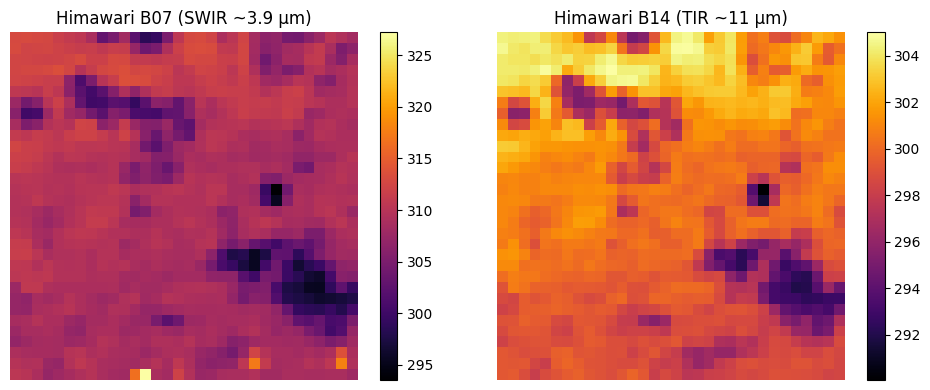

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Assume these already exist from your working code:
# patch_b07, patch_b14  -> shape (32, 32)
# They came from extract_patch_from_da_himawari()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(p07, cmap="inferno")
axs[0].set_title("Himawari B07 (SWIR ~3.9 µm)")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(p14, cmap="inferno")
axs[1].set_title("Himawari B14 (TIR ~11 µm)")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


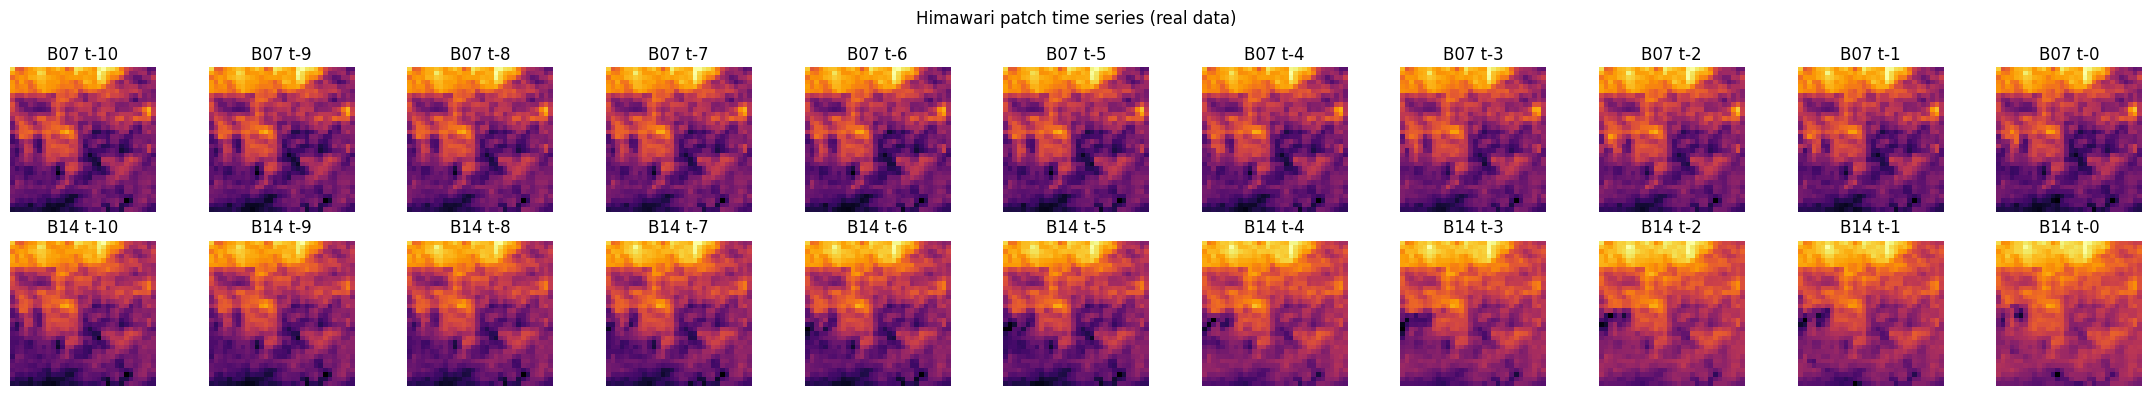

In [77]:
# X has shape (T, 32, 32, 2)
# Example: X from build_event_tensor_multiband()

T = X.shape[0]

fig, axs = plt.subplots(2, T, figsize=(2*T, 4))

for t in range(T):
    axs[0, t].imshow(X[t, :, :, 0], cmap="inferno")
    axs[0, t].set_title(f"B07 t-{T-1-t}")
    axs[0, t].axis("off")

    axs[1, t].imshow(X[t, :, :, 1], cmap="inferno")
    axs[1, t].set_title(f"B14 t-{T-1-t}")
    axs[1, t].axis("off")

plt.suptitle("Himawari patch time series (real data)")
plt.tight_layout()
plt.show()


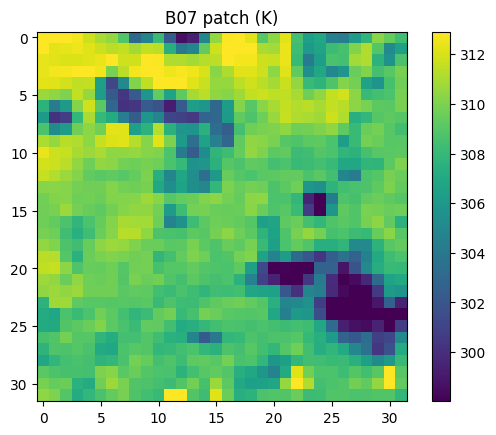

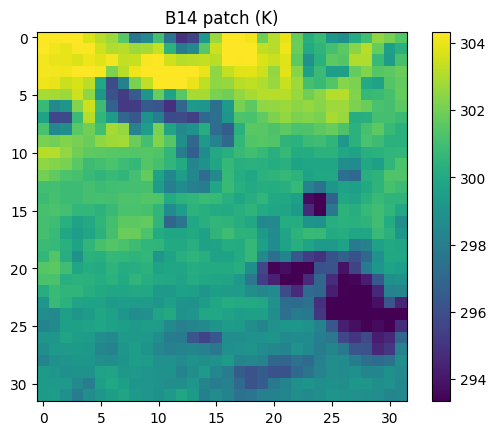

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_patch(p, title):
    vmin, vmax = np.nanpercentile(p, [2, 98])
    plt.figure()
    plt.imshow(p, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.colorbar()
    plt.show()

show_patch(p07, "B07 patch (K)")
show_patch(p14, "B14 patch (K)")


In [ ]:
import inspect
print(inspect.signature(extract_patch_from_da_himawari))


(da, lat, lon, patch=32, prefer_valid=True)


In [ ]:
import os, re, bz2, shutil
import numpy as np
from datetime import timedelta

# ---------- helpers ----------
def build_prefix(dt):
    # Himawari folders are 10-min buckets like .../HHMM/
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def pick_all_segment_keys(keys, band="B07", res="R20"):
    pat = re.compile(rf"_{band}_FLDK_{res}_S(\d{{4}})\.DAT\.bz2$")
    segs = [k for k in keys if pat.search(k)]
    segs.sort()
    return segs

def download_and_decompress(bucket, key, out_dir="/content/himawari_pilot_raw"):
    os.makedirs(out_dir, exist_ok=True)
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    s3.download_file(bucket, key, bz2_path)
    dat_path = bz2_path[:-4]  # remove .bz2
    with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    return dat_path

def load_band_for_time_all_segments(dt, bucket, band="B07", res="R20", tmp_dir="/content/himawari_pilot_raw"):
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    seg_keys = pick_all_segment_keys(keys, band=band, res=res)

    print(f"{band} {res} segments found:", len(seg_keys))
    if not seg_keys:
        return None

    dat_paths = [download_and_decompress(bucket, k, out_dir=tmp_dir) for k in seg_keys]

    from satpy import Scene
    scn = Scene(filenames=dat_paths, reader="ahi_hsd")
    scn.load([band])
    return scn[band]

# ---------- main: build tensor ----------
def build_event_tensor_multiband(
    t0, lat, lon,
    bands=("B07", "B14"),
    res="R20",
    patch=32,
    T=12,
    prefer_valid=True,
    tmp_dir="/content/himawari_pilot_raw",
):
    """
    Returns:
      X: (T_kept, patch, patch, C)
      kept_times: list[datetime]
      info: dict with patch center indices etc.
    """
    t0r = round_down_10min(t0)
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]  # oldest->newest

    X_list = []
    kept_times = []
    last_info = None

    for dt in times:
        bucket = bucket_for_dt(dt)

        per_band_patches = []
        ok = True

        for band in bands:
            da = load_band_for_time_all_segments(dt, bucket, band=band, res=res, tmp_dir=tmp_dir)
            if da is None:
                ok = False
                break

            # IMPORTANT: only args supported by your function signature
            patch_arr, info = extract_patch_from_da_himawari(
                da, lat, lon, patch=patch, prefer_valid=prefer_valid
            )
            per_band_patches.append(patch_arr.astype(np.float32))
            last_info = info

        if not ok:
            print("Missing:", dt, "(skip)")
            continue

        # stack channels last: (patch, patch, C)
        frame = np.stack(per_band_patches, axis=-1)
        X_list.append(frame)
        kept_times.append(dt)

    if not X_list:
        raise RuntimeError("No timesteps loaded. Increase search window or confirm keys exist.")

    X = np.stack(X_list, axis=0)  # (T', patch, patch, C)
    return X, kept_times, last_info

# ---------- run on your current event ----------
# Assumes you already have: t0_example, centroid_lat, centroid_lon
X, kept_times, info = build_event_tensor_multiband(
    t0=t0_example,
    lat=centroid_lat,
    lon=centroid_lon,
    bands=("B07", "B14"),
    res="R20",
    patch=32,
    T=12,
    prefer_valid=True
)

print("X:", X.shape, X.dtype)
print("Times:", kept_times[0], "->", kept_times[-1])
print("Patch idx:", info)
print("NaN fraction %:", float(np.isnan(X).mean()) * 100)


B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 R20 segments found: 10


...

B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


X: (11, 32, 32, 2) float32
Times: 2024-03-24 02:10:00 -> 2024-03-24 04:00:00
Patch idx: {'row': 4607, 'col': 2867, 'y0': 4591, 'y1': 4623, 'x0': 2851, 'x1': 2883, 'proj_x_m': 233963.42209186938, 'proj_y_m': -3714028.8938403497, 'used_search_radius_px': 0}
NaN fraction %: 0.0


In [ ]:
import os, json
import numpy as np
import pandas as pd
from datetime import timedelta

# ====== CONFIG ======
PILOT_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/pilot_events_himawari.csv"
OUT_DIR  = "/content/pilot_h9"

# choose bands (multi-band strong for fire vs cloud/haze)
BANDS = ["B07", "B14"]     # you can expand later: ["B07","B14","B11","B13",...]
RES   = "R20"
PATCH = 32
T     = 12                # desired timesteps (10-min spacing)
PREFER_VALID = True       # uses your "prefer_valid" logic inside extract_patch...
TMP_DIR = "/content/himawari_pilot_raw"   # where .DAT/.bz2 downloads go

os.makedirs(OUT_DIR, exist_ok=True)

# ====== STEP 3: build tensors for all pilot events and save ======
pilot = pd.read_csv(PILOT_CSV, parse_dates=["t0", "start_time", "end_time"])

def build_event_tensor_multiband(
    t0, lat, lon,
    bands=BANDS, res=RES, patch=PATCH, T=T,
    prefer_valid=PREFER_VALID
):
    """
    Returns:
      X: (T_kept, patch, patch, C)
      kept_times: list[datetime]
      info: patch extraction info dict from the LAST extracted band/time (useful for debugging)
    """
    t0r = round_down_10min(pd.Timestamp(t0).to_pydatetime())
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]  # oldest->newest

    X_list = []
    kept_times = []
    last_info = None

    for dt in times:
        # load each band at this dt, extract patch, then stack channels
        band_patches = []
        ok = True

        for band in bands:
            bucket = bucket_for_dt(dt)
            da = load_band_for_time_all_segments(dt, bucket, band=band, res=res)
            if da is None:
                ok = False
                break

            # IMPORTANT: your function signature is (da, lat, lon, patch=32, prefer_valid=True)
            patch_arr, info = extract_patch_from_da_himawari(
                da, lat, lon, patch=patch, prefer_valid=prefer_valid
            )
            last_info = info
            band_patches.append(patch_arr.astype(np.float32))

        if not ok:
            print(f"[missing] {dt} (one or more bands missing) -> skip timestep")
            continue

        # shape: (patch, patch, C)
        frame = np.stack(band_patches, axis=-1)
        X_list.append(frame)
        kept_times.append(dt)

    if not X_list:
        raise RuntimeError("No timesteps loaded for this event (all missing).")

    X = np.stack(X_list, axis=0)  # (T_kept, patch, patch, C)
    return X, kept_times, last_info


def save_event_tensor(event_row, X, kept_times, info, out_dir=OUT_DIR):
    event_id = int(event_row["event_id"])
    event_dir = os.path.join(out_dir, f"event_{event_id}")
    os.makedirs(event_dir, exist_ok=True)

    np.save(os.path.join(event_dir, "X.npy"), X)

    meta = {
        "event_id": event_id,
        "split": str(event_row.get("split", "")),
        "t0": pd.Timestamp(event_row["t0"]).isoformat(),
        "start_time": pd.Timestamp(event_row["start_time"]).isoformat() if not pd.isna(event_row.get("start_time")) else None,
        "end_time": pd.Timestamp(event_row["end_time"]).isoformat() if not pd.isna(event_row.get("end_time")) else None,
        "centroid_lat": float(event_row["centroid_lat"]),
        "centroid_lon": float(event_row["centroid_lon"]),
        "num_detections": int(event_row["num_detections"]) if not pd.isna(event_row.get("num_detections")) else None,
        "duration_hours": float(event_row["duration_hours"]) if not pd.isna(event_row.get("duration_hours")) else None,
        "bands": list(BANDS),
        "res": RES,
        "patch": PATCH,
        "T_requested": T,
        "T_kept": int(X.shape[0]),
        "times_kept": [pd.Timestamp(t).isoformat() for t in kept_times],
        "patch_info": info,
        "dtype": str(X.dtype),
        "shape": list(X.shape),
    }

    with open(os.path.join(event_dir, "meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return event_dir


# ====== RUN ALL EVENTS ======
results = []
for i, row in pilot.iterrows():
    event_id = row["event_id"]
    print(f"\n=== Event {event_id} ({row.get('split','')}) ===")
    try:
        X, kept_times, info = build_event_tensor_multiband(
            t0=row["t0"],
            lat=float(row["centroid_lat"]),
            lon=float(row["centroid_lon"]),
            bands=BANDS, res=RES, patch=PATCH, T=T,
            prefer_valid=PREFER_VALID
        )

        nan_frac = float(np.isnan(X).mean()) * 100.0
        out_path = save_event_tensor(row, X, kept_times, info)

        print(f"Saved: {out_path}")
        print(f"X: {X.shape} {X.dtype} | NaN%: {nan_frac:.3f}")
        print(f"Times: {kept_times[0]} -> {kept_times[-1]}")

        results.append((int(event_id), "ok", X.shape[0], nan_frac, out_path))

    except Exception as e:
        print(f"[FAIL] Event {event_id}: {repr(e)}")
        results.append((int(event_id), "fail", 0, 100.0, None))

print("\n===== SUMMARY =====")
ok = [r for r in results if r[1] == "ok"]
fail = [r for r in results if r[1] == "fail"]
print(f"OK: {len(ok)} | FAIL: {len(fail)}")
print("Per-event:", results)




=== Event 2327 (test) ===
B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 R20 segments found: 10


...

B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


Saved: /content/pilot_h9/event_1286
X: (11, 32, 32, 2) float32 | NaN%: 0.000
Times: 2023-05-09 13:40:00 -> 2023-05-09 15:30:00

===== SUMMARY =====
OK: 10 | FAIL: 0
Per-event: [(2327, 'ok', 11, 0.0, '/content/pilot_h9/event_2327'), (2834, 'ok', 11, 0.0, '/content/pilot_h9/event_2834'), (2655, 'ok', 11, 0.0, '/content/pilot_h9/event_2655'), (2564, 'ok', 11, 0.0, '/content/pilot_h9/event_2564'), (2361, 'ok', 11, 0.0, '/content/pilot_h9/event_2361'), (2645, 'ok', 12, 0.0, '/content/pilot_h9/event_2645'), (1169, 'ok', 11, 0.0, '/content/pilot_h9/event_1169'), (2524, 'ok', 12, 0.0, '/content/pilot_h9/event_2524'), (1775, 'ok', 11, 0.0, '/content/pilot_h9/event_1775'), (1286, 'ok', 11, 0.0, '/content/pilot_h9/event_1286')]


In [ ]:
import os, numpy as np

BASE = "/content/pilot_h9"
for d in sorted(os.listdir(BASE)):
    x = np.load(os.path.join(BASE, d, "X.npy"))
    print(d, x.shape, x.dtype)

event_1169 (11, 32, 32, 2) float32
event_1286 (11, 32, 32, 2) float32
event_1775 (11, 32, 32, 2) float32
event_2327 (11, 32, 32, 2) float32
event_2361 (11, 32, 32, 2) float32
event_2524 (12, 32, 32, 2) float32
event_2564 (11, 32, 32, 2) float32
event_2645 (12, 32, 32, 2) float32
event_2655 (11, 32, 32, 2) float32
event_2834 (11, 32, 32, 2) float32


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class HimawariFireDataset(Dataset):
    def __init__(self, base_dir, target_T=12):
        self.base_dir = base_dir
        self.target_T = target_T
        self.events = sorted(os.listdir(base_dir))

    def __len__(self):
        return len(self.events)

    def _pad_or_clip(self, X):
        T, H, W, C = X.shape

        if T == self.target_T:
            return X

        if T > self.target_T:
            # clip oldest frames
            return X[-self.target_T:]

        # pad (repeat first frame)
        pad = np.repeat(X[:1], self.target_T - T, axis=0)
        return np.concatenate([pad, X], axis=0)

    def __getitem__(self, idx):
        event = self.events[idx]
        path = os.path.join(self.base_dir, event, "X.npy")

        X = np.load(path)                      # (T, 32, 32, 2)
        X = self._pad_or_clip(X)               # (12, 32, 32, 2)

        X = torch.from_numpy(X).permute(0, 3, 1, 2)  # (T, C, H, W)
        return X.float(), event


In [ ]:
ds = HimawariFireDataset("/content/pilot_h9", target_T=12)

for i in range(len(ds)):
    X, eid = ds[i]
    print(eid, X.shape)


event_1169 torch.Size([12, 2, 32, 32])
event_1286 torch.Size([12, 2, 32, 32])
event_1775 torch.Size([12, 2, 32, 32])
event_2327 torch.Size([12, 2, 32, 32])
event_2361 torch.Size([12, 2, 32, 32])
event_2524 torch.Size([12, 2, 32, 32])
event_2564 torch.Size([12, 2, 32, 32])
event_2645 torch.Size([12, 2, 32, 32])
event_2655 torch.Size([12, 2, 32, 32])
event_2834 torch.Size([12, 2, 32, 32])


In [ ]:
import os, json, glob
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

BASE = "/content/pilot_h9"
event_dirs = sorted([d for d in glob.glob(os.path.join(BASE, "event_*")) if os.path.isdir(d)])
assert event_dirs, f"No event_* folders found in {BASE}"

rows = []
for ed in event_dirs:
    x_path = os.path.join(ed, "X.npy")
    m_path = os.path.join(ed, "meta.json")
    X = np.load(x_path)  # [T,32,32,2]
    meta = json.load(open(m_path))

    # flatten across time+space for simple summary stats
    # channels: 0=B07, 1=B14 (based on your pipeline)
    b07 = X[..., 0].reshape(-1)
    b14 = X[..., 1].reshape(-1)
    diff = (X[...,0] - X[...,1]).reshape(-1)

    feats = {
        "event_id": int(meta["event_id"]) if str(meta["event_id"]).isdigit() else meta["event_id"],
        "T": X.shape[0],

        "b07_mean": float(np.mean(b07)),
        "b07_std":  float(np.std(b07)),
        "b07_min":  float(np.min(b07)),
        "b07_max":  float(np.max(b07)),

        "b14_mean": float(np.mean(b14)),
        "b14_std":  float(np.std(b14)),
        "b14_min":  float(np.min(b14)),
        "b14_max":  float(np.max(b14)),

        # simple “fire vs background” signal
        "diff_mean": float(np.mean(diff)),
        "diff_max":  float(np.max(diff)),
    }

    # TOY label just to validate the pipeline (replace later!)
    split = str(meta.get("split", "unknown"))
    feats["y"] = 1 if split == "test" else 0
    feats["split"] = split

    rows.append(feats)

df = pd.DataFrame(rows).sort_values("event_id")
print(df[["event_id","split","T","b07_mean","b14_mean","diff_mean","diff_max","y"]])

feature_cols = [c for c in df.columns if c not in ("event_id","y","split")]
Xtab = df[feature_cols].values
y = df["y"].values

# LOOCV for tiny sample
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

loo = LeaveOneOut()
y_pred = cross_val_predict(pipe, Xtab, y, cv=loo)

print("\nAccuracy:", accuracy_score(y, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y, y_pred))
print("\nReport:\n", classification_report(y, y_pred, digits=3))

df_out = df[["event_id","split","y"]].copy()
df_out["y_pred"] = y_pred
print("\nPredictions per event:")
print(df_out.to_string(index=False))


   event_id  split   T    b07_mean    b14_mean  diff_mean   diff_max  y
0      1169  train  11  294.198639  279.371552  14.827084  27.833832  0
1      1286    val  11  275.692871  276.227264  -0.534398   2.340210  0
2      1775    val  11  313.736847  294.135315  19.601568  39.297394  0
3      2327   test  11  300.230743  293.138123   7.092592  31.617462  1
4      2361  train  11  274.257721  274.080475   0.177244  18.458862  0
5      2524    val  12  306.832550  299.920654   6.911870  24.446106  0
6      2564  train  11  298.595490  292.417847   6.177673  30.653656  0
7      2645  train  12  312.632416  304.528595   8.103806  53.356110  0
8      2655   test  11  316.217407  306.316620   9.900794  49.847900  1
9      2834   test  11  301.224579  296.567780   4.656775  11.141235  1

Accuracy: 0.4

Confusion matrix:
 [[4 3]
 [3 0]]

Report:
               precision    recall  f1-score   support

           0      0.571     0.571     0.571         7
           1      0.000     0.000     0

In [ ]:
import os, textwrap

cds_text = """
url: https://cds.climate.copernicus.eu/api/v2
key: 29d33b86-04dc-448a-83a0-23981c93785c
"""

os.makedirs("/root", exist_ok=True)
with open("/root/.cdsapirc", "w") as f:
    f.write(textwrap.dedent(cds_text).strip() + "\n")

print("CDS API key saved to /root/.cdsapirc")


CDS API key saved to /root/.cdsapirc


In [ ]:
!pip -q install "cdsapi>=0.7.7"

import os, textwrap

# 1) Paste your PERSONAL ACCESS TOKEN here (token only; no "<UID>:")
CDS_TOKEN = "29d33b86-04dc-448a-83a0-23981c93785c"

# 2) Write ~/.cdsapirc with the correct endpoint
rc_path = os.path.expanduser("~/.cdsapirc")
with open(rc_path, "w") as f:
    f.write(textwrap.dedent(f"""\
    url: https://cds.climate.copernicus.eu/api
    key: {CDS_TOKEN}
    """))

print("Wrote", rc_path)
print(open(rc_path).read())



Wrote /root/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: 29d33b86-04dc-448a-83a0-23981c93785c



In [ ]:
import cdsapi
c = cdsapi.Client()
print("CDS client ready")

CDS client ready


In [ ]:
ERA5_VARS = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "10m_u_wind",
    "10m_v_wind",
    "surface_pressure",
    "total_precipitation"
]


In [ ]:
# ===== Phase 4A-2 (FIXED): Download ERA5 for Victoria bbox, hourly =====

import cdsapi
import os

ERA5_VARS = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "surface_pressure",
    "total_precipitation",
]

OUT = "/content/era5_vic_2024.nc"

c = cdsapi.Client()

c.retrieve(
    "reanalysis-era5-single-levels",
    {
        "product_type": "reanalysis",
        "variable": ERA5_VARS,
        "year": "2024",
        "month": ["03"],
        "day": [f"{d:02d}" for d in range(20, 31)],
        "time": [f"{h:02d}:00" for h in range(24)],
        # North, West, South, East
        "area": [-33.5, 140.5, -39.5, 150.0],
        "data_format": "netcdf",
    },
    OUT
)

print("Saved:", OUT, "size(MB):", round(os.path.getsize(OUT)/1e6, 2))


2026-01-23 08:35:38,016 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

5477f39cf876a189f42449a79cddabb.zip:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

Saved: /content/era5_vic_2024.nc size(MB): 2.6


In [ ]:
import os, subprocess, textwrap

ERA5_FILE = "/content/era5_vic_2024.nc"
print("Exists:", os.path.exists(ERA5_FILE), "Size(MB):", os.path.getsize(ERA5_FILE)/1e6)

print("\nfile type:")
print(subprocess.check_output(["bash","-lc", f"file -b {ERA5_FILE}"]).decode())

print("\nfirst 64 bytes (hex):")
print(subprocess.check_output(["bash","-lc", f"xxd -l 64 {ERA5_FILE}"]).decode())


Exists: True Size(MB): 2.598087

file type:
Zip archive data, at least v2.0 to extract, compression method=deflate


first 64 bytes (hex):
00000000: 504b 0304 1400 0000 0800 a244 375c 8192  PK.........D7\..
00000010: bebe a0be 2500 24bd 2500 2400 0000 6461  ....%.$.%.$...da
00000020: 7461 5f73 7472 6561 6d2d 6f70 6572 5f73  ta_stream-oper_s
00000030: 7465 7054 7970 652d 696e 7374 616e 742e  tepType-instant.



In [ ]:
!unzip -o /content/era5_vic_2024.nc -d /content/era5_vic


Archive:  /content/era5_vic_2024.nc
  inflating: /content/era5_vic/data_stream-oper_stepType-instant.nc  
  inflating: /content/era5_vic/data_stream-oper_stepType-accum.nc  


In [ ]:
!ls -lh /content/era5_vic


total 2.5M
-rw-r--r-- 1 root root 122K Jan 23 08:37 data_stream-oper_stepType-accum.nc
-rw-r--r-- 1 root root 2.4M Jan 23 08:37 data_stream-oper_stepType-instant.nc


In [ ]:
import xarray as xr

ERA5_INST = "/content/era5_vic/data_stream-oper_stepType-instant.nc"
ERA5_ACC  = "/content/era5_vic/data_stream-oper_stepType-accum.nc"

ds_i = xr.open_dataset(ERA5_INST)
ds_a = xr.open_dataset(ERA5_ACC)

print("Instant vars:", list(ds_i.data_vars))
print("Accum vars:", list(ds_a.data_vars))


Instant vars: ['t2m', 'd2m', 'u10', 'v10', 'sp']
Accum vars: ['tp']


In [ ]:
import os, json

HIM_BASE = "/content/pilot_h9"

event_dirs = sorted([d for d in os.listdir(HIM_BASE) if d.startswith("event_")])
event_dir = os.path.join(HIM_BASE, event_dirs[0])

meta_path = os.path.join(event_dir, "meta.json")
meta = json.load(open(meta_path))

print("Sample event:", event_dirs[0])
print("Meta keys:", sorted(meta.keys()))
print("Meta preview:", {k: meta[k] for k in sorted(meta.keys()) if k in ["times","kept_times","t0","to","start_time","end_time"]})


Sample event: event_1169
Meta keys: ['T_kept', 'T_requested', 'bands', 'centroid_lat', 'centroid_lon', 'dtype', 'duration_hours', 'end_time', 'event_id', 'num_detections', 'patch', 'patch_info', 'res', 'shape', 'split', 'start_time', 't0', 'times_kept']
Meta preview: {'end_time': '2021-05-31T03:41:00', 'start_time': '2021-05-29T04:19:00', 't0': '2021-05-29T04:19:00'}


In [ ]:
import os, json
import numpy as np
import pandas as pd
import xarray as xr

# ----------------------------
# CONFIG
# ----------------------------
HIM_BASE = "/content/pilot_h9"
ERA5_INST = "/content/era5_vic/data_stream-oper_stepType-instant.nc"
ERA5_ACC  = "/content/era5_vic/data_stream-oper_stepType-accum.nc"
ERA5_OUT_NAME = "E.npy"
ERA5_FEATURES = ["t2m", "d2m", "u10", "v10", "sp", "tp"]

# ----------------------------
# LOAD ERA5
# ----------------------------
ds_i = xr.open_dataset(ERA5_INST)
ds_a = xr.open_dataset(ERA5_ACC)

def _coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords:
            return c
    return None

time_i = _coord_name(ds_i, ["time", "valid_time"])
time_a = _coord_name(ds_a, ["time", "valid_time"])
lat_name = _coord_name(ds_i, ["latitude", "lat"])
lon_name = _coord_name(ds_i, ["longitude", "lon"])

if time_i is None or time_a is None or lat_name is None or lon_name is None:
    raise RuntimeError(f"Could not detect coords. time_i={time_i} time_a={time_a} lat={lat_name} lon={lon_name}")

def to_era5_lon(lon):
    lon = float(lon)
    if float(ds_i[lon_name].max()) > 180:
        return lon % 360
    return lon

def snap_to_hour(ts):
    return pd.Timestamp(ts).round("1H")

def extract_era5_features(ts, lat, lon):
    lat = float(lat)
    lon = to_era5_lon(lon)
    ts_h = snap_to_hour(ts)

    sel_i = ds_i.sel({time_i: ts_h, lat_name: lat, lon_name: lon}, method="nearest")
    sel_a = ds_a.sel({time_a: ts_h, lat_name: lat, lon_name: lon}, method="nearest")

    vec = np.array([
        float(sel_i["t2m"].values),
        float(sel_i["d2m"].values),
        float(sel_i["u10"].values),
        float(sel_i["v10"].values),
        float(sel_i["sp"].values),
        float(sel_a["tp"].values),
    ], dtype=np.float32)

    return vec, ts_h

def get_times_from_meta(meta):
    # your file uses this:
    if "times_kept" in meta:
        return meta["times_kept"], "times_kept"

    # keep compatibility with other variants
    if "times" in meta:
        return meta["times"], "times"
    if "kept_times" in meta:
        return meta["kept_times"], "kept_times"

    raise KeyError(f"No time list found. Keys are: {sorted(meta.keys())}")


# ----------------------------
# BUILD ERA5 TENSOR PER EVENT
# ----------------------------
results = []
event_dirs = sorted([d for d in os.listdir(HIM_BASE) if d.startswith("event_") and os.path.isdir(os.path.join(HIM_BASE, d))])

for d in event_dirs:
    event_dir = os.path.join(HIM_BASE, d)
    meta_path = os.path.join(event_dir, "meta.json")
    if not os.path.exists(meta_path):
        results.append((d, "fail", "missing meta.json"))
        continue

    meta = json.load(open(meta_path))
    try:
        times, times_key = get_times_from_meta(meta)
    except Exception as e:
        results.append((d, "fail", str(e)))
        continue

    lat = meta.get("centroid_lat", None)
    lon = meta.get("centroid_lon", None)
    if lat is None or lon is None:
        results.append((d, "fail", "missing centroid_lat/centroid_lon"))
        continue

    E_list = []
    snapped = []
    for t in times:
        vec, ts_h = extract_era5_features(t, lat, lon)
        E_list.append(vec)
        snapped.append(str(ts_h))

    E = np.stack(E_list, axis=0)  # (T, 6)
    out_path = os.path.join(event_dir, ERA5_OUT_NAME)
    np.save(out_path, E)

    # update meta
    meta["era5_features"] = ERA5_FEATURES
    meta["era5_snapped_times"] = snapped
    meta["era5_source_times_field"] = times_key
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    results.append((d, "ok", E.shape, out_path))

print("===== ERA5 ALIGNMENT SUMMARY =====")
ok = [r for r in results if r[1] == "ok"]
fail = [r for r in results if r[1] != "ok"]
print("OK:", len(ok), "| FAIL:", len(fail))
print("Examples:", ok[:3])
if fail:
    print("Failures:", fail[:10])


/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


===== ERA5 ALIGNMENT SUMMARY =====
OK: 10 | FAIL: 0
Examples: [('event_1169', 'ok', (11, 6), '/content/pilot_h9/event_1169/E.npy'), ('event_1286', 'ok', (11, 6), '/content/pilot_h9/event_1286/E.npy'), ('event_1775', 'ok', (11, 6), '/content/pilot_h9/event_1775/E.npy')]


/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")
/tmp/ipython-input-2639342762.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Timestamp(ts).round("1H")


In [ ]:
import os, json
import numpy as np
import pandas as pd
import xarray as xr

BASE = "/content/pilot_h9"  # your event folders live here
ERA5_INST = "/content/era5_vic/data_stream-oper_stepType-instant.nc"
ERA5_ACC  = "/content/era5_vic/data_stream-oper_stepType-accum.nc"

# pick one event to inspect
sample_event = "event_1169"
meta_path = os.path.join(BASE, sample_event, "meta.json")
X_path    = os.path.join(BASE, sample_event, "X.npy")
E_path    = os.path.join(BASE, sample_event, "E.npy")

meta = json.load(open(meta_path))
print("Meta keys:", list(meta.keys()))
print("X exists?", os.path.exists(X_path), "E exists?", os.path.exists(E_path))

X = np.load(X_path)
E = np.load(E_path)
times = meta["times_kept"]  # <-- correct key in YOUR meta.json

print("X:", X.shape, X.dtype)
print("E:", E.shape, E.dtype)
print("T kept:", len(times), "| first:", times[0], "| last:", times[-1])


Meta keys: ['event_id', 'split', 't0', 'start_time', 'end_time', 'centroid_lat', 'centroid_lon', 'num_detections', 'duration_hours', 'bands', 'res', 'patch', 'T_requested', 'T_kept', 'times_kept', 'patch_info', 'dtype', 'shape', 'era5_features', 'era5_snapped_times', 'era5_source_times_field']
X exists? True E exists? True
X: (11, 32, 32, 2) float32
E: (11, 6) float32
T kept: 11 | first: 2021-05-29T02:20:00 | last: 2021-05-29T04:10:00


In [ ]:
import pandas as pd
import numpy as np
import xarray as xr

ERA5_INST = "/content/era5_vic/data_stream-oper_stepType-instant.nc"
ERA5_ACC  = "/content/era5_vic/data_stream-oper_stepType-accum.nc"

ds_i = xr.open_dataset(ERA5_INST)
ds_a = xr.open_dataset(ERA5_ACC)

def round_to_hour(ts):
    return pd.Timestamp(ts).round("1h")

lat = float(meta["centroid_lat"])
lon = float(meta["centroid_lon"])

# pick 3 indices: first, middle, last
idxs = [0, len(times)//2, len(times)-1]

print("Event lat/lon:", lat, lon)
print("Instant dims:", ds_i.dims)
print("Accum dims  :", ds_a.dims)

for idx in idxs:
    t_sat = pd.Timestamp(times[idx])
    t_era = round_to_hour(t_sat)

    # NOTE: use valid_time (not time)
    row_i = ds_i.sel(latitude=lat, longitude=lon, valid_time=t_era, method="nearest")
    row_a = ds_a.sel(latitude=lat, longitude=lon, valid_time=t_era, method="nearest")

    vals = [
        float(row_i["t2m"].values),
        float(row_i["d2m"].values),
        float(row_i["u10"].values),
        float(row_i["v10"].values),
        float(row_i["sp"].values),
        float(row_a["tp"].values),
    ]

    print(f"\nidx={idx}")
    print("sat_time :", t_sat)
    print("era_time :", t_era)
    print("E_saved  :", E[idx])
    print("E_recalc :", np.array(vals, dtype=np.float32))
    print("abs diff max:", float(np.abs(E[idx] - np.array(vals, dtype=np.float32)).max()))


Event lat/lon: -37.80216333333333 144.75270999999998
Instant dims: FrozenMappingWarningOnValuesAccess({'valid_time': 264, 'latitude': 25, 'longitude': 39})
Accum dims  : FrozenMappingWarningOnValuesAccess({'valid_time': 264, 'latitude': 25, 'longitude': 39})

idx=0
sat_time : 2021-05-29 02:20:00
era_time : 2021-05-29 02:00:00
E_saved  : [2.8860474e+02 2.7771191e+02 5.6625671e+00 4.7752838e+00 1.0100706e+05
 0.0000000e+00]
E_recalc : [2.8860474e+02 2.7771191e+02 5.6625671e+00 4.7752838e+00 1.0100706e+05
 0.0000000e+00]
abs diff max: 0.0

idx=5
sat_time : 2021-05-29 03:20:00
era_time : 2021-05-29 03:00:00
E_saved  : [2.8860474e+02 2.7771191e+02 5.6625671e+00 4.7752838e+00 1.0100706e+05
 0.0000000e+00]
E_recalc : [2.8860474e+02 2.7771191e+02 5.6625671e+00 4.7752838e+00 1.0100706e+05
 0.0000000e+00]
abs diff max: 0.0

idx=10
sat_time : 2021-05-29 04:10:00
era_time : 2021-05-29 04:00:00
E_saved  : [2.8860474e+02 2.7771191e+02 5.6625671e+00 4.7752838e+00 1.0100706e+05
 0.0000000e+00]
E_recal

In [ ]:
def iter_events(base):
    for d in sorted(os.listdir(base)):
        if d.startswith("event_") and os.path.isdir(os.path.join(base, d)):
            yield d, os.path.join(base, d)

rows = []
for ev, ev_dir in iter_events(BASE):
    meta = json.load(open(os.path.join(ev_dir, "meta.json")))
    split = meta["split"]
    E = np.load(os.path.join(ev_dir, "E.npy"))  # (T,F)
    if split == "train":
        rows.append(E)

E_train = np.concatenate(rows, axis=0)  # (N,F)
feat_mean = np.mean(E_train, axis=0)
feat_std  = np.std(E_train, axis=0)
feat_std = np.where(feat_std == 0, 1.0, feat_std)

print("Train E shape:", E_train.shape)
print("mean:", feat_mean)
print("std :", feat_std)

# save stats
norm = {
    "feature_order": ["t2m","d2m","u10","v10","sp","tp"],
    "mean": feat_mean.tolist(),
    "std": feat_std.tolist(),
    "computed_from": "train_only"
}

NORM_PATH = os.path.join(BASE, "_era5_norm.json")
with open(NORM_PATH, "w") as f:
    json.dump(norm, f, indent=2)

print("Saved norm:", NORM_PATH)


Train E shape: (45, 6)
mean: [2.8794992e+02 2.7774408e+02 4.0532575e+00 5.7641940e+00 1.0069995e+05
 3.4968059e-07]
std : [7.2893780e-01 5.6278235e-01 9.8612940e-01 9.1893071e-01 1.4292209e+03
 6.1477300e-07]
Saved norm: /content/pilot_h9/_era5_norm.json


In [ ]:
import json

norm = json.load(open(os.path.join(BASE, "_era5_norm.json")))
mean = np.array(norm["mean"], dtype=np.float32)
std  = np.array(norm["std"], dtype=np.float32)

ok, fail = 0, 0
examples = []

for ev, ev_dir in iter_events(BASE):
    try:
        E = np.load(os.path.join(ev_dir, "E.npy")).astype(np.float32)
        En = (E - mean) / std
        out_path = os.path.join(ev_dir, "E_norm.npy")
        np.save(out_path, En)

        ok += 1
        if len(examples) < 3:
            examples.append((ev, En.shape, out_path))
    except Exception as e:
        fail += 1
        print("FAIL:", ev, e)

print("\n===== 4C NORMALIZATION SUMMARY =====")
print("OK:", ok, "| FAIL:", fail)
print("Examples:", examples)



===== 4C NORMALIZATION SUMMARY =====
OK: 10 | FAIL: 0
Examples: [('event_1169', (11, 6), '/content/pilot_h9/event_1169/E_norm.npy'), ('event_1286', (11, 6), '/content/pilot_h9/event_1286/E_norm.npy'), ('event_1775', (11, 6), '/content/pilot_h9/event_1775/E_norm.npy')]


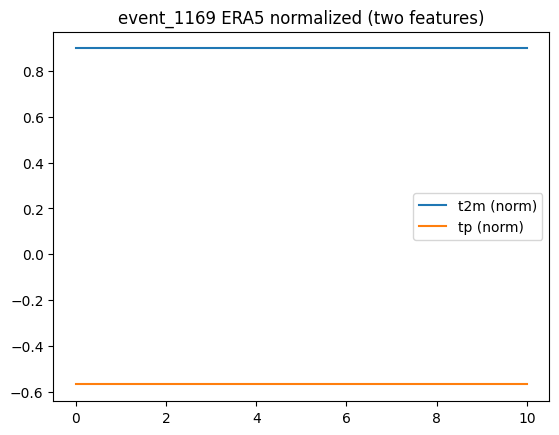

En mean (approx): [ 0.89831483 -0.05715447  1.6319458  -1.076153    0.21487889 -0.5687962 ]
En std  (approx): [5.9604645e-08 3.7252903e-09 1.1920929e-07 1.1920929e-07 1.4901161e-08
 5.9604645e-08]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ev = sample_event
En = np.load(os.path.join(BASE, ev, "E_norm.npy"))

plt.figure()
plt.plot(En[:, 0], label="t2m (norm)")
plt.plot(En[:, 5], label="tp (norm)")
plt.legend()
plt.title(f"{ev} ERA5 normalized (two features)")
plt.show()

print("En mean (approx):", En.mean(axis=0))
print("En std  (approx):", En.std(axis=0))


In [ ]:
import pandas as pd

CSV = "/content/drive/MyDrive/vic_bushfire_dataset/pilot_events_himawari.csv"

df = pd.read_csv(CSV)

# Define label
df["y"] = (df["duration_hours"] >= 24).astype(int)

print(df[["event_id", "duration_hours", "y"]])

# Save back
df.to_csv(CSV, index=False)
print("Saved with label column y")


   event_id  duration_hours  y
0      2327       35.050000  1
1      2834      143.783333  1
2      2655       49.050000  1
3      2564       10.500000  0
4      2361        0.000000  0
5      2645        0.000000  0
6      1169       47.366667  1
7      2524        0.000000  0
8      1775       72.733333  1
9      1286       47.366667  1
Saved with label column y


In [ ]:
# =========================
# Phase 5 — Fusion modeling
# Minimal + clean (works with tiny pilot set)
# =========================

import os, json, glob
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

BASE = "/content/pilot_h9"   # <-- your folder with event_*/X.npy, E.npy, meta.json

# -------------------------
# 5A) Load event folders + labels
# -------------------------
event_dirs = sorted([d for d in glob.glob(os.path.join(BASE, "event_*")) if os.path.isdir(d)])
print("Found events:", len(event_dirs))

rows = []
for d in event_dirs:
    meta_path = os.path.join(d, "meta.json")
    meta = json.load(open(meta_path))
    rows.append({
        "event_dir": d,
        "event_id": meta.get("event_id", os.path.basename(d).replace("event_", "")),
        "split": meta.get("split", "unknown"),
        "t0": meta.get("t0", None),
    })

df = pd.DataFrame(rows)

# ---- label source ----
# Option A (recommended): a CSV with labels
# Put your labels in a file and set the path here:
LABEL_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/pilot_events_himawari.csv"  # change if needed

if os.path.exists(LABEL_CSV):
    lab = pd.read_csv(LABEL_CSV)
    # Try common label column names:
    label_col = None
    for c in ["y", "label", "target", "is_fire"]:
        if c in lab.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(
            f"No label column found in {LABEL_CSV}. "
            f"Columns are: {list(lab.columns)}. "
            f"Add a column like 'y' (0/1) and re-run."
        )

    # Merge by event_id (string-safe)
    lab["event_id"] = lab["event_id"].astype(str)
    df["event_id"] = df["event_id"].astype(str)
    df = df.merge(lab[["event_id", label_col]], on="event_id", how="left")
    df = df.rename(columns={label_col: "y"})
else:
    raise FileNotFoundError(
        f"Label CSV not found at {LABEL_CSV}. "
        "Create/put it there with columns: event_id, y (0/1)."
    )

print(df[["event_id", "split", "y"]])

# -------------------------
# 5B) Feature builders (fixed length)
# -------------------------
def sat_features_from_X(X):
    """
    X: [T, H, W, C] float32
    Returns fixed vector.
    """
    X = np.asarray(X)
    # Handle variable T by computing stats over (T,H,W)
    # Per-band stats
    feats = []
    for c in range(X.shape[-1]):
        xc = X[..., c].reshape(-1)
        feats += [
            float(np.nanmean(xc)),
            float(np.nanstd(xc)),
            float(np.nanmin(xc)),
            float(np.nanmax(xc)),
        ]

    # Add band-difference stats if C>=2 (e.g., B07-B14)
    if X.shape[-1] >= 2:
        diff = (X[..., 0] - X[..., 1]).reshape(-1)
        feats += [
            float(np.nanmean(diff)),
            float(np.nanstd(diff)),
            float(np.nanmin(diff)),
            float(np.nanmax(diff)),
        ]
    return np.array(feats, dtype=np.float32)

def era5_features_from_E(E):
    """
    E: [T, F] float32
    Returns fixed vector.
    """
    E = np.asarray(E)
    feats = []
    for f in range(E.shape[-1]):
        ef = E[:, f]
        feats += [
            float(np.nanmean(ef)),
            float(np.nanstd(ef)),
            float(np.nanmin(ef)),
            float(np.nanmax(ef)),
        ]
    return np.array(feats, dtype=np.float32)

def load_XE(d):
    X = np.load(os.path.join(d, "X.npy"))
    E_path = os.path.join(d, "E.npy")
    E = np.load(E_path) if os.path.exists(E_path) else None
    return X, E

# Build matrices
Xs, Xf, y, split = [], [], [], []
for _, r in df.iterrows():
    if pd.isna(r["y"]):
        raise ValueError(f"Missing label y for event_id={r['event_id']}. Fix your label CSV.")

    X, E = load_XE(r["event_dir"])
    sat_f = sat_features_from_X(X)
    Xs.append(sat_f)

    if E is not None:
        era_f = era5_features_from_E(E)
        fusion_f = np.concatenate([sat_f, era_f], axis=0)
    else:
        fusion_f = sat_f
    Xf.append(fusion_f)

    y.append(int(r["y"]))
    split.append(r["split"])

Xs = np.vstack(Xs)
Xf = np.vstack(Xf)
y = np.array(y, dtype=int)
split = np.array(split)

print("Sat feature dim:", Xs.shape, "Fusion feature dim:", Xf.shape)

# Train/val/test masks
m_train = (split == "train")
m_val   = (split == "val")
m_test  = (split == "test")

def evaluate(name, model, X_train, y_train, X_test, y_test, ids):
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, yp))
    print("Confusion matrix:\n", confusion_matrix(y_test, yp))
    print("Report:\n", classification_report(y_test, yp, digits=3))
    out = pd.DataFrame({"event_id": ids, "y": y_test, "y_pred": yp})
    print(out.to_string(index=False))
    return model

# -------------------------
# 5C) Satellite-only baseline (proper)
# -------------------------
sat_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Use train+val for training (tiny data), evaluate on test
m_tr = (m_train | m_val)
evaluate(
    "SAT-only (fixed-stat features + LogisticRegression)",
    sat_model,
    Xs[m_tr], y[m_tr],
    Xs[m_test], y[m_test],
    df.loc[m_test, "event_id"].values
)

# -------------------------
# 5D) Fusion model (Sat + ERA5)
# -------------------------
fusion_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

evaluate(
    "FUSION (Sat+ERA5 fixed-stat features + LogisticRegression)",
    fusion_model,
    Xf[m_tr], y[m_tr],
    Xf[m_test], y[m_test],
    df.loc[m_test, "event_id"].values
)


Found events: 10
  event_id  split  y
0     1169  train  1
1     1286    val  1
2     1775    val  1
3     2327   test  1
4     2361  train  0
5     2524    val  0
6     2564  train  0
7     2645  train  0
8     2655   test  1
9     2834   test  1
Sat feature dim: (10, 12) Fusion feature dim: (10, 36)

=== SAT-only (fixed-stat features + LogisticRegression) ===
Accuracy: 0.3333333333333333
Confusion matrix:
 [[0 0]
 [2 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

Report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      1.000     0.333     0.500         3

    accuracy                          0.333         3
   macro avg      0.500     0.167     0.250         3
weighted avg      1.000     0.333     0.500         3

event_id  y  y_pred
    2327  1       1
    2655  1       0
    2834  1       0

=== FUSION (Sat+ERA5 fixed-stat features + LogisticRegression) ===
Accuracy: 1.0
Confusion matrix:
 [[3]]
Report:
               precision    recall  f1-score   support

           1      1.000     1.000     1.000         3

    accuracy                          1.000         3
   macro avg      1.000     1.000     1.000         3
weighted avg      1.000     1.000     1.000         3

event_id  y  y_pred
    2327  1       1
    2655  1       1
    2834  1       1


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
import numpy as np

def temporal_stats(ts):
    """
    ts: (T,) time series
    """
    T = len(ts)
    t = np.arange(T)

    # basic
    mean = ts.mean()
    std = ts.std()
    mn = ts.min()
    mx = ts.max()

    # early vs late
    k = max(1, int(0.3 * T))
    early = ts[:k].mean()
    late = ts[-k:].mean()
    delta = late - early

    # slope
    slope = np.polyfit(t, ts, 1)[0] if T > 1 else 0.0

    return [mean, std, mn, mx, delta, slope]


In [ ]:
def sat_temporal_features(X):
    # X: (T, H, W, C)
    feats = []
    for c in range(X.shape[-1]):
        ts = X[..., c].mean(axis=(1,2))  # spatial mean → (T,)
        feats.extend(temporal_stats(ts))
    return np.array(feats)


In [ ]:
def era5_temporal_features(E):
    # E: (T, F)
    feats = []
    for f in range(E.shape[1]):
        feats.extend(temporal_stats(E[:, f]))
    return np.array(feats)


In [ ]:
X_sat = sat_temporal_features(X)
X_era = era5_temporal_features(E)

X_fusion = np.concatenate([X_sat, X_era])


In [ ]:
import os, json
import numpy as np
import pandas as pd

BASE = "/content/pilot_h9"   # where event_#### folders are
OUT_DIR = "/content/pilot_h9_phase52"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 0) quick sanity check on ONE event ----
sample_event = sorted([d for d in os.listdir(BASE) if d.startswith("event_")])[0]
x_path = os.path.join(BASE, sample_event, "X.npy")
e_path = os.path.join(BASE, sample_event, "E.npy")
m_path = os.path.join(BASE, sample_event, "meta.json")

X = np.load(x_path)   # (T,H,W,C)
E = np.load(e_path)   # (T,F)
meta = json.load(open(m_path))

X_sat = sat_temporal_features(X)
X_era = era5_temporal_features(E)
X_fusion = np.concatenate([X_sat, X_era])

print("Sample:", sample_event)
print("X:", X.shape, X.dtype, "| NaN%:", float(np.isnan(X).mean())*100)
print("E:", E.shape, E.dtype, "| NaN%:", float(np.isnan(E).mean())*100)
print("SAT feat dim:", X_sat.shape, "| NaN%:", float(np.isnan(X_sat).mean())*100)
print("ERA feat dim:", X_era.shape, "| NaN%:", float(np.isnan(X_era).mean())*100)
print("FUSION dim:", X_fusion.shape, "| NaN%:", float(np.isnan(X_fusion).mean())*100)

# ---- 1) build matrices for ALL events ----
rows = []
Xsat_list, Xera_list, Xfus_list, y_list, event_ids, splits = [], [], [], [], [], []

# labels: use your pilot csv in Drive (adjust path if needed)
LABEL_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/pilot_events_himawari.csv"
lab = pd.read_csv(LABEL_CSV)
# must contain: event_id, split, y
lab["event_id"] = lab["event_id"].astype(int)
y_map = dict(zip(lab["event_id"], lab["y"]))
split_map = dict(zip(lab["event_id"], lab["split"]))

for d in sorted([d for d in os.listdir(BASE) if d.startswith("event_")]):
    eid = int(d.split("_")[1])

    X = np.load(os.path.join(BASE, d, "X.npy"))
    E = np.load(os.path.join(BASE, d, "E.npy"))

    fs = sat_temporal_features(X)
    fe = era5_temporal_features(E)
    ff = np.concatenate([fs, fe])

    # checks
    if np.isnan(ff).any():
        raise RuntimeError(f"{d}: NaNs found in fusion features")

    Xsat_list.append(fs)
    Xera_list.append(fe)
    Xfus_list.append(ff)
    y_list.append(int(y_map[eid]))
    event_ids.append(eid)
    splits.append(split_map[eid])

    rows.append({
        "event_id": eid,
        "split": split_map[eid],
        "y": int(y_map[eid]),
        "T": int(X.shape[0]),
        "sat_dim": int(fs.shape[0]),
        "era_dim": int(fe.shape[0]),
        "fusion_dim": int(ff.shape[0]),
    })

X_sat_mat = np.stack(Xsat_list, axis=0)
X_era_mat = np.stack(Xera_list, axis=0)
X_fus_mat = np.stack(Xfus_list, axis=0)
y = np.array(y_list, dtype=np.int64)

print("\n=== PHASE 5.2 SUMMARY ===")
print("Events:", len(event_ids))
print("X_sat:", X_sat_mat.shape, "NaN%:", float(np.isnan(X_sat_mat).mean())*100)
print("X_era:", X_era_mat.shape, "NaN%:", float(np.isnan(X_era_mat).mean())*100)
print("X_fus:", X_fus_mat.shape, "NaN%:", float(np.isnan(X_fus_mat).mean())*100)
print("y:", y.shape, "pos:", int(y.sum()), "neg:", int((y==0).sum()))

# ---- 2) save outputs ----
np.save(os.path.join(OUT_DIR, "X_sat.npy"), X_sat_mat)
np.save(os.path.join(OUT_DIR, "X_era.npy"), X_era_mat)
np.save(os.path.join(OUT_DIR, "X_fusion.npy"), X_fus_mat)
np.save(os.path.join(OUT_DIR, "y.npy"), y)

meta_df = pd.DataFrame(rows).sort_values("event_id")
meta_df.to_csv(os.path.join(OUT_DIR, "index.csv"), index=False)

print("\nSaved to:", OUT_DIR)
print("Files:", os.listdir(OUT_DIR))


Sample: event_1169
X: (11, 32, 32, 2) float32 | NaN%: 0.0
E: (11, 6) float32 | NaN%: 0.0
SAT feat dim: (12,) | NaN%: 0.0
ERA feat dim: (36,) | NaN%: 0.0
FUSION dim: (48,) | NaN%: 0.0

=== PHASE 5.2 SUMMARY ===
Events: 10
X_sat: (10, 12) NaN%: 0.0
X_era: (10, 36) NaN%: 0.0
X_fus: (10, 48) NaN%: 0.0
y: (10,) pos: 6 neg: 4

Saved to: /content/pilot_h9_phase52
Files: ['X_sat.npy', 'y.npy', 'index.csv', 'X_era.npy', 'X_fusion.npy']


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

OUT_DIR = "/content/pilot_h9_phase52"
idx = pd.read_csv(os.path.join(OUT_DIR, "index.csv"))

X_sat = np.load(os.path.join(OUT_DIR, "X_sat.npy"))
X_era = np.load(os.path.join(OUT_DIR, "X_era.npy"))
X_fus = np.load(os.path.join(OUT_DIR, "X_fusion.npy"))
y = np.load(os.path.join(OUT_DIR, "y.npy"))

def eval_split(name, X, split_name):
    mask_tr = (idx["split"].values == "train")
    mask_sp = (idx["split"].values == split_name)

    Xtr, ytr = X[mask_tr], y[mask_tr]
    Xsp, ysp = X[mask_sp], y[mask_sp]

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=0))
    ])
    clf.fit(Xtr, ytr)

    ypred = clf.predict(Xsp)

    print(f"\n=== {name} | eval on {split_name} ===")
    print("n:", len(ysp), "| pos:", int(ysp.sum()), "| neg:", int((ysp==0).sum()))
    print("Accuracy:", accuracy_score(ysp, ypred))
    print("Confusion:\n", confusion_matrix(ysp, ypred, labels=[0,1]))
    print(classification_report(ysp, ypred, labels=[0,1], zero_division=0))

# Evaluate on VAL and TEST
for split_name in ["val", "test"]:
    eval_split("SAT only", X_sat, split_name)
    eval_split("ERA5 only", X_era, split_name)
    eval_split("FUSION", X_fus, split_name)



=== SAT only | eval on val ===
n: 3 | pos: 2 | neg: 1
Accuracy: 0.6666666666666666
Confusion:
 [[1 0]
 [1 1]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


=== ERA5 only | eval on val ===
n: 3 | pos: 2 | neg: 1
Accuracy: 0.6666666666666666
Confusion:
 [[1 0]
 [1 1]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


=== FUSION | eval on val ===
n: 3 | pos: 2 | neg: 1
Accuracy: 0.6666666666666666
Confusion:
 [[1 0]
 [1 1]]
              

In [ ]:
# ===== PHASE 6A: CONFIG =====
import os
import pandas as pd

# 1) Where your full event index CSV is (adjust if needed)
# This should be your leakage-free event-level split index.
FULL_INDEX_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
# If instead you have an events table with split/y already, point to that file.

# 2) Where to write the full scaled dataset
OUT_BASE = "/content/vic_full_h9"          # per-event folders: event_<id>/
OUT_PHASE52 = "/content/vic_full_phase52"  # final matrices

os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(OUT_PHASE52, exist_ok=True)

# 3) Read index
df = pd.read_csv(FULL_INDEX_CSV, parse_dates=["t0"], infer_datetime_format=True)

print("Loaded:", df.shape)
print("Columns:", list(df.columns))

# 4) Minimal required columns
need = ["event_id", "t0", "centroid_lat", "centroid_lon", "split"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# 5) Label column (y) expected for modeling
if "y" not in df.columns:
    print("WARNING: no 'y' column found. Phase 6 can still build tensors, but Phase 5/6 modeling needs labels.")
else:
    print("Label balance:", df["y"].value_counts(dropna=False).to_dict())

# 6) Quick split counts
print("Split counts:", df["split"].value_counts().to_dict())

df.head()


/tmp/ipython-input-775184493.py:18: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(FULL_INDEX_CSV, parse_dates=["t0"], infer_datetime_format=True)


Loaded: (36729, 16)
Columns: ['sample_id', 'event_id', 'label', 'window_end_offset_min', 'window_start', 'window_end', 't0', 'centroid_lat', 'centroid_lon', 'source_pos_id', 'neg_type', 'month', 'year', 'season_year', 'season', 'split']
Split counts: {'train': 28098, 'val': 6336, 'test': 2295}


,sample_id,event_id,label,window_end_offset_min,window_start,window_end,t0,centroid_lat,centroid_lon,source_pos_id,neg_type,month,year,season_year,season,split
0,neg_match_pos_e2325_m60,2325,0,60,2023-09-05 01:49:00,2023-09-05 02:49:00,2023-10-01 03:49:00,-37.751463,147.111523,pos_e2325_m60,matched_day_same_loc,9,2023,2023,2022-23,test
1,neg_match_pos_e2397_m30,2397,0,30,2023-09-05 02:19:00,2023-09-05 03:19:00,2023-10-01 03:49:00,-37.976153,146.421140,pos_e2397_m30,matched_day_same_loc,9,2023,2023,2022-23,test
2,neg_match_pos_e1448_m30,1448,0,30,2023-09-11 03:09:00,2023-09-11 04:09:00,2023-10-09 04:39:00,-37.626187,141.291737,pos_e1448_m30,matched_day_same_loc,9,2023,2023,2022-23,test
3,neg_match_pos_e1304_m30,1304,0,30,2023-09-11 12:43:00,2023-09-11 13:43:00,2023-10-04 14:13:00,-37.831930,144.786520,pos_e1304_m30,matched_day_same_loc,9,2023,2023,2022-23,test
4,neg_match_pos_e358_m30,358,0,30,2023-09-12 03:09:00,2023-09-12 04:09:00,2023-10-09 04:39:00,-36.880557,141.868287,pos_e358_m30,matched_day_same_loc,9,2023,2023,2022-23,test


In [65]:
# ===== PHASE 6B: SCALABLE RUNNER (resume + logging) =====
import json
import numpy as np
from tqdm import tqdm

# ---- IMPORTANT: You must already have these from your earlier phases ----
# build_event_tensor_multiband(t0, lat, lon, bands, res, patch, T, prefer_valid) -> (X, kept_times, info)
# plus your ERA5 datasets ds_i and ds_a already opened (instant + accum files)
# and your round_to_hour / ERA5 sel logic already validated in Phase 4B/4C.

# ---- CONFIG: same as pilot ----
BANDS = ["B07", "B14"]
RES = "R20"
PATCH = 32
T = 12               # requested frames (10-min cadence)
PREFER_VALID = True  # same behavior as pilot

# ---- ERA5 vars order (must match what you built in 4B) ----
ERA5_VARS_INSTANT = ["t2m", "d2m", "u10", "v10", "sp"]  # from ds_i
ERA5_VARS_ACCUM   = ["tp"]                             # from ds_a

def ensure_event_dir(eid: int):
    d = os.path.join(OUT_BASE, f"event_{eid}")
    os.makedirs(d, exist_ok=True)
    return d

def done_event(eid: int):
    d = os.path.join(OUT_BASE, f"event_{eid}")
    return os.path.exists(os.path.join(d, "X.npy")) and os.path.exists(os.path.join(d, "E.npy")) and os.path.exists(os.path.join(d, "meta.json"))

# ---- You already have these two datasets loaded from 4A ----
# ds_i = xr.open_dataset(ERA5_INST)
# ds_a = xr.open_dataset(ERA5_ACC)

import pandas as pd

def round_to_hour(ts):
    # Use 'h' to avoid the FutureWarning
    return pd.Timestamp(ts).round("1h")

def extract_era5_row(lat, lon, t_sat, ds_i, ds_a):
    """Returns vector [t2m, d2m, u10, v10, sp, tp] at nearest ERA5 gridpoint and nearest hour."""
    t_era = round_to_hour(t_sat)

    # ERA5 time coord may be valid_time (as you saw)
    time_dim_i = "valid_time" if "valid_time" in ds_i.dims else "time"
    time_dim_a = "valid_time" if "valid_time" in ds_a.dims else "time"

    row_i = ds_i.sel(latitude=lat, longitude=lon, **{time_dim_i: t_era}, method="nearest")
    row_a = ds_a.sel(latitude=lat, longitude=lon, **{time_dim_a: t_era}, method="nearest")

    vec = []
    for v in ERA5_VARS_INSTANT:
        vec.append(float(row_i[v].values))
    for v in ERA5_VARS_ACCUM:
        vec.append(float(row_a[v].values))

    return np.array(vec, dtype=np.float32)

def build_E_for_times(times_kept, lat, lon, ds_i, ds_a):
    """Build E: (T_kept, 6)."""
    E = np.stack([extract_era5_row(lat, lon, t, ds_i, ds_a) for t in times_kept], axis=0).astype(np.float32)
    return E

# ---- MAIN LOOP ----
results = []
fails = []

for _, r in tqdm(df.iterrows(), total=len(df)):
    eid = int(r["event_id"])
    lat = float(r["centroid_lat"])
    lon = float(r["centroid_lon"])
    t0 = pd.Timestamp(r["t0"]).to_pydatetime()

    out_dir = ensure_event_dir(eid)

    if done_event(eid):
        results.append((eid, "skip", out_dir))
        continue

    try:
        # 1) Himawari tensors
        X, kept_times, info = build_event_tensor_multiband(
            t0=t0,
            lat=lat,
            lon=lon,
            bands=BANDS,
            res=RES,
            patch=PATCH,
            T=T,
            prefer_valid=PREFER_VALID,
        )

        # Convert times to Python datetimes
        kept_times = [pd.Timestamp(t).to_pydatetime() for t in kept_times]

        # 2) ERA5 alignment to kept_times
        E = build_E_for_times(kept_times, lat, lon, ds_i, ds_a)

        # 3) Save
        np.save(os.path.join(out_dir, "X.npy"), X.astype(np.float32))
        np.save(os.path.join(out_dir, "E.npy"), E.astype(np.float32))

        meta = {
            "event_id": eid,
            "split": str(r["split"]),
            "t0": pd.Timestamp(r["t0"]).isoformat(),
            "centroid_lat": lat,
            "centroid_lon": lon,
            "bands": BANDS,
            "res": RES,
            "patch": PATCH,
            "T_requested": int(T),
            "T_kept": int(len(kept_times)),
            "times_kept": [pd.Timestamp(t).isoformat() for t in kept_times],
            "dtype": "float32",
            "shape_X": list(X.shape),
            "shape_E": list(E.shape),
            "patch_info": info,
        }
        if "y" in df.columns:
            meta["y"] = int(r["y"])

        with open(os.path.join(out_dir, "meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        results.append((eid, "ok", out_dir))

    except Exception as e:
        fails.append((eid, "fail", str(e)))
        # write a small fail marker so you can inspect later
        with open(os.path.join(out_dir, "FAIL.txt"), "w") as f:
            f.write(str(e))

print("\n===== PHASE 6B SUMMARY =====")
print("OK:", sum(1 for x in results if x[1] == "ok"))
print("SKIP:", sum(1 for x in results if x[1] == "skip"))
print("FAIL:", len(fails))
if fails:
    print("First 5 fails:", fails[:5])


  0%|          | 0/36729 [00:00<?, ?it/s]

B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


...

B14 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


B07 R20 segments found: 10


/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
  0%|          | 6/36729 [31:08<3177:14:33, 311.47s/it]


KeyboardInterrupt: 

In [67]:
import os, glob

OUT_BASE = "/content/vic_full_h9"

event_dirs = sorted([d for d in glob.glob(os.path.join(OUT_BASE, "event_*")) if os.path.isdir(d)])

def is_done(ev_dir):
    return (os.path.exists(os.path.join(ev_dir, "X.npy")) and
            os.path.exists(os.path.join(ev_dir, "E.npy")) and
            os.path.exists(os.path.join(ev_dir, "meta.json")))

done = [d for d in event_dirs if is_done(d)]
fail = [d for d in event_dirs if os.path.exists(os.path.join(d, "FAIL.txt"))]
partial = [d for d in event_dirs if (d not in done and d not in fail)]

print("Total event folders:", len(event_dirs))
print("DONE:", len(done))
print("FAIL:", len(fail))
print("PARTIAL:", len(partial))
print("Example DONE:", done[:3])
print("Example FAIL:", fail[:3])


Total event folders: 6
DONE: 5
FAIL: 0
PARTIAL: 1
Example DONE: ['/content/vic_full_h9/event_1304', '/content/vic_full_h9/event_1448', '/content/vic_full_h9/event_2325']
Example FAIL: []


In [68]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv")

# Overall balance
print("Overall label counts:")
print(df["label"].value_counts())

# By split (train / val / test)
print("\nBy split:")
print(df.groupby("split")["label"].value_counts())


Overall label counts:
label
0    24486
1    12243
Name: count, dtype: int64

By split:
split  label
test   0         1530
       1          765
train  0        18732
       1         9366
val    0         4224
       1         2112
Name: count, dtype: int64


In [70]:
import pandas as pd

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"  # adjust
df = pd.read_csv(SAMPLES)

print("Unique events:", df["event_id"].nunique())

# If label column exists (common names)
for col in ["label", "y", "target", "fire", "is_fire"]:
    if col in df.columns:
        print("\nLabel column:", col)
        print("Overall:\n", df[col].value_counts())
        if "split" in df.columns:
            print("\nBy split:\n", df.groupby("split")[col].value_counts())
        break
else:
    print("\nNo obvious label column found. Columns are:\n", df.columns.tolist())


Unique events: 4081

Label column: label
Overall:
 label
0    24486
1    12243
Name: count, dtype: int64

By split:
 split  label
test   0         1530
       1          765
train  0        18732
       1         9366
val    0         4224
       1         2112
Name: count, dtype: int64


In [71]:
import pandas as pd

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
df = pd.read_csv(SAMPLES)

# Event-level label: positive if ANY row in the event is positive
ev = (df.groupby(["event_id", "split"])["label"]
        .max()
        .reset_index()
        .rename(columns={"label": "event_label"}))

print("Unique events:", ev["event_id"].nunique())
print("\nEvent-level overall:\n", ev["event_label"].value_counts())

print("\nEvent-level by split:\n", ev.groupby("split")["event_label"].value_counts())


Unique events: 4081

Event-level overall:
 event_label
1    4081
Name: count, dtype: int64

Event-level by split:
 split  event_label
test   1               255
train  1              3122
val    1               704
Name: count, dtype: int64


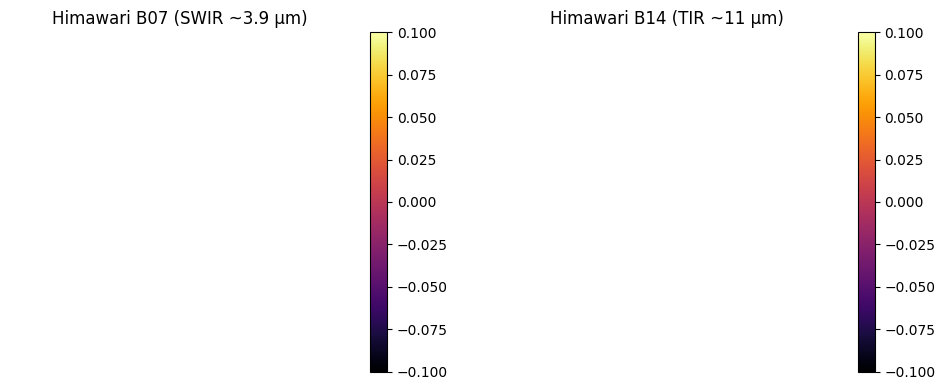

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Assume these already exist from your working code:
# patch_b07, patch_b14  -> shape (32, 32)
# They came from extract_patch_from_da_himawari()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(patch_b07, cmap="inferno")
axs[0].set_title("Himawari B07 (SWIR ~3.9 µm)")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(patch_b14, cmap="inferno")
axs[1].set_title("Himawari B14 (TIR ~11 µm)")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [79]:
import pandas as pd

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
df = pd.read_csv(SAMPLES)

print(df.columns.tolist())


['sample_id', 'event_id', 'label', 'window_end_offset_min', 'window_start', 'window_end', 't0', 'centroid_lat', 'centroid_lon', 'source_pos_id', 'neg_type', 'month', 'year', 'season_year', 'season', 'split']


In [80]:
import pandas as pd
import numpy as np

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
df = pd.read_csv(SAMPLES)

# Parse times
for c in ["window_start", "window_end", "t0"]:
    df[c] = pd.to_datetime(df[c])

print("Rows:", len(df), "| Unique events:", df["event_id"].nunique())
df.head()


Rows: 36729 | Unique events: 4081


,sample_id,event_id,label,window_end_offset_min,window_start,window_end,t0,centroid_lat,centroid_lon,source_pos_id,neg_type,month,year,season_year,season,split
0,neg_match_pos_e2325_m60,2325,0,60,2023-09-05 01:49:00,2023-09-05 02:49:00,2023-10-01 03:49:00,-37.751463,147.111523,pos_e2325_m60,matched_day_same_loc,9,2023,2023,2022-23,test
1,neg_match_pos_e2397_m30,2397,0,30,2023-09-05 02:19:00,2023-09-05 03:19:00,2023-10-01 03:49:00,-37.976153,146.421140,pos_e2397_m30,matched_day_same_loc,9,2023,2023,2022-23,test
2,neg_match_pos_e1448_m30,1448,0,30,2023-09-11 03:09:00,2023-09-11 04:09:00,2023-10-09 04:39:00,-37.626187,141.291737,pos_e1448_m30,matched_day_same_loc,9,2023,2023,2022-23,test
3,neg_match_pos_e1304_m30,1304,0,30,2023-09-11 12:43:00,2023-09-11 13:43:00,2023-10-04 14:13:00,-37.831930,144.786520,pos_e1304_m30,matched_day_same_loc,9,2023,2023,2022-23,test
4,neg_match_pos_e358_m30,358,0,30,2023-09-12 03:09:00,2023-09-12 04:09:00,2023-10-09 04:39:00,-36.880557,141.868287,pos_e358_m30,matched_day_same_loc,9,2023,2023,2022-23,test


In [81]:
HORIZON_HOURS = 6
MIN_POS_WINDOWS = 2
MIN_POS_MINUTES = 60

# Consider windows whose END is within horizon after t0
df["dt_end_from_t0_h"] = (df["window_end"] - df["t0"]).dt.total_seconds() / 3600.0
df_h = df[(df["dt_end_from_t0_h"] >= 0) & (df["dt_end_from_t0_h"] <= HORIZON_HOURS)].copy()

# Window duration in minutes
df_h["win_minutes"] = (df_h["window_end"] - df_h["window_start"]).dt.total_seconds() / 60.0

# Aggregate per event
ev = (df_h.groupby(["event_id", "split"])
      .agg(
          n_windows=("sample_id", "count"),
          n_pos_windows=("label", "sum"),
          pos_minutes=("win_minutes", lambda x: float(np.sum(x[df_h.loc[x.index, "label"]==1]))),
          first_pos_h=("dt_end_from_t0_h", lambda x: float(np.min(x[df_h.loc[x.index, "label"]==1])) if np.any(df_h.loc[x.index, "label"]==1) else np.nan),
          last_pos_h=("dt_end_from_t0_h", lambda x: float(np.max(x[df_h.loc[x.index, "label"]==1])) if np.any(df_h.loc[x.index, "label"]==1) else np.nan),
      )
      .reset_index()
)

# Escalation label
ev["y_escalation"] = (
    (ev["n_pos_windows"] >= MIN_POS_WINDOWS) &
    (ev["pos_minutes"] >= MIN_POS_MINUTES)
).astype(int)

print("=== Event escalation label balance ===")
print(ev["y_escalation"].value_counts())

print("\n=== By split ===")
print(ev.groupby("split")["y_escalation"].value_counts())

ev.head()


=== Event escalation label balance ===
Series([], Name: count, dtype: int64)

=== By split ===
Series([], Name: count, dtype: int64)


,event_id,split,n_windows,n_pos_windows,pos_minutes,first_pos_h,last_pos_h,y_escalation


In [82]:
import pandas as pd
import numpy as np

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
df = pd.read_csv(SAMPLES)

# Parse times
for c in ["window_start", "window_end", "t0"]:
    df[c] = pd.to_datetime(df[c])

# Window duration in minutes
df["win_minutes"] = (df["window_end"] - df["window_start"]).dt.total_seconds() / 60.0

# Aggregate per event
ev = (
    df.groupby(["event_id", "split"])
      .agg(
          n_windows=("sample_id", "count"),
          n_pos_windows=("label", "sum"),
          pos_minutes=("win_minutes", lambda x: float(np.sum(x[df.loc[x.index, "label"]==1]))),
          first_pos_time=("window_start", lambda x: x[df.loc[x.index, "label"]==1].min() if np.any(df.loc[x.index, "label"]==1) else pd.NaT),
          last_pos_time=("window_end", lambda x: x[df.loc[x.index, "label"]==1].max() if np.any(df.loc[x.index, "label"]==1) else pd.NaT),
      )
      .reset_index()
)

# Escalation rule (tunable but safe defaults)
MIN_POS_WINDOWS = 2
MIN_POS_MINUTES = 60

ev["y_escalation"] = (
    (ev["n_pos_windows"] >= MIN_POS_WINDOWS) &
    (ev["pos_minutes"] >= MIN_POS_MINUTES)
).astype(int)

print("=== Event escalation label balance ===")
print(ev["y_escalation"].value_counts())

print("\n=== By split ===")
print(ev.groupby("split")["y_escalation"].value_counts())

ev.head()


=== Event escalation label balance ===
y_escalation
1    4081
Name: count, dtype: int64

=== By split ===
split  y_escalation
test   1                255
train  1               3122
val    1                704
Name: count, dtype: int64


,event_id,split,n_windows,n_pos_windows,pos_minutes,first_pos_time,last_pos_time,y_escalation
0,0,train,9,3,180.0,2018-11-09 02:44:00,2018-11-09 04:34:00,1
1,1,train,9,3,180.0,2018-10-01 01:35:00,2018-10-01 03:25:00,1
2,2,train,9,3,180.0,2018-10-04 12:51:00,2018-10-04 14:41:00,1
3,3,train,9,3,180.0,2018-10-10 02:06:00,2018-10-10 03:56:00,1
4,4,train,9,3,180.0,2018-10-21 02:51:00,2018-10-21 04:41:00,1


In [83]:
import numpy as np
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv",
    parse_dates=["window_start", "window_end"]
)

# Window duration
df["win_minutes"] = (
    df["window_end"] - df["window_start"]
).dt.total_seconds() / 60

def escalation_label(group):
    group = group.sort_values("window_start")
    T = len(group)
    k = max(1, int(0.4 * T))  # early = first 40%

    early = group.iloc[:k]
    late  = group.iloc[k:]

    early_pos = early["label"].sum()
    late_pos  = late["label"].sum()

    # Escalation if fire activity increases
    return int(late_pos > early_pos)

ev2 = (
    df.groupby(["event_id", "split"])
      .apply(escalation_label)
      .reset_index(name="y_escalation")
)

print("=== Event escalation balance ===")
print(ev2["y_escalation"].value_counts())

print("\n=== By split ===")
print(ev2.groupby("split")["y_escalation"].value_counts())


=== Event escalation balance ===
y_escalation
1    4081
Name: count, dtype: int64

=== By split ===
split  y_escalation
test   1                255
train  1               3122
val    1                704
Name: count, dtype: int64


/tmp/ipython-input-3903663637.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(escalation_label)


In [84]:
import pandas as pd
import numpy as np

SAMPLES = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index.csv"
df = pd.read_csv(SAMPLES, parse_dates=["window_start","window_end","t0"])

# Sort within each event by time
df = df.sort_values(["event_id", "window_start"]).reset_index(drop=True)

K = 6  # horizon in windows (6 ~ 60 min if 10-min cadence)

def add_future_label(g):
    y = g["label"].to_numpy()
    n = len(y)
    y_future = np.zeros(n, dtype=int)

    # y_future[i] = 1 if any label==1 in next K windows
    for i in range(n):
        j1 = i + 1
        j2 = min(n, i + 1 + K)
        y_future[i] = int(y[j1:j2].max() == 1) if j1 < j2 else 0

    g = g.copy()
    g["y_future"] = y_future
    return g

df2 = df.groupby("event_id", group_keys=False).apply(add_future_label)

print("=== Window-level y_future balance ===")
print(df2["y_future"].value_counts())

print("\n=== By split ===")
print(df2.groupby("split")["y_future"].value_counts())

# Optional: save for modeling
OUT = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_with_y_future.csv"
df2.to_csv(OUT, index=False)
print("\nSaved:", OUT)


/tmp/ipython-input-192664373.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df.groupby("event_id", group_keys=False).apply(add_future_label)


=== Window-level y_future balance ===
y_future
1    26642
0    10087
Name: count, dtype: int64

=== By split ===
split  y_future
test   1            1780
       0             515
train  1           20269
       0            7829
val    1            4593
       0            1743
Name: count, dtype: int64

Saved: /content/drive/MyDrive/vic_bushfire_dataset/samples_index_with_y_future.csv


In [85]:
import pandas as pd
import numpy as np
import os

# ===== INPUTS =====
IN_CSV  = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_with_y_future.csv"
OUT_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv"

# How many EVENTS you want total in Phase 6A:
N_EVENTS_TOTAL = 1000

# Windows kept per event (small = fast, still informative)
EARLY_K = 2          # first K windows in each event
LATE_K  = 1          # last K windows in each event (optional, keep 1)
KEEP_TRANSITION = True  # last 0 before first 1 + first 1
RANDOM_SEED = 42

df = pd.read_csv(IN_CSV, parse_dates=["window_start", "window_end", "t0"])

required = {"event_id","split","y_future","window_end_offset_min"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}. Found: {list(df.columns)}")

# ---------- 1) choose events stratified by split ----------
events_by_split = (
    df[["event_id","split"]]
    .drop_duplicates()
    .groupby("split")["event_id"]
    .apply(list)
    .to_dict()
)

splits = ["train","val","test"]
avail = {s: len(events_by_split.get(s, [])) for s in splits}
total_avail = sum(avail.values())
if total_avail == 0:
    raise ValueError("No events found. Check the CSV path or contents.")

# Keep split proportions similar to your dataset
target = {}
for s in splits:
    prop = avail[s] / total_avail if total_avail else 0
    target[s] = int(round(prop * N_EVENTS_TOTAL))

# Fix rounding so sums match exactly N_EVENTS_TOTAL
diff = N_EVENTS_TOTAL - sum(target.values())
for s in sorted(splits, key=lambda x: avail[x], reverse=True):
    if diff == 0:
        break
    target[s] += 1 if diff > 0 else -1
    diff += -1 if diff > 0 else 1

rng = np.random.default_rng(RANDOM_SEED)
chosen_events = []
for s in splits:
    evs = events_by_split.get(s, [])
    if not evs:
        continue
    n = min(target[s], len(evs))
    chosen = rng.choice(evs, size=n, replace=False).tolist()
    chosen_events.extend(chosen)

df_ev = df[df["event_id"].isin(chosen_events)].copy()

# ---------- 2) per-event window sampling ----------
def select_windows_for_event(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("window_end_offset_min").copy()
    idx_keep = set()

    # early windows
    idx_keep.update(g.index[:min(EARLY_K, len(g))].tolist())

    # last window(s)
    if LATE_K > 0:
        idx_keep.update(g.index[-min(LATE_K, len(g)):].tolist())

    # transition windows: last 0 before first 1 AND first 1
    if KEEP_TRANSITION:
        y = g["y_future"].to_numpy()
        pos = np.where(y == 1)[0]
        if len(pos) > 0:
            first_pos = int(pos[0])
            idx_keep.add(g.index[first_pos])
            if first_pos > 0:
                # last window immediately before first positive
                idx_keep.add(g.index[first_pos - 1])

    return g.loc[sorted(idx_keep)]

sampled = (
    df_ev.groupby("event_id", group_keys=False)
    .apply(select_windows_for_event)
    .reset_index(drop=True)
)

# ---------- 3) save + quick sanity prints ----------
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
sampled.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("\n=== Phase 6A sampled dataset ===")
print("Unique events:", sampled["event_id"].nunique())
print("Total windows:", len(sampled))
print("\nBy split (events):")
print(sampled[["event_id","split"]].drop_duplicates()["split"].value_counts())
print("\nBy split (windows):")
print(sampled["split"].value_counts())
print("\ny_future balance:")
print(sampled["y_future"].value_counts())
print("\nBy split x y_future:")
print(sampled.groupby(["split","y_future"]).size())
print("\nWindows per event (min/median/max):",
      sampled.groupby("event_id").size().min(),
      int(sampled.groupby("event_id").size().median()),
      sampled.groupby("event_id").size().max())


Saved: /content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv

=== Phase 6A sampled dataset ===
Unique events: 1000
Total windows: 3210

By split (events):
split
train    765
val      173
test      62
Name: count, dtype: int64

By split (windows):
split
train    2458
val       553
test      199
Name: count, dtype: int64

y_future balance:
y_future
1    1756
0    1454
Name: count, dtype: int64

By split x y_future:
split  y_future
test   0             84
       1            115
train  0           1114
       1           1344
val    0            256
       1            297
dtype: int64

Windows per event (min/median/max): 3 3 4


/tmp/ipython-input-357346331.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(select_windows_for_event)


In [86]:
!pip -q install pandas numpy boto3 satpy pyproj xarray cfgrib eccodes

import os, json, math, bz2, shutil, glob
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

import boto3
import xarray as xr
from satpy import Scene


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.3 MB/s eta 0:00:00


In [87]:
# ===== INPUT CSV (Phase 6A sampled) =====
SAMPLES_CSV = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv"

# ===== ERA5 file you downloaded earlier =====
ERA5_FILE = "/content/era5_vic_2024.nc"   # change if yours is elsewhere

# ===== OUTPUT folder =====
OUT_BASE = "/content/vic_phase6B_windows"   # local is faster
# Optional: persist to Drive (slower but survives runtime reset)
# OUT_BASE = "/content/drive/MyDrive/vic_bushfire_dataset/vic_phase6B_windows"

os.makedirs(OUT_BASE, exist_ok=True)

df = pd.read_csv(SAMPLES_CSV, parse_dates=["window_start","window_end","t0"])
print("Windows:", len(df), "| Unique events:", df["event_id"].nunique())
print("Splits:\n", df["split"].value_counts())
print("y_future:\n", df["y_future"].value_counts())
print("OUT_BASE:", OUT_BASE)


Windows: 3210 | Unique events: 1000
Splits:
 split
train    2458
val       553
test      199
Name: count, dtype: int64
y_future:
 y_future
1    1756
0    1454
Name: count, dtype: int64
OUT_BASE: /content/vic_phase6B_windows


In [88]:
s3 = boto3.client("s3")

def round_down_10min(ts):
    ts = pd.Timestamp(ts).to_pydatetime()
    minute = (ts.minute // 10) * 10
    return ts.replace(minute=minute, second=0, microsecond=0)

def build_prefix(dt):
    # Himawari AHI L1b FLDK path convention
    return f"AHI-L1b-FLDK/{dt:%Y/%m/%d/%H%M}/"

def bucket_for_dt(dt):
    # If you already have a bucket switcher, keep it.
    # Many people use a fixed bucket for H9.
    return "noaa-himawari9"

def list_keys(bucket, prefix):
    keys = []
    token = None
    while True:
        kwargs = {"Bucket": bucket, "Prefix": prefix, "MaxKeys": 1000}
        if token:
            kwargs["ContinuationToken"] = token
        resp = s3.list_objects_v2(**kwargs)
        for obj in resp.get("Contents", []):
            keys.append(obj["Key"])
        if resp.get("IsTruncated"):
            token = resp.get("NextContinuationToken")
        else:
            break
    return keys

def pick_segment_keys(keys, band="B07", res="R20"):
    # Return all segment keys for this band/res in this prefix
    # Example name: HS_H09_20240324_0400_B07_FLDK_R20_S0110.DAT.bz2
    out = []
    for k in keys:
        base = os.path.basename(k)
        if f"_{band}_" in base and f"_{res}_" in base and base.endswith(".DAT.bz2"):
            out.append(k)
    return sorted(out)


In [89]:
def download_and_decompress(bucket, key, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    bz2_path = os.path.join(out_dir, os.path.basename(key))
    if not os.path.exists(bz2_path):
        s3.download_file(bucket, key, bz2_path)

    dat_path = bz2_path[:-4]
    if not os.path.exists(dat_path):
        with bz2.open(bz2_path, "rb") as f_in, open(dat_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    return dat_path

def load_band_da(dat_paths, band):
    # SatPy expects list of segment DAT paths
    scn = Scene(filenames=dat_paths, reader="ahi_hsd")
    scn.load([band])
    return scn[band]

def get_segment_dat_paths_for_time(dt, band="B07", res="R20", cache_dir="/content/himawari_cache"):
    dt = round_down_10min(dt)
    bucket = bucket_for_dt(dt)
    prefix = build_prefix(dt)
    keys = list_keys(bucket, prefix)
    seg_keys = pick_segment_keys(keys, band=band, res=res)
    print(f"{band} {res} segments found:", len(seg_keys))
    if len(seg_keys) == 0:
        return None, None, None

    # download+decompress each segment
    seg_dir = os.path.join(cache_dir, f"{dt:%Y%m%d_%H%M}", band)
    dat_paths = []
    for k in seg_keys:
        dat_paths.append(download_and_decompress(bucket, k, seg_dir))
    return bucket, prefix, dat_paths


In [90]:
def build_sample_tensor_multiband(window_end_time, lat, lon,
                                  bands=("B07","B14"),
                                  res="R20",
                                  patch=32,
                                  T=12,
                                  cache_dir="/content/himawari_cache"):
    """
    Build tensor ending at window_end_time (rounded to 10min).
    Returns X (T', patch, patch, C) and times_kept (list).
    """
    t0r = round_down_10min(window_end_time)
    times = [t0r - timedelta(minutes=10*i) for i in range(T-1, -1, -1)]

    X_list = []
    kept = []

    for dt in times:
        band_patches = []
        ok = True

        for b in bands:
            bucket, prefix, dat_paths = get_segment_dat_paths_for_time(dt, band=b, res=res, cache_dir=cache_dir)
            if dat_paths is None:
                ok = False
                break

            da = load_band_da(dat_paths, b)

            # IMPORTANT: you already have this working
            patch_arr, info = extract_patch_from_da_himawari(
                da, lat, lon, patch=patch, prefer_valid=True
            )
            band_patches.append(patch_arr.astype("float32"))

        if ok:
            # stack bands last
            X_list.append(np.stack(band_patches, axis=-1))
            kept.append(dt)

    if len(X_list) == 0:
        raise RuntimeError("No timesteps loaded for this sample.")

    X = np.stack(X_list, axis=0)  # (T', patch, patch, C)
    return X, kept


In [94]:
!pip -q install h5netcdf netCDF4


In [2]:
ERA5_FILE = "/content/era5_vic_2024.nc"


In [4]:
import xarray as xr

ERA5_INST = "/content/era5_vic/data_stream-oper_stepType-instant.nc"
ERA5_ACC  = "/content/era5_vic/data_stream-oper_stepType-accum.nc"

ds_i = xr.open_dataset(ERA5_INST, engine="h5netcdf")
ds_a = xr.open_dataset(ERA5_ACC,  engine="h5netcdf")

print("Instant vars:", list(ds_i.data_vars))
print("Accum vars:", list(ds_a.data_vars))
print("Instant dims:", ds_i.dims)
print("Accum dims:", ds_a.dims)


Instant vars: ['t2m', 'd2m', 'u10', 'v10', 'sp']
Accum vars: ['tp']
Instant dims: FrozenMappingWarningOnValuesAccess({'valid_time': 264, 'latitude': 25, 'longitude': 39})
Accum dims: FrozenMappingWarningOnValuesAccess({'valid_time': 264, 'latitude': 25, 'longitude': 39})


In [5]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv", parse_dates=["window_start","window_end","t0"])
print(df["window_start"].min(), "->", df["window_end"].max())
print(df["year"].value_counts().head(10))


2018-10-01 02:25:00 -> 2024-03-31 14:47:00
year
2019    861
2023    592
2021    576
2020    533
2022    438
2024    110
2018    100
Name: count, dtype: int64


In [6]:
SAMPLED = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv"
ERA5_DIR = "/content/era5_vic_byyear"   # where we will store yearly ERA5 files


In [7]:
import pandas as pd
import os

df = pd.read_csv(SAMPLED, parse_dates=["window_start","window_end","t0"])

need = (
    df.assign(year=df["window_start"].dt.year, month=df["window_start"].dt.month)
      .groupby("year")["month"]
      .apply(lambda s: sorted(set(s.tolist())))
      .to_dict()
)

print("Years -> months needed:")
for y, ms in need.items():
    print(y, ms)

os.makedirs(ERA5_DIR, exist_ok=True)


Years -> months needed:
2018 [10, 11, 12]
2019 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2020 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2021 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2022 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2023 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2024 [1, 2, 3]


In [8]:
ERA5_VARS_INST = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "surface_pressure",
]
ERA5_VARS_ACC = [
    "total_precipitation",
]

# Victoria bbox
VIC_AREA = [-33.5, 140.5, -39.5, 150.0]  # N, W, S, E


In [9]:
import cdsapi

def dl_era5_year(year, months, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    c = cdsapi.Client()

    months = [f"{m:02d}" for m in months]
    times  = [f"{h:02d}:00" for h in range(24)]

    # 1) INSTANT
    out_inst = os.path.join(out_dir, f"era5_{year}_instant.nc")
    if not os.path.exists(out_inst):
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ERA5_VARS_INST,
                "year": str(year),
                "month": months,
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": times,
                "area": VIC_AREA,
                "data_format": "netcdf",
            },
            out_inst,
        )
        print("Saved:", out_inst)
    else:
        print("Exists:", out_inst)

    # 2) ACCUM (tp)
    out_acc = os.path.join(out_dir, f"era5_{year}_accum.nc")
    if not os.path.exists(out_acc):
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ERA5_VARS_ACC,
                "year": str(year),
                "month": months,
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": times,
                "area": VIC_AREA,
                "data_format": "netcdf",
            },
            out_acc,
        )
        print("Saved:", out_acc)
    else:
        print("Exists:", out_acc)

    return out_inst, out_acc


In [15]:
import pandas as pd

SAMPLED = "/content/drive/MyDrive/vic_bushfire_dataset/samples_index_phase6A_sampled.csv"
df = pd.read_csv(SAMPLED, parse_dates=["window_start","window_end"])

# ERA5 is hourly. We'll use all hours between rounded start/end.
ws = df["window_start"].dt.floor("h")
we = df["window_end"].dt.ceil("h")

def round_to_hour(ts):
    return pd.Timestamp(ts).round("h")

need_map = {}

for _, row in df.iterrows():
    for ts in [row["window_start"], row["window_end"]]:
        t = round_to_hour(ts)
        ym = (t.year, t.month)
        if ym not in need_map:
            need_map[ym] = {"days": set(), "hours": set()}
        need_map[ym]["days"].add(t.day)
        need_map[ym]["hours"].add(t.hour)


print("Number of (year, month) chunks:", len(need_map))
print("Example chunk:", list(need_map.items())[:1])


Number of (year, month) chunks: 66
Example chunk: [((2019, 3), {'days': {1, 2, 4, 6, 7, 8, 12, 13, 15, 17, 19, 21, 22, 23, 25, 27, 28, 29, 30, 31}, 'hours': {1, 2, 3, 4, 5, 12, 13, 14, 15, 16}})]


In [16]:
sizes = []
for (y,m), spec in sorted(need_map.items()):
    sizes.append((y,m,len(spec["days"]),len(spec["hours"]),
                  len(spec["days"])*len(spec["hours"])))

pd.DataFrame(
    sizes, columns=["year","month","n_days","n_hours","cells"]
).describe()

,year,month,n_days,n_hours,cells
count,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2021.000000,6.500000,16.924242,8.121212,144.666667
std,1.636131,3.595938,7.164680,1.493732,76.085849
min,2018.000000,1.000000,3.000000,2.000000,6.000000
25%,2020.000000,3.000000,12.000000,7.000000,84.000000
50%,2021.000000,6.500000,15.500000,8.000000,127.000000
75%,2022.000000,10.000000,24.000000,9.000000,205.250000
max,2024.000000,12.000000,30.000000,10.000000,290.000000


In [14]:
import pandas as pd
sdf = pd.DataFrame(sizes, columns=["year","month","n_days","n_hours","day_hour_cells"])
print(sdf.describe())
print("\nTop 10 largest chunks:")
print(sdf.sort_values("day_hour_cells", ascending=False).head(10))


              year      month     n_days    n_hours  day_hour_cells
count    66.000000  66.000000  66.000000  66.000000       66.000000
mean   2021.000000   6.500000  16.924242   9.863636      174.000000
std       1.636131   3.595938   7.164680   1.577597       87.762967
min    2018.000000   1.000000   3.000000   3.000000        9.000000
25%    2020.000000   3.000000  12.000000   9.000000      111.750000
50%    2021.000000   6.500000  15.500000  10.000000      152.000000
75%    2022.000000  10.000000  24.000000  11.000000      249.750000
max    2024.000000  12.000000  30.000000  13.000000      364.000000

Top 10 largest chunks:
    year  month  n_days  n_hours  day_hour_cells
29  2021      3      28       13             364
7   2019      5      29       12             348
6   2019      4      28       12             336
30  2021      4      30       11             330
17  2020      3      29       11             319
54  2023      4      29       11             319
31  2021      5      

NameError: name 'need_map' is not defined

In [69]:
df["event_id"].nunique()

4081

In [ ]:
!find /content -name "pilot_events_himawari.csv"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!find /content/drive -name "pilot_events_himawari.csv"


/content/drive/MyDrive/vic_bushfire_dataset/pilot_events_himawari.csv
